# Lección 15.3 · Acoplamiento molecular (docking)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-15-estructural/15.3_docking_molecular.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 15 — Bioinformática estructural** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 15.1 (coordenadas atómicas, PDB, RMSD y Kabsch) y 15.2 (paisajes de energía en embudo); Python con NumPy |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Formular** el acoplamiento molecular (*docking*) como un problema de **búsqueda** en $6+N_{\mathrm{rot}}$
   dimensiones más una **función de puntuación** $S(\mathbf x)$, y estimar el tamaño de ese espacio.
2. **Encontrar** el bolsillo de unión de una proteína real y **definir** una caja de búsqueda razonable.
3. **Implementar desde cero** la función de puntuación de AutoDock Vina (distancia de superficie, dos gaussianas,
   repulsión, término hidrofóbico, puente de hidrógeno y corrección por enlaces rotables) y **comprobar** que reproduce
   la puntuación de Vina para el imatinib en la quinasa ABL.
4. **Convertir** una puntuación en una constante de disociación $K_d$ y **explicar** por qué esa cifra tiene un error de
   más de un orden de magnitud.
5. **Programar** una búsqueda de Monte Carlo con minimización local y criterio de Metropolis, primero en un paisaje de
   juguete y después en el bolsillo real, y **ejecutar** AutoDock Vina en Colab.
6. **Validar** un protocolo por *redocking* con el RMSD simétrico ($<2$ Å), **distinguir** fallos de búsqueda de fallos
   de puntuación y **medir** el enriquecimiento de un cribado virtual (curva ROC, factor de enriquecimiento).
7. **Razonar** sobre las limitaciones del *docking* con un caso clínico: la mutación de resistencia **T315I**.

## 🗺️ Mapa de la clase

1. Gleevec: la molécula que cambió la leucemia mieloide crónica
2. El problema: pose, grados de libertad y el tamaño del espacio de búsqueda
3. 🧪 Los datos: la quinasa ABL con imatinib (PDB 1IEP) (🔍 interactivo)
4. Encontrar el sitio de unión y dibujar la caja
5. Funciones de puntuación: la función de Vina, término a término
6. De la puntuación a la constante de disociación
7. Búsqueda conformacional: Monte Carlo, minimización local y Metropolis (🔍 interactivo, 🎬 animación)
8. Un *docking* de juguete escrito desde cero (🎬 animación)
9. 🧪 AutoDock Vina en Colab y nuestra propia búsqueda en el bolsillo real
10. El embudo de unión y la validación por *redocking* (🔍 interactivo)
11. 🧪 Resistencia: la mutación T315I
12. Cribado virtual y enriquecimiento (🔍 interactivo)
13. Limitaciones y aprendizaje profundo
14. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, json, time, shutil, tempfile, subprocess, warnings
warnings.filterwarnings("ignore", message="The figure layout has changed")
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
from scipy.spatial import cKDTree
from scipy.optimize import minimize
from scipy.ndimage import map_coordinates
from scipy.spatial.transform import Rotation

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, timeout=60):
    """Lee un archivo del curso: 1) copia local ../data; 2) copia del repositorio en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    with urllib.request.urlopen(f"{RAW}/data/{name}", timeout=timeout) as r:
        return r.read()

def course_text(name):
    data = course_bytes(name)
    return (gzip.decompress(data) if data[:2] == b"\x1f\x8b" else data).decode()

WORK = "/content/leccion153" if IN_COLAB else tempfile.mkdtemp(prefix="leccion153_")
os.makedirs(WORK, exist_ok=True)          # aquí trabajará AutoDock Vina (fuera de la carpeta del curso)

rng = np.random.default_rng(153)          # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 15.3")

Entorno listo ✔  |  Colab: False


Listo para la Lección 15.3


## 1. Gleevec: la molécula que cambió la leucemia mieloide crónica

En 1960, Peter Nowell y David Hungerford vieron al microscopio que las células de los pacientes con **leucemia mieloide
crónica** (LMC) tenían un cromosoma 22 más corto de lo normal: el **cromosoma Filadelfia**, llamado así por la ciudad
donde se descubrió. En 1973, Janet Rowley mostró que ese cromosoma es el resultado de una **translocación** entre los
cromosomas 9 y 22. Años después se entendió qué produce: una proteína de fusión, **BCR-ABL**, en la que el dominio
quinasa de ABL queda **encendido para siempre**. Una quinasa transfiere un grupo fosfato del ATP a otras proteínas;
una quinasa que nunca se apaga manda sin descanso la señal de "divídete", y las células de la médula ósea proliferan
sin control.

Si la enfermedad depende de **una sola** enzima hiperactiva, la estrategia es obvia en palabras y dificilísima en la
práctica: encontrar una molécula pequeña que se meta en el bolsillo donde ABL une el ATP y lo tape, **sin** tapar el
de las otras ~500 quinasas humanas, que se parecen mucho. Esa molécula es el **imatinib** (STI-571, comercializado como
**Gleevec** o Glivec). En el ensayo clínico de fase I publicado en 2001, casi todos los pacientes en fase crónica que
recibieron dosis de 300 mg o más normalizaron sus recuentos sanguíneos (Druker *et al.*, 2001). Hoy, la esperanza de
vida de un paciente con LMC bien controlada se acerca a la de la población general.

¿**Cómo** encaja el imatinib en ABL? La respuesta llegó con la cristalografía: la estructura **1IEP** (Nagar *et al.*,
2002) muestra el imatinib dentro del dominio quinasa de ABL, en una conformación **inactiva** de la enzima (con el
motivo DFG "hacia afuera"), que explica buena parte de su selectividad. Y muy pronto llegó también la mala noticia:
algunos pacientes recaían porque su BCR-ABL había **mutado**. La más temida es **T315I**: una treonina del fondo del
bolsillo (el "portero", *gatekeeper*) cambia por isoleucina, y el imatinib deja de funcionar (Gorre *et al.*, 2001).

Esa es la historia de esta clase. Con la estructura 1IEP vamos a **reproducir computacionalmente** cómo se une el
imatinib, a **entender** qué hace cada pieza de un programa de *docking* y a **ver** por qué T315I es un problema.

### Una llave en la oscuridad

Imagine que debe encontrar, a oscuras, cuál de mil llaves abre una cerradura, y en qué posición entra. Puede palpar
la forma de la cerradura, pero no verla. Para cada llave tiene que hacer dos cosas: **probar** posiciones (girarla,
inclinarla, empujarla, doblar las llaves articuladas) y **juzgar** cada posición (¿encaja sin forzar?, ¿toca los
pernos?). Si prueba pocas posiciones, puede descartar la llave correcta porque nunca la metió bien; si su tacto es
torpe, puede aceptar una llave que entra pero no gira. El acoplamiento molecular tiene exactamente esos dos
componentes, la **búsqueda** y la **puntuación**, y casi todos sus fracasos provienen de uno de ellos. Guarde esta
frase: la usaremos al final para diagnosticar fallos reales.

## 2. El problema: pose, grados de libertad y el tamaño del espacio de búsqueda

El **acoplamiento molecular** (*docking*) predice la **posición**, la **orientación** y la **conformación** (juntas, la
**pose**) de una molécula pequeña, el **ligando**, unida a una macromolécula, el **receptor**, y estima la fuerza de
esa unión. Es la herramienta central del diseño de fármacos basado en estructura: permite cribar virtualmente millones
de compuestos contra una diana, proponer cómo se une un inhibidor conocido o sugerir modificaciones químicas que
mejoren su afinidad.

Kuntz y colaboradores (1982) formularon el primer método, DOCK: rellenaron el bolsillo del receptor con esferas y
buscaron cómo superponer los átomos del ligando sobre los centros de esas esferas. Su principio sigue vigente: el
ligando debe encajar **geométricamente** (complementariedad de forma) y sus grupos deben enfrentarse a los grupos
adecuados del receptor (complementariedad **química**: donadores frente a aceptores de puentes de hidrógeno, cargas
opuestas, superficies hidrofóbicas juntas).

### ¿Cuántos números describen una pose?

Piense en un lápiz que flota dentro de una caja. Para decir dónde está basta dar su **centro** (tres números: $x$, $y$,
$z$) y hacia dónde **apunta** y cuánto está **girado** sobre sí mismo (otros tres números). Un lápiz es rígido; un
ligando no: tiene **enlaces simples** alrededor de los cuales sus partes pueden girar, como los eslabones de una
cadena de bicicleta. Cada uno de esos **enlaces rotables** añade un ángulo más. El imatinib tiene
$N_{\mathrm{rot}}=7$ (según la preparación de Meeko que usaremos), así que su pose se describe con

$$6+N_{\mathrm{rot}} = 6 + 7 = 13 \text{ números.}$$

Formalmente, si $\mathbf x=(\mathbf t,\mathbf r,\boldsymbol\tau)$ reúne la traslación $\mathbf t\in\mathbb R^3$, la
orientación $\mathbf r$ (tres parámetros, por ejemplo un cuaternión unitario o un vector de rotación) y los
$N_{\mathrm{rot}}$ ángulos de torsión $\boldsymbol\tau$ del ligando, el *docking* busca

$$
\boxed{\;\mathbf x^\ast=\operatorname*{arg\,min}_{\mathbf x\in\mathcal B\times SO(3)\times\mathbb T^{N_{\mathrm{rot}}}} S(\mathbf x)\;}

$$

donde $S$ es una función de puntuación que aproxima la energía libre de unión y $\mathcal B$ es la caja de búsqueda. El
receptor suele tratarse como **rígido**.

| Símbolo | Significado |
|---|---|
| $\mathbf x$ | Pose del ligando: posición, orientación y torsiones |
| $\mathbf t\in\mathbb R^3$ | Traslación (posición del centro del ligando) |
| $\mathbf r\in SO(3)$ | Orientación (una rotación en 3D; $SO(3)$ es el conjunto de todas las rotaciones) |
| $\boldsymbol\tau$ | Vector de $N_{\mathrm{rot}}$ ángulos de torsión |
| $\mathcal B$ | Caja de búsqueda: región del receptor donde se permite colocar el centro del ligando |
| $\mathbb T^{N_{\mathrm{rot}}}$ | Toro de dimensión $N_{\mathrm{rot}}$: cada torsión es un ángulo periódico ($0°\equiv360°$) |
| $S(\mathbf x)$ | Puntuación de la pose; **más negativa** significa unión más favorable (kcal/mol) |

### Ejemplo a mano: ¿por qué no probar todas las poses?

Supongamos que discretizamos con una rejilla modesta: la posición cada 0,5 Å en una caja de 20 Å (40 valores por eje),
la orientación en pasos de 30° (unas $12\times12\times12\approx1\,700$ orientaciones) y cada torsión en pasos de 30°
(12 valores). Para el imatinib:

$$40^3 \times 1\,700 \times 12^{7} = 64\,000 \times 1\,700 \times 3{,}58\times10^{7} \approx 3{,}9\times10^{15}\ \text{poses}.$$

Si evaluar una pose costara un microsegundo, harían falta $3{,}9\times10^{9}$ s, es decir, **más de un siglo**. Y la
rejilla de 30° es gruesa: un error de 30° en una torsión del centro de la molécula desplaza los átomos del extremo
varios ångströms. Por eso ningún programa enumera; todos **buscan** con inteligencia, y por eso la búsqueda puede
fallar.

> 🤔 **Antes de ejecutar, prediga.** Si el ligando tuviera 3 enlaces rotables más (10 en total), ¿por qué factor se
> multiplicaría el número de poses de la rejilla? ¿Y el tiempo?

In [2]:
def n_poses_grid(n_rot, box=20.0, step=0.5, n_orient=1700, tors_step=30):
    """Número de poses de una búsqueda sistemática en rejilla."""
    n_pos = (box / step) ** 3
    return n_pos * n_orient * (360 / tors_step) ** n_rot

for n_rot in (0, 3, 7, 10):
    n = n_poses_grid(n_rot)
    print(f"N_rot = {n_rot:2d}: {6 + n_rot:2d} dimensiones · {n:9.2e} poses · "
          f"a 1 µs por pose: {n * 1e-6 / 3.156e7:9.2e} años")
print(f"\nTres torsiones más multiplican por 12³ = {12**3:,}")

N_rot =  0:  6 dimensiones ·  1.09e+08 poses · a 1 µs por pose:  3.45e-06 años
N_rot =  3:  9 dimensiones ·  1.88e+11 poses · a 1 µs por pose:  5.96e-03 años
N_rot =  7: 13 dimensiones ·  3.90e+15 poses · a 1 µs por pose:  1.24e+02 años
N_rot = 10: 16 dimensiones ·  6.74e+18 poses · a 1 µs por pose:  2.13e+05 años

Tres torsiones más multiplican por 12³ = 1,728


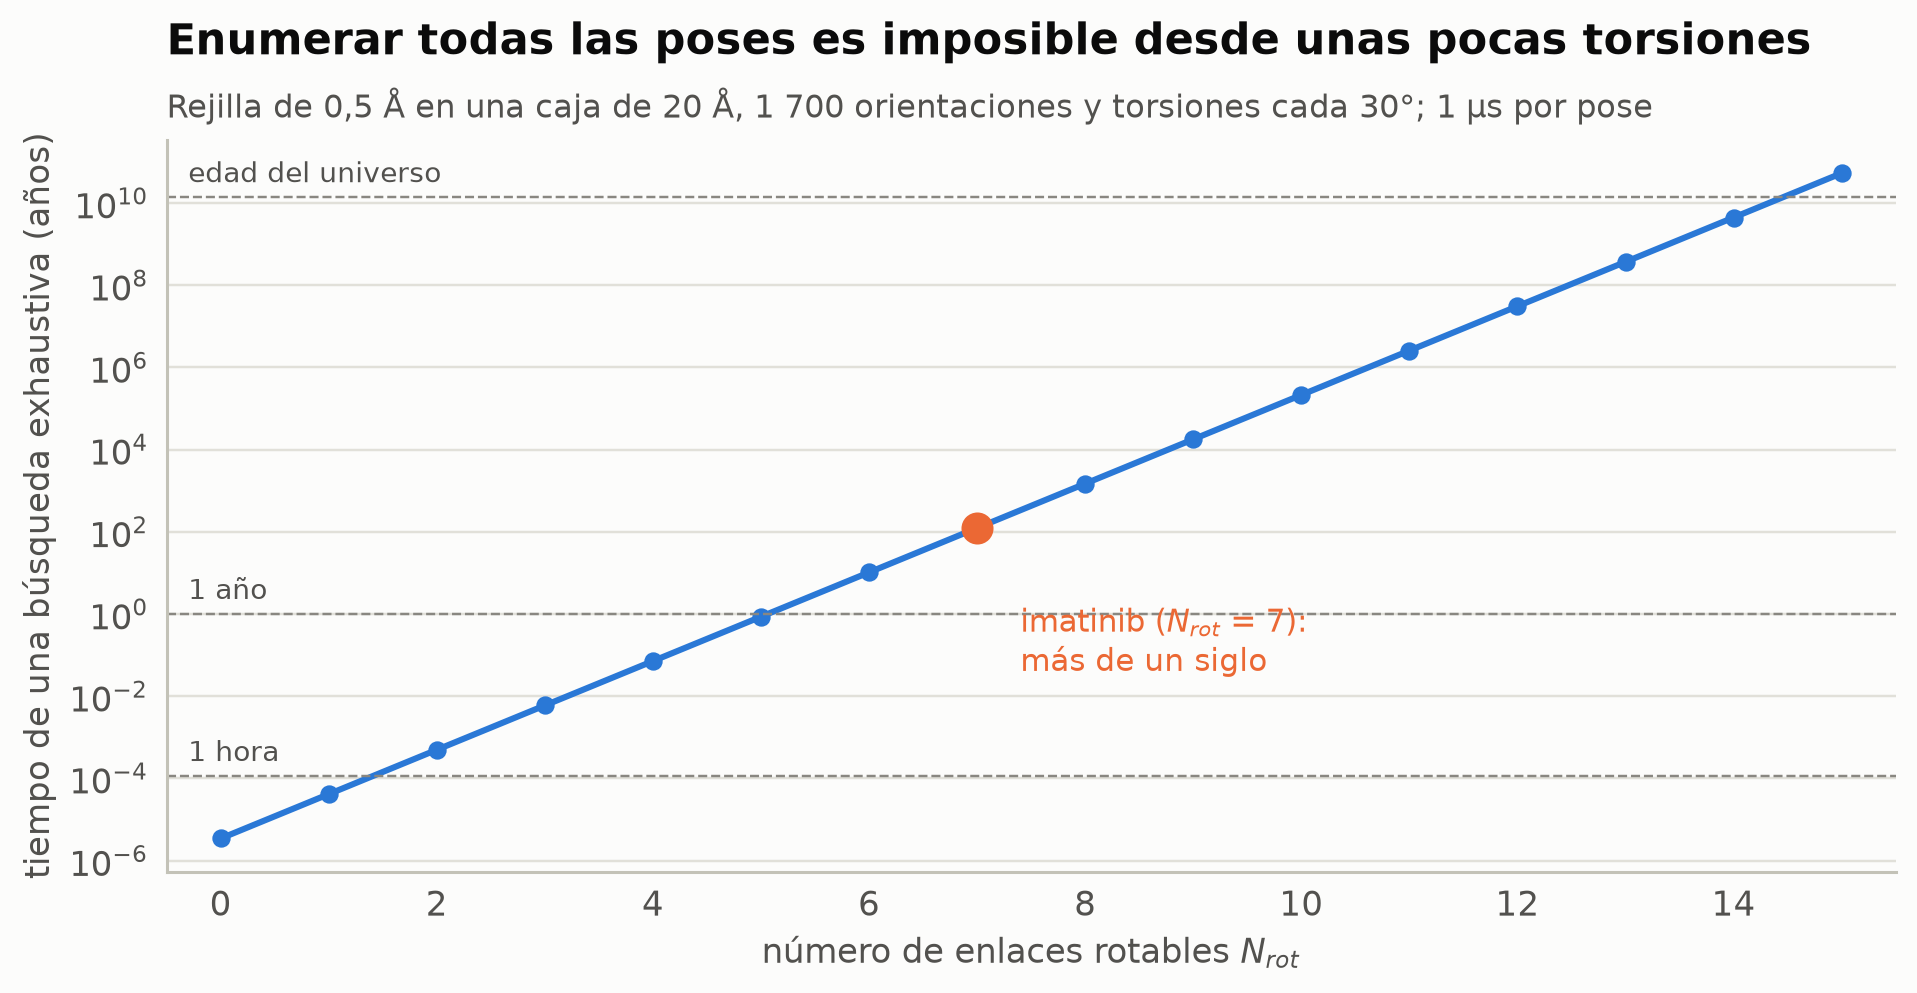

In [3]:
n_rot_ax = np.arange(0, 16)
fig, ax = plt.subplots(figsize=(8.6, 4.4))
yrs = np.array([n_poses_grid(k) * 1e-6 / 3.156e7 for k in n_rot_ax])
ax.semilogy(n_rot_ax, yrs, "-o", color=ec.BLUE, ms=5)
for yv, lab in ((1 / (365 * 24), "1 hora"), (1, "1 año"), (1.38e10, "edad del universo")):
    ax.axhline(yv, color=ec.MUTED, lw=0.8, ls="--")
    ax.text(-0.3, yv * 1.6, lab, va="bottom", ha="left", fontsize=9, color=ec.INK_2)
ax.scatter([7], [yrs[7]], s=110, color=ec.ORANGE, zorder=5)
ax.annotate("imatinib ($N_{rot}$ = 7):\nmás de un siglo", (7, yrs[7]), xytext=(7.4, yrs[7] / 3e3), fontsize=10,
            color=ec.ORANGE, arrowprops=dict(arrowstyle="-", color=ec.ORANGE))
ax.set_xlabel("número de enlaces rotables $N_{rot}$")
ax.set_ylabel("tiempo de una búsqueda exhaustiva (años)")
ax.set_xlim(-0.5, 15.5)
ec.title(ax, "Enumerar todas las poses es imposible desde unas pocas torsiones",
         "Rejilla de 0,5 Å en una caja de 20 Å, 1 700 orientaciones y torsiones cada 30°; 1 µs por pose")
plt.show()

> 🔎 **Qué observamos.** La curva es una recta en escala logarítmica: cada torsión multiplica el trabajo por 12. Un
> ligando rígido (0 torsiones) se enumeraría en unas horas, pero el imatinib ya exige un siglo, y un péptido pequeño
> superaría la edad del universo. La búsqueda **tiene** que ser estocástica y guiada por la puntuación.

Ambos factores del problema son difíciles. El espacio de búsqueda de un ligando típico, con 5 a 10 enlaces rotables,
tiene 11 a 16 dimensiones continuas y está lleno de mínimos locales. Y la energía libre de unión real incluye efectos
que ninguna función rápida captura bien: la **desolvatación** de ligando y bolsillo (hay que arrancar las moléculas de
agua que los cubrían), la pérdida de **entropía** conformacional, el papel de moléculas de agua concretas y la
**polarización**.

## 3. 🧪 Los datos: la quinasa ABL con imatinib (PDB 1IEP)

La entrada **1IEP** del Protein Data Bank contiene el dominio quinasa de ABL de ratón (idéntico en el bolsillo al humano;
la numeración es la de la isoforma 1a humana) con imatinib, resuelta por cristalografía de rayos X a 2,1 Å. Tiene dos
copias del complejo en la unidad asimétrica (cadenas A y B); trabajaremos con la **cadena A** y su imatinib (residuo
`STI 201`).

La celda siguiente lee el archivo: primero la copia del curso en `../data/153_1IEP_A.pdb.gz` (cadena A + imatinib),
si no existe lo descarga del RCSB y, como último recurso, del repositorio del curso en GitHub. Después lo pasamos a una
tabla de pandas con un lector de formato PDB de columnas fijas, como en la Lección 15.1.

In [4]:
def fetch_1iep():
    """Texto PDB de 1IEP (cadena A + imatinib): copia local → RCSB → GitHub."""
    local = os.path.join("..", "data", "153_1IEP_A.pdb.gz")
    if os.path.exists(local):
        return gzip.decompress(open(local, "rb").read()).decode(), "copia local del curso"
    try:
        with urllib.request.urlopen("https://files.rcsb.org/download/1IEP.pdb", timeout=30) as r:
            txt = r.read().decode()
        keep = [l for l in txt.splitlines() if l.startswith(("HEADER", "TITLE", "EXPDTA", "REMARK   2 RES"))
                or (l.startswith("ATOM") and l[21] == "A")
                or (l.startswith("HETATM") and l[17:20] == "STI" and l[21] == "A")]
        return "\n".join(keep) + "\nEND\n", "RCSB (files.rcsb.org)"
    except Exception:
        return course_text("153_1IEP_A.pdb.gz"), "repositorio del curso (GitHub)"

def parse_pdb(txt):
    """Registros ATOM/HETATM → DataFrame (formato PDB de columnas fijas)."""
    rows = []
    for l in txt.splitlines():
        if l.startswith(("ATOM", "HETATM")):
            rows.append(dict(record=l[:6].strip(), atom=l[12:16].strip(), resn=l[17:20].strip(), chain=l[21],
                             resi=int(l[22:26]), x=float(l[30:38]), y=float(l[38:46]), z=float(l[46:54]),
                             b=float(l[60:66]), element=l[76:78].strip()))
    return pd.DataFrame(rows)

pdb_txt, pdb_source = fetch_1iep()
atoms = parse_pdb(pdb_txt)
prot = atoms[(atoms.record == "ATOM") & (atoms.element != "H")].reset_index(drop=True)
lig = atoms[atoms.resn == "STI"].reset_index(drop=True)
XP = prot[["x", "y", "z"]].to_numpy()
XL = lig[["x", "y", "z"]].to_numpy()
print("Fuente:", pdb_source)
print([l for l in pdb_txt.splitlines() if l.startswith(("TITLE", "REMARK   2 RES"))][:2])
print(f"Proteína (cadena A): {prot.resi.nunique()} residuos ({prot.resi.min()}–{prot.resi.max()}), "
      f"{len(prot)} átomos pesados")
print(f"Imatinib (STI 201): {len(lig)} átomos pesados · composición",
      {k: int(v) for k, v in lig.element.value_counts().items()}, "· centroide", XL.mean(0).round(2))

Fuente: copia local del curso
['TITLE     CRYSTAL STRUCTURE OF THE C-ABL KINASE DOMAIN IN COMPLEX WITH STI-571. ', 'REMARK   2 RESOLUTION.    2.10 ANGSTROMS.                                       ']
Proteína (cadena A): 274 residuos (225–498), 2229 átomos pesados
Imatinib (STI 201): 37 átomos pesados · composición {'C': 29, 'N': 7, 'O': 1} · centroide [15.61 53.38 15.45]


¿Qué residuos tocan al imatinib? Buscamos pares ligando–proteína de átomos polares (N u O) a menos de 3,4 Å: son los
candidatos a **puentes de hidrógeno**, que en una quinasa tienen nombres propios. La **bisagra** (*hinge*, Met318) une
los dos lóbulos de la quinasa y es donde el ATP forma sus puentes de hidrógeno; el **portero** (Thr315) controla el
acceso a un bolsillo hidrofóbico del fondo; Glu286 pertenece a la hélice αC; Asp381 es la D del motivo **DFG**, que en
1IEP está "hacia afuera" (conformación inactiva), y los carbonilos de Ile360 e His361 sujetan el anillo de piperazina.

In [5]:
ROLE = {286: "Glu286 · hélice αC", 315: "Thr315 · portero (gatekeeper)", 318: "Met318 · bisagra (hinge)",
        360: "Ile360 · lazo catalítico", 361: "His361 · lazo catalítico", 381: "Asp381 · motivo DFG",
        382: "Phe382 · motivo DFG", 253: "Tyr253 · lazo P (rico en Gly)", 290: "Met290 · hélice αC",
        380: "Ala380", 359: "Ile359", 317: "Phe317 · bisagra"}

Dlp = np.linalg.norm(XL[:, None] - XP[None], axis=2)          # distancias ligando × proteína
polar_l = lig.element.isin(["N", "O"]).to_numpy()
polar_p = prot.element.isin(["N", "O"]).to_numpy()
hb = [(lig.atom[i], prot.resn[j], prot.resi[j], prot.atom[j], Dlp[i, j])
      for i, j in zip(*np.where((Dlp < 3.4) & polar_l[:, None] & polar_p[None]))]
hb_df = pd.DataFrame(hb, columns=["átomo ligando", "residuo", "número", "átomo proteína", "distancia (Å)"])
hb_df["papel"] = hb_df["número"].map(ROLE)
display(hb_df.round(2))

contact_res = sorted(set(prot.resi[np.where(Dlp.min(0) < 4.5)[0]]))
print(f"{len(contact_res)} residuos con algún átomo a < 4,5 Å del imatinib:", contact_res)

,átomo ligando,residuo,número,átomo proteína,distancia (Å),papel
0,N3,MET,318,N,2.90,Met318 · bisagra (hinge)
1,N13,THR,315,OG1,2.88,Thr315 · portero (gatekeeper)
2,N21,GLU,286,OE2,3.00,Glu286 · hélice αC
3,N51,ILE,360,O,2.67,Ile360 · lazo catalítico
4,N51,HIS,361,O,3.19,His361 · lazo catalítico
5,O29,ASP,381,N,2.90,Asp381 · motivo DFG


25 residuos con algún átomo a < 4,5 Å del imatinib: [248, 253, 256, 269, 270, 271, 286, 289, 290, 293, 299, 313, 315, 316, 317, 318, 321, 359, 360, 361, 362, 370, 380, 381, 382]


Seis puentes de hidrógeno, repartidos a lo largo de toda la molécula: la piridina en la bisagra (Met318), la amina
central con el portero (Thr315, **2,88 Å**: recuerde este número), la amida con Glu286 y Asp381, y la piperazina
protonada con los carbonilos de Ile360 e His361. El imatinib no se "apoya" en un punto: **atraviesa** el bolsillo de
un extremo a otro.

La figura siguiente es interactiva: gírela con el ratón y pase el cursor sobre los residuos para leer su papel.

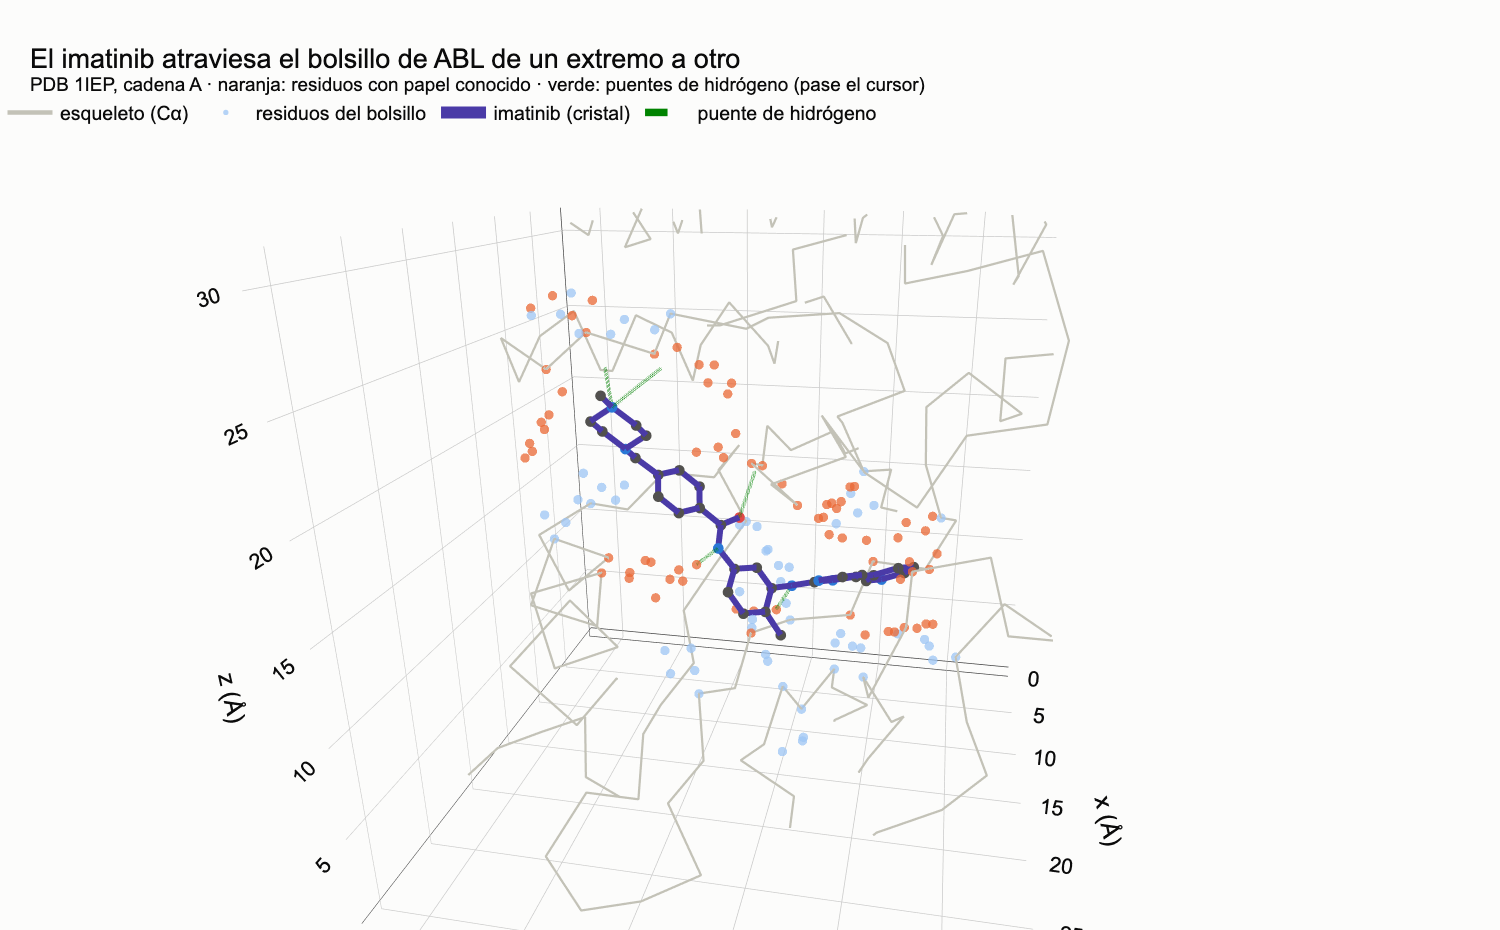

In [6]:
def bonds_by_distance(X, elements, tol=0.45):
    """Enlaces covalentes por distancia: r < R_cov(i) + R_cov(j) + tolerancia."""
    rcov = {"C": 0.76, "N": 0.71, "O": 0.66, "S": 1.05}
    r = np.array([rcov.get(e, 0.75) for e in elements])
    D = np.linalg.norm(X[:, None] - X[None], axis=2)
    i, j = np.where(np.triu(D < r[:, None] + r[None] + tol, 1))
    return list(zip(i, j))

def stick_trace(X, bonds, color, name, width=7, hover=None, showlegend=True, opacity=1.0):
    """Líneas de enlace como un único go.Scatter3d (segmentos separados por None)."""
    xs, ys, zs = [], [], []
    for a, b in bonds:
        for arr, k in ((xs, 0), (ys, 1), (zs, 2)):
            arr += [X[a, k], X[b, k], None]
    return go.Scatter3d(x=xs, y=ys, z=zs, mode="lines", line=dict(color=color, width=width), name=name,
                        hoverinfo="skip", showlegend=showlegend, opacity=opacity)

LIG_BONDS = bonds_by_distance(XL, lig.element.tolist())
EL_COLOR = {"C": "#52514e", "N": ec.BLUE, "O": ec.RED, "S": ec.YELLOW}

def pocket_figure(extra_traces=(), title=None, legend_right=False):
    fig = go.Figure()
    ca = prot[prot.atom == "CA"]
    fig.add_trace(go.Scatter3d(x=ca.x, y=ca.y, z=ca.z, mode="lines", line=dict(color="#c3c2b7", width=3),
                               name="esqueleto (Cα)", hoverinfo="skip"))
    sel = prot[prot.resi.isin(contact_res) & ~prot.atom.isin(["N", "C", "O"])]
    hov = [f"<b>{r.resn}{r.resi}</b> · átomo {r.atom}<br>{ROLE.get(r.resi, 'residuo del bolsillo')}"
           for r in sel.itertuples()]
    fig.add_trace(go.Scatter3d(x=sel.x, y=sel.y, z=sel.z, mode="markers", name="residuos del bolsillo",
                               marker=dict(size=3.5, color=[ec.ORANGE if r in ROLE else "#9ec5f4" for r in sel.resi],
                                           opacity=0.75), text=hov, hovertemplate="%{text}<extra></extra>"))
    fig.add_trace(stick_trace(XL, LIG_BONDS, ec.VIOLET, "imatinib (cristal)", width=8))
    fig.add_trace(go.Scatter3d(x=lig.x, y=lig.y, z=lig.z, mode="markers", showlegend=False,
                               marker=dict(size=4, color=[EL_COLOR[e] for e in lig.element]),
                               text=[f"imatinib · átomo <b>{a}</b> ({e})" for a, e in zip(lig.atom, lig.element)],
                               hovertemplate="%{text}<extra></extra>"))
    for r in hb_df.itertuples():
        i = int(np.where(lig.atom == r[1])[0][0])
        j = int(np.where((prot.resi == r[3]) & (prot.atom == r[4]))[0][0])
        fig.add_trace(go.Scatter3d(x=[XL[i, 0], XP[j, 0]], y=[XL[i, 1], XP[j, 1]], z=[XL[i, 2], XP[j, 2]],
                                   mode="lines", line=dict(color=ec.GREEN, width=5, dash="dash"),
                                   name="puente de hidrógeno", showlegend=bool(r.Index == 0),
                                   hovertemplate=f"puente H {r[1]}···{r[2]}{r[3]} {r[4]}: {r[5]:.2f} Å<extra></extra>"))
    for t in extra_traces:
        fig.add_trace(t)
    c = XL.mean(0)
    fig.update_layout(height=620, margin=dict(l=0, r=0, t=90, b=0),
                      title=title or ("El imatinib atraviesa el bolsillo de ABL de un extremo a otro"
                                      "<br><sup>PDB 1IEP, cadena A · naranja: residuos con papel conocido · "
                                      "verde: puentes de hidrógeno (pase el cursor)</sup>"),
                      legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0),
                      scene=dict(xaxis=dict(range=[c[0] - 16, c[0] + 16], title="x (Å)"),
                                 yaxis=dict(range=[c[1] - 16, c[1] + 16], title="y (Å)"),
                                 zaxis=dict(range=[c[2] - 16, c[2] + 16], title="z (Å)"),
                                 aspectmode="cube", camera=dict(eye=dict(x=1.5, y=0.3, z=0.6))))
    if legend_right:
        fig.update_layout(legend=dict(orientation="v", yanchor="top", y=0.9, x=0.78, xanchor="left",
                                      bgcolor="rgba(252,252,251,0.85)"), margin=dict(l=0, r=0, t=80, b=0))
    return fig

pocket_figure().show()

> 🔎 **Qué observamos.** El ligando (violeta) mide casi 20 Å de punta a punta y está rodeado por residuos por todos
> lados, salvo por la boca que da al disolvente, donde asoma la piperazina. Los puentes de hidrógeno (verde) están en
> ambos extremos y en el centro. Thr315 queda justo en el "cuello" del ligando, entre la parte que imita al ATP y la
> que se mete en el bolsillo hidrofóbico que solo existe en la conformación inactiva.

> ✅ **Compruebe su comprensión.** ¿Por qué un ligando que forma puentes de hidrógeno en tres regiones distintas del
> bolsillo es más difícil de acoplar por *docking* que uno pequeño que solo toca la bisagra? (Piense en cuántas cosas
> deben estar bien a la vez.)

## 4. Encontrar el sitio de unión y dibujar la caja

Antes de acoplar hay que saber **dónde**. Si existe una estructura del receptor con un ligando cocristalizado, como
aquí, el bolsillo es conocido y la caja se centra en él. Si no, los **detectores de bolsillos** buscan cavidades en la
superficie con criterios geométricos: regiones cóncavas donde cabe una esfera de sonda pero que están rodeadas de
proteína en muchas direcciones. A menudo se combinan con la **conservación evolutiva** de los residuos que las tapizan
(Módulo 4): un bolsillo conservado en toda una familia probablemente tiene función. El *docking* "ciego", con una
caja que abarca toda la proteína, es posible pero multiplica el espacio de búsqueda y las poses falsas.

### Un detector de bolsillos desde cero

La idea cabe en una frase: **un punto vacío está en un bolsillo si, mire hacia donde mire, pronto choca con la
proteína.** Si usted está en una plaza abierta, casi todas las direcciones están libres; en un callejón sin salida,
casi todas están bloqueadas. El algoritmo:

1. Poner una rejilla de puntos (cada 1 Å) sobre toda la proteína.
2. Quedarse con los puntos **vacíos**: ningún átomo a menos de 3 Å (cabe una sonda del tamaño de una molécula de agua).
3. Desde cada punto vacío lanzar 14 "rayos" (6 ejes y 8 diagonales) y contar cuántos chocan con un átomo antes de
   10 Å. Ese número, de 0 a 14, es el **grado de enterramiento** $b$.
4. Los puntos con $b\ge 12$ forman los bolsillos; se agrupan los puntos vecinos y se ordenan los grupos por tamaño.

Es, en miniatura, la lógica de programas como LIGSITE o fpocket.

> 🤔 **Antes de ejecutar, prediga.** ¿Será el bolsillo del imatinib el **mayor** de la quinasa? Piense en que la
> conformación DFG-afuera abre un bolsillo extra.

In [7]:
from scipy.sparse.csgraph import connected_components
from scipy.sparse import coo_matrix

def find_pockets(X, spacing=1.0, probe=3.0, ray_len=10.0, min_buried=12):
    """Detector de bolsillos por enterramiento de rayos. Devuelve puntos, enterramiento y etiquetas de grupo."""
    tree = cKDTree(X)
    lo, hi = X.min(0) - 2, X.max(0) + 2
    axes = [np.arange(a, b, spacing) for a, b in zip(lo, hi)]
    G = np.stack(np.meshgrid(*axes, indexing="ij"), -1).reshape(-1, 3)
    empty = tree.query(G, distance_upper_bound=probe)[0] == np.inf        # ningún átomo a < probe
    G = G[empty]
    G = G[tree.query(G, distance_upper_bound=8.0)[0] < np.inf]           # no muy lejos de la proteína
    dirs = np.array([[1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0], [0, 0, 1], [0, 0, -1]]
                    + [[a, b, c] for a in (1, -1) for b in (1, -1) for c in (1, -1)], float)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    steps = np.arange(1.0, ray_len + 0.01, 1.0)
    buried = np.zeros(len(G), int)
    for d in dirs:                                                        # un rayo = puntos cada 1 Å
        pts = G[:, None, :] + steps[None, :, None] * d
        hit = tree.query(pts.reshape(-1, 3), distance_upper_bound=1.8)[0].reshape(len(G), -1) < np.inf
        buried += hit.any(1)
    P = G[buried >= min_buried]
    pairs = cKDTree(P).query_pairs(spacing * 1.01, output_type="ndarray")
    A = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(len(P), len(P)))
    _, lab = connected_components(A, directed=False)
    order = np.argsort(-np.bincount(lab))                                 # grupo 0 = el más grande
    rank = np.empty_like(order); rank[order] = np.arange(len(order))
    return G, buried, P, rank[lab]

t0 = time.perf_counter()
grid_pts, buried, pocket_pts, pocket_lab = find_pockets(XP)
print(f"{len(grid_pts):,} puntos vacíos cerca de la proteína · {len(pocket_pts):,} muy enterrados "
      f"(b ≥ 12) · {time.perf_counter() - t0:.1f} s")
rows = []
for k in range(5):
    Pk = pocket_pts[pocket_lab == k]
    d_lig = cKDTree(Pk).query(XL)[0]
    rows.append(dict(bolsillo=k + 1, puntos=len(Pk), centro=Pk.mean(0).round(1),
                     **{"dist. centro–imatinib (Å)": np.linalg.norm(Pk.mean(0) - XL.mean(0)).round(1),
                        "% átomos del imatinib a < 2 Å": round(100 * np.mean(d_lig < 2), 0)}))
pockets_df = pd.DataFrame(rows)
display(pockets_df)

57,576 puntos vacíos cerca de la proteína · 329 muy enterrados (b ≥ 12) · 1.8 s


,bolsillo,puntos,centro,dist. centro–imatinib (Å),% átomos del imatinib a < 2 Å
0,1,178,"[15.4, 53.5, 14.9]",0.6,89.0
1,2,29,"[-1.8, 59.4, 30.5]",23.7,0.0
2,3,20,"[16.7, 52.6, 31.3]",15.9,0.0
3,4,12,"[16.8, 63.6, 20.3]",11.4,0.0
4,5,11,"[24.2, 57.7, 14.8]",9.6,0.0


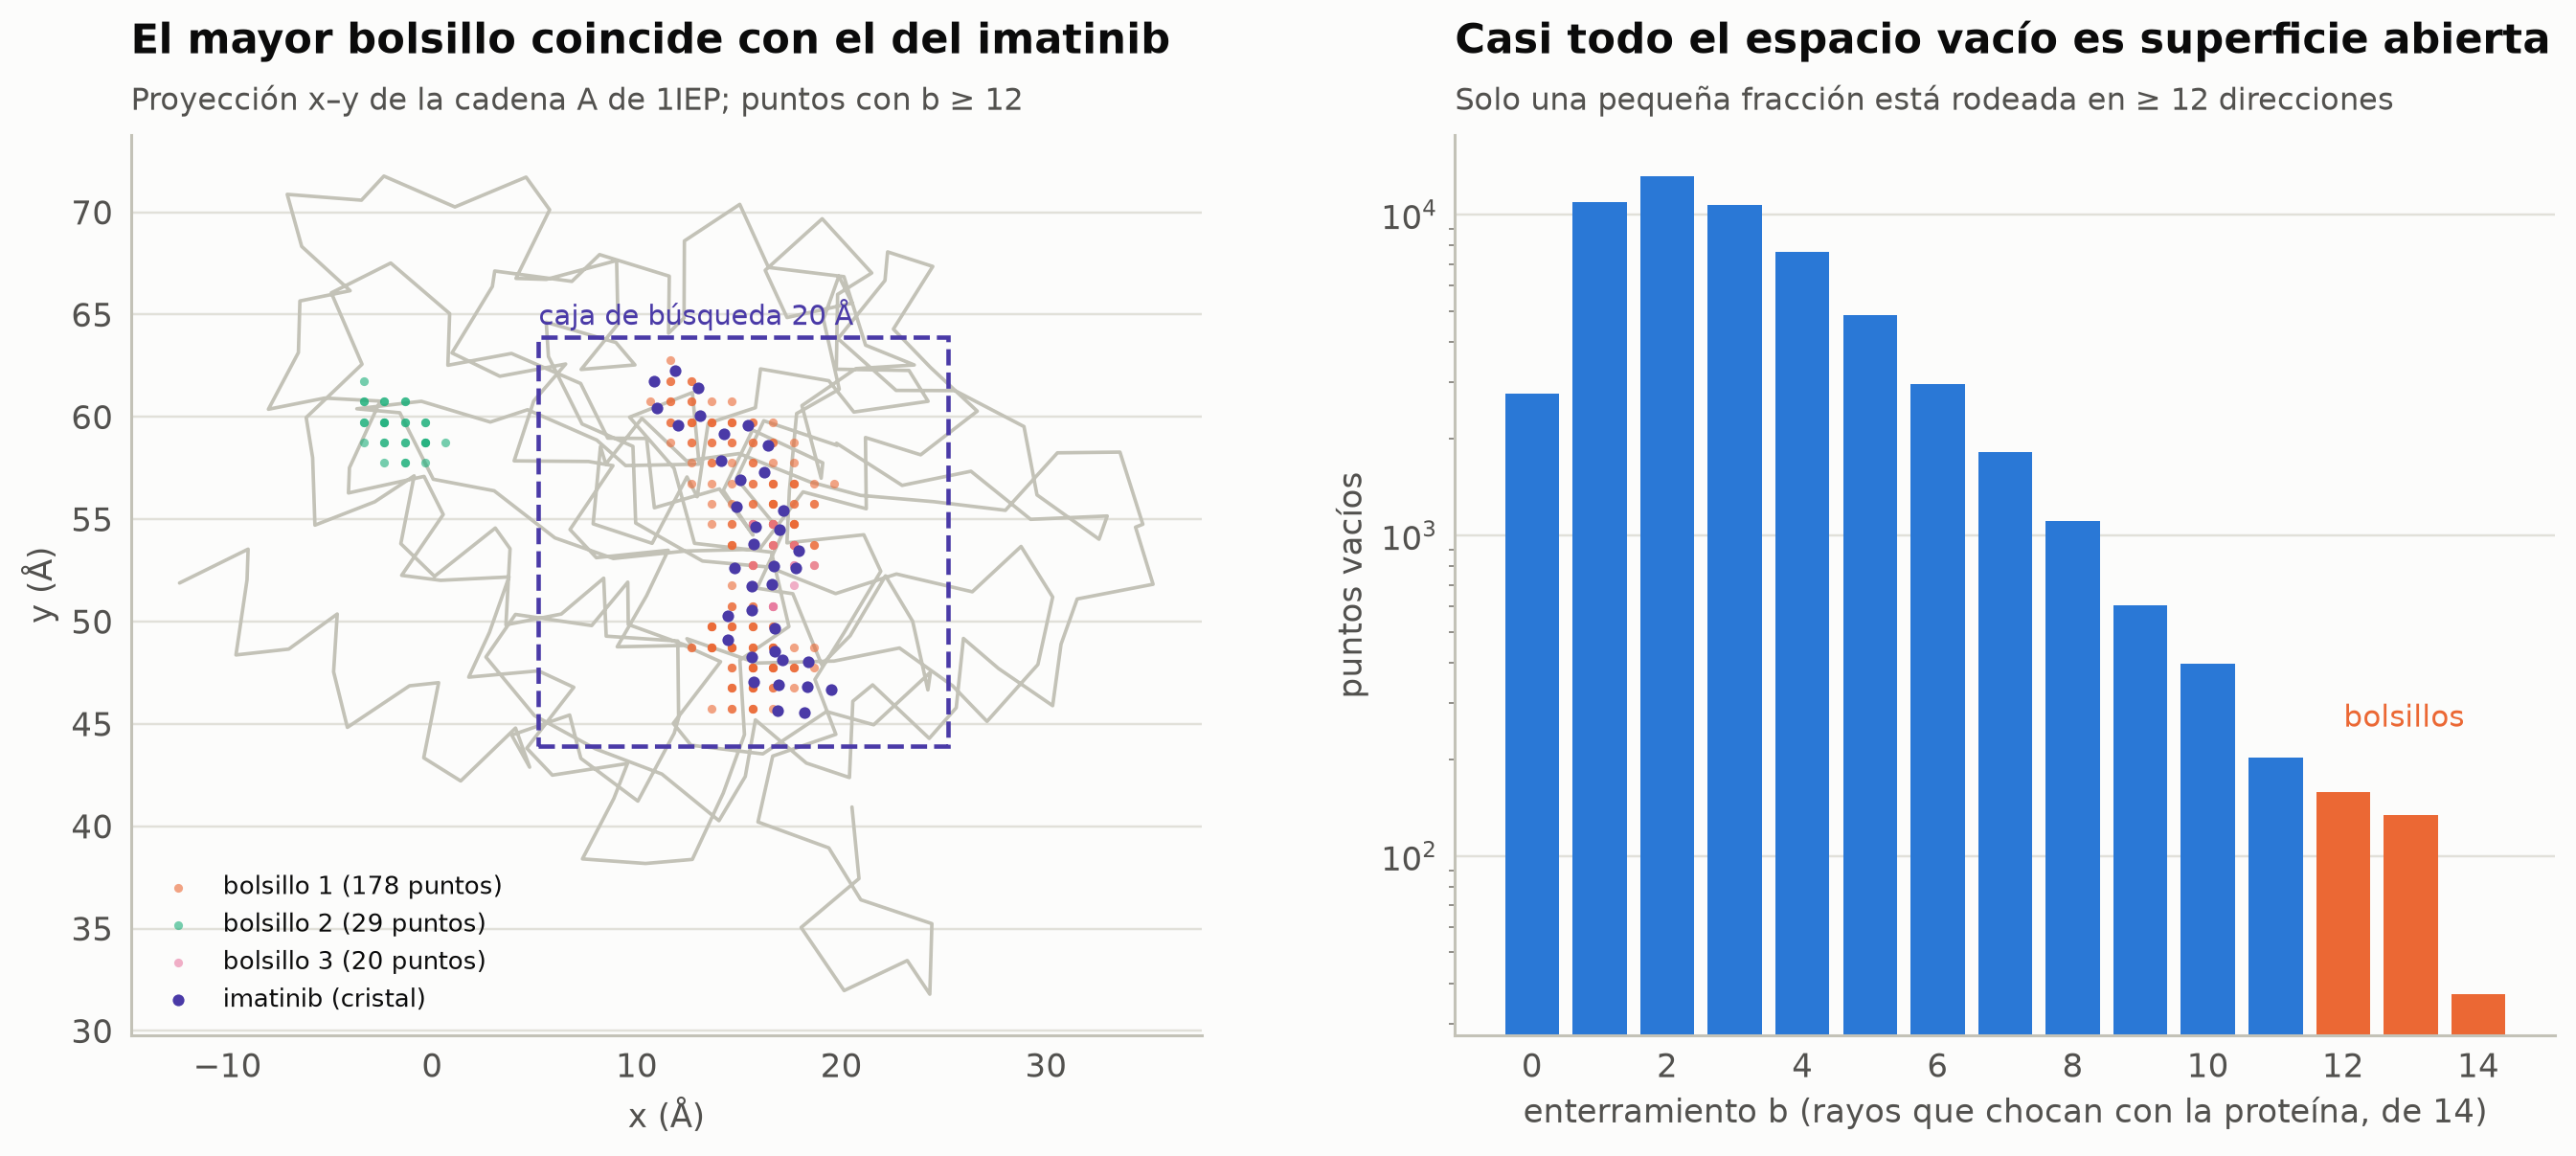

Extensión del imatinib por eje: [ 8.7 16.7 13.5] Å · centroide [15.6 53.4 15.5] · átomos dentro de la caja: 37/37
Holgura mínima entre el ligando y la pared de la caja: 1.6 Å


In [8]:
CENTER, BOX = np.array([15.2, 53.9, 16.9]), np.array([20.0, 20.0, 20.0])     # la caja del ejemplo del libro
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw=dict(width_ratios=[1.15, 1]))
ax = axes[0]
ca = prot[prot.atom == "CA"][["x", "y", "z"]].to_numpy()
ax.plot(ca[:, 0], ca[:, 1], color="#c3c2b7", lw=1.2, zorder=1)
cols = [ec.ORANGE, ec.AQUA, ec.MAGENTA]
for k in range(3):
    Pk = pocket_pts[pocket_lab == k]
    ax.scatter(Pk[:, 0], Pk[:, 1], s=9, color=cols[k], alpha=0.6, lw=0, zorder=2,
               label=f"bolsillo {k + 1} ({len(Pk)} puntos)")
ax.scatter(XL[:, 0], XL[:, 1], s=16, color=ec.VIOLET, zorder=3, label="imatinib (cristal)")
ax.add_patch(Rectangle(CENTER[:2] - BOX[:2] / 2, BOX[0], BOX[1], fill=False, ec=ec.VIOLET, lw=1.5, ls="--", zorder=4))
ax.text(CENTER[0] - BOX[0] / 2, CENTER[1] + BOX[1] / 2 + 0.6, "caja de búsqueda 20 Å", color=ec.VIOLET, fontsize=9.5)
ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)"); ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8.5, frameon=False)
ec.title(ax, "El mayor bolsillo coincide con el del imatinib", "Proyección x–y de la cadena A de 1IEP; puntos con b ≥ 12")

ax = axes[1]
bb = np.bincount(buried, minlength=15)
ax.bar(np.arange(15), bb, color=[ec.BLUE if b < 12 else ec.ORANGE for b in range(15)], width=0.8)
ax.set_yscale("log")
ax.set_xlabel("enterramiento b (rayos que chocan con la proteína, de 14)")
ax.set_ylabel("puntos vacíos")
ax.text(12.9, bb[12:].max() * 1.6, "bolsillos", color=ec.ORANGE, ha="center", fontsize=10)
ec.title(ax, "Casi todo el espacio vacío es superficie abierta", "Solo una pequeña fracción está rodeada en ≥ 12 direcciones")
plt.tight_layout(); plt.show()

inside = np.all(np.abs(XL - CENTER) <= BOX / 2, axis=1)
ext = XL.max(0) - XL.min(0)
print(f"Extensión del imatinib por eje: {ext.round(1)} Å · centroide {XL.mean(0).round(1)} · "
      f"átomos dentro de la caja: {inside.sum()}/{len(XL)}")
print(f"Holgura mínima entre el ligando y la pared de la caja: {(BOX / 2 - np.abs(XL - CENTER)).min():.1f} Å")

> 🔎 **Qué observamos.** Sin saber nada del ligando, el detector encuentra como **mayor** bolsillo de la quinasa el
> hueco que ocupa el imatinib: la hendidura entre los dos lóbulos donde se une el ATP, ampliada por el bolsillo
> hidrofóbico que abre la conformación DFG-afuera. El histograma recuerda que la mayoría del espacio vacío alrededor de
> una proteína es simplemente "afuera".

**La caja de búsqueda.** El libro usa una caja cúbica de 20 Å centrada en $(15{,}2;\ 53{,}9;\ 16{,}9)$, muy cerca del
centroide del imatinib. Hay dos reglas prácticas: la caja debe contener **todo** el ligando en cualquier pose
razonable (el imatinib mide ~16 Å a lo largo de su eje mayor), y no debe ser mucho mayor de lo necesario, porque cada
ångström extra multiplica el volumen a explorar (una caja de 30 Å tiene $(30/20)^3\approx3{,}4$ veces más volumen que
una de 20 Å). La caja es un parámetro del protocolo, y como tal debe probarse (comprobación 3 del final).

## 5. Funciones de puntuación: la función de Vina, término a término

Juzgar una pose es como juzgar si una mano encaja en un guante: no debe haber dedos atravesando la tela (choques),
pero tampoco aire sobrante (contacto pobre), y cada dedo debe ir en su funda (química complementaria). Hay tres
grandes familias de funciones de puntuación que traducen esa intuición a números:

| Familia | Idea | Ejemplos |
|---|---|---|
| **Campos de fuerza** | Términos de van der Waals y electrostáticos de la mecánica molecular | DOCK (energía), AutoDock 4 (en parte) |
| **Empíricas** | Suma de términos físicamente motivados cuyos **pesos se ajustan por regresión** a afinidades experimentales | ChemScore, GlideScore |
| **Basadas en conocimiento** | Potenciales estadísticos derivados de las frecuencias de contactos observadas en complejos del PDB | DrugScore, PMF |

La función de **AutoDock Vina** es un híbrido de las dos últimas y merece un estudio detallado, porque es la más usada
en la práctica.

### La distancia de superficie

Trott y Olson (2010) definen la energía de interacción como una suma sobre pares de átomos $(i,j)$ del ligando y del
receptor (separados por más de tres enlaces y a menos de 8 Å) de una función de la **distancia de superficie**

$$d_{ij}=r_{ij}-R_{t_i}-R_{t_j},$$

donde $r_{ij}$ es la distancia entre centros y $R_t$ el radio de van der Waals del tipo de átomo $t$ (1,9 Å para el
carbono, 1,8 para el nitrógeno, 1,7 para el oxígeno). Imagine cada átomo como una pelota de su radio: $d_{ij}=0$ cuando
las pelotas se tocan, $d_{ij}>0$ cuando hay aire entre ellas y $d_{ij}<0$ cuando se interpenetran (un choque).

### Los cinco términos

$$
\begin{aligned}
\mathrm{gauss}_1(d)&=e^{-(d/0{,}5)^2}, &\qquad
\mathrm{gauss}_2(d)&=e^{-((d-3)/2)^2},\\[2pt]
\mathrm{rep}(d)&=\begin{cases}d^2 & d<0\\0 & d\ge0\end{cases}, &
\mathrm{hidrof}(d)&=\begin{cases}1 & d<0{,}5\\ 1{,}5-d & 0{,}5\le d\le1{,}5\\ 0 & d>1{,}5\end{cases},\\[2pt]
\mathrm{puenteH}(d)&=\begin{cases}1 & d<-0{,}7\\ -d/0{,}7 & -0{,}7\le d\le0\\ 0 & d>0\end{cases},
\end{aligned}
$$

con pesos $w_{\mathrm{g1}}=-0{,}0356$, $w_{\mathrm{g2}}=-0{,}00516$, $w_{\mathrm{rep}}=0{,}840$,
$w_{\mathrm{hidrof}}=-0{,}0351$ y $w_{\mathrm{H}}=-0{,}587$. El término hidrofóbico solo se aplica entre átomos
hidrofóbicos, y el de puente de hidrógeno solo entre un donador y un aceptor. La energía intermolecular total se
corrige por la flexibilidad del ligando:

$$\boxed{\;S=\frac{\sum_{i<j} \sum_{m} w_m\,h_m(d_{ij})}{1+w_{\mathrm{rot}}\,N_{\mathrm{rot}}},\qquad w_{\mathrm{rot}}=0{,}0585.\;}$$

| Símbolo | Significado |
|---|---|
| $r_{ij}$ | Distancia entre los centros de los átomos $i$ (ligando) y $j$ (receptor), en Å |
| $R_t$ | Radio de van der Waals del tipo de átomo $t$ |
| $d_{ij}$ | Distancia entre las superficies atómicas; negativa si las esferas se interpenetran |
| $h_m,\ w_m$ | Término $m$ (gauss$_1$, gauss$_2$, rep, hidrof, puenteH) y su peso ajustado |
| $N_{\mathrm{rot}}$ | Número de enlaces rotables del ligando (entre átomos pesados, no terminales) |
| $w_{\mathrm{rot}}$ | Penalización por enlace rotable (0,0585) |
| $S$ | Puntuación final, que Vina expresa en kcal/mol como estimación de $\Delta G$ de unión |

La lógica es clara: la gaussiana **estrecha** premia el contacto íntimo; la **ancha**, la proximidad general; la
**repulsión** castiga los choques; y los dos términos lineales recompensan los contactos **hidrofóbicos** y los
**puentes de hidrógeno**. Llama la atención lo que **falta**: no hay término electrostático explícito ni
desolvatación. Los pesos se ajustaron para reproducir afinidades experimentales, así que esos efectos quedan
absorbidos, de forma promedio, en los términos existentes. Es una función deliberadamente simple, y su virtud es la
velocidad.

### Ejemplo a mano: dos pares de átomos

**Dos carbonos hidrofóbicos a $r=3{,}8$ Å.** $d=3{,}8-1{,}9-1{,}9=0$: las superficies se tocan.
$\mathrm{gauss}_1=e^0=1$; $\mathrm{gauss}_2=e^{-(-3/2)^2}=e^{-2{,}25}=0{,}105$; $\mathrm{rep}=0$; $\mathrm{hidrof}=1$;
no hay puente de hidrógeno. Energía:
$-0{,}0356(1)-0{,}00516(0{,}105)-0{,}0351(1)=\mathbf{-0{,}071}$ kcal/mol.

**Un N donador y un O aceptor a $r=3{,}03$ Å.** $d=3{,}03-1{,}8-1{,}7=-0{,}47$ (se interpenetran un poco).
$\mathrm{gauss}_1=e^{-(0{,}94)^2}=0{,}413$; $\mathrm{gauss}_2=e^{-(3{,}47/2)^2}=0{,}049$; $\mathrm{rep}=0{,}47^2=0{,}221$;
$\mathrm{puenteH}=0{,}47/0{,}7=0{,}671$. Energía:
$-0{,}0147-0{,}0003+0{,}1856-0{,}3940=\mathbf{-0{,}224}$ kcal/mol, tres veces más favorable que el par de carbonos.

Programemos las funciones **exactamente** como en el script que genera las figuras del libro y comprobemos estas cifras.

In [9]:
def vina_terms(dsurf):
    """Los cinco términos de Vina en función de la distancia de superficie d (Å)."""
    g1 = np.exp(-(dsurf / 0.5) ** 2)
    g2 = np.exp(-((dsurf - 3.0) / 2.0) ** 2)
    rep = np.where(dsurf < 0, dsurf ** 2, 0.0)
    hyd = np.clip((1.5 - dsurf) / 1.0, 0, 1)
    hb = np.clip(-dsurf / 0.7, 0, 1)
    return g1, g2, rep, hyd, hb

W = dict(g1=-0.0356, g2=-0.00516, rep=0.840, hyd=-0.0351, hb=-0.587)
W_ROT = 0.0585
VDW = {"C": 1.9, "N": 1.8, "O": 1.7, "S": 2.0}

def pair_energy(r, Ri, Rj, hydrophobic=False, hbond=False):
    g1, g2, rep, hyd, hb = vina_terms(r - Ri - Rj)
    return W["g1"] * g1 + W["g2"] * g2 + W["rep"] * rep + W["hyd"] * hyd * hydrophobic + W["hb"] * hb * hbond

print(f"C···C a 3,80 Å: {pair_energy(3.80, 1.9, 1.9, hydrophobic=True):.4f} kcal/mol")
print(f"N···O a 3,03 Å: {pair_energy(3.03, 1.8, 1.7, hbond=True):.4f} kcal/mol")

r = np.linspace(2.4, 8.0, 400)                     # la misma malla que el libro
e_cc = pair_energy(r, 1.9, 1.9, hydrophobic=True)
e_hb = pair_energy(r, 1.8, 1.7, hbond=True)
print(f"mínimo C···C en r = {r[e_cc.argmin()]:.2f} Å (e = {e_cc.min():.3f}); "
      f"mínimo N···O en r = {r[e_hb.argmin()]:.2f} Å (e = {e_hb.min():.3f})")

C···C a 3,80 Å: -0.0712 kcal/mol
N···O a 3,03 Å: -0.2235 kcal/mol
mínimo C···C en r = 3.80 Å (e = -0.071); mínimo N···O en r = 3.03 Å (e = -0.224)


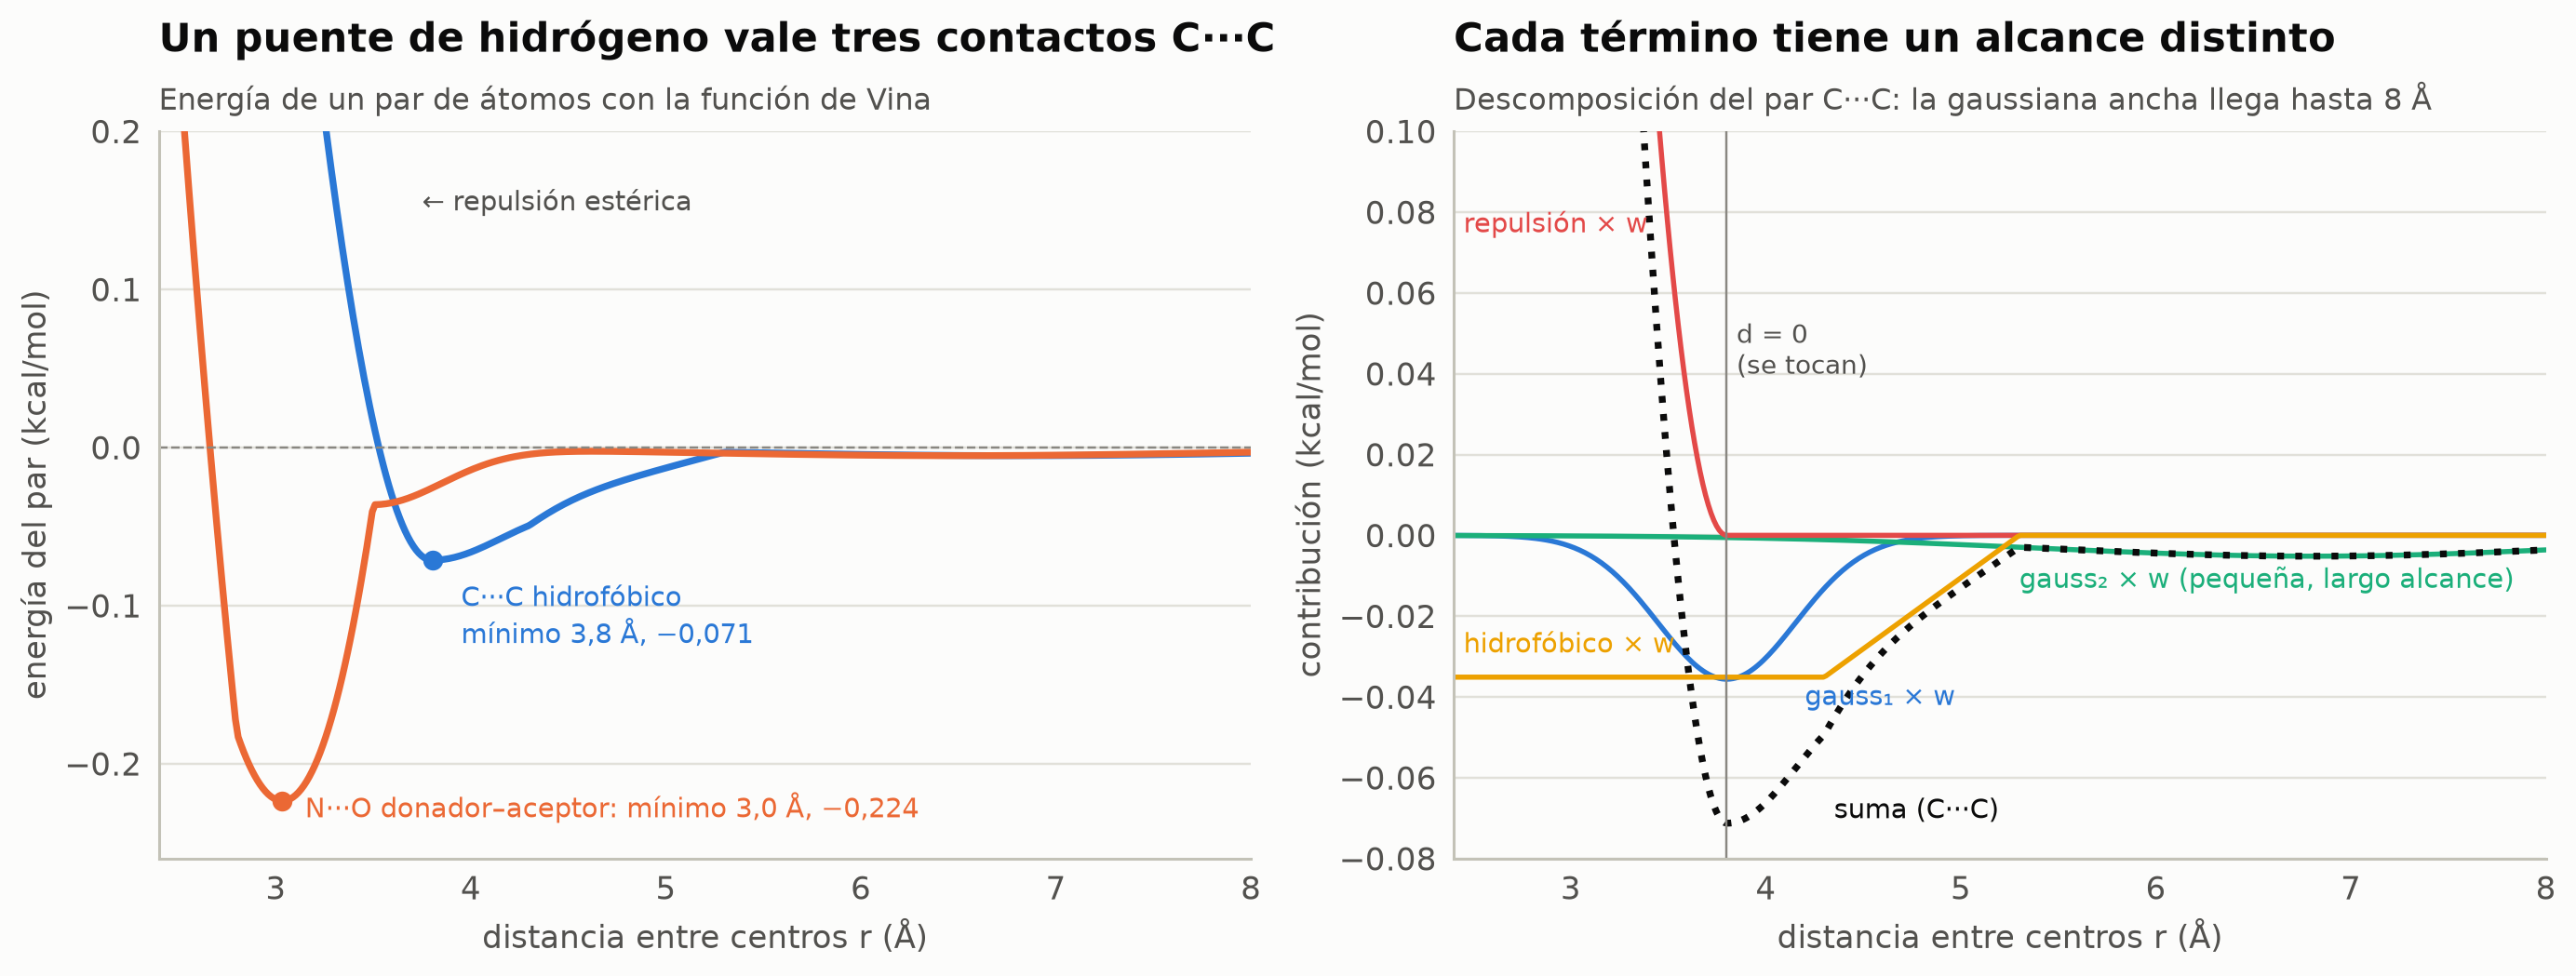

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.9))
ax = axes[0]
ax.plot(r, e_cc, color=ec.BLUE, lw=2.4)
ax.plot(r, e_hb, color=ec.ORANGE, lw=2.4)
ax.axhline(0, color=ec.MUTED, lw=0.8, ls="--")
ax.scatter([r[e_cc.argmin()]], [e_cc.min()], color=ec.BLUE, zorder=5)
ax.scatter([r[e_hb.argmin()]], [e_hb.min()], color=ec.ORANGE, zorder=5)
ax.text(3.95, -0.085, "C···C hidrofóbico\nmínimo 3,8 Å, −0,071", color=ec.BLUE, fontsize=9.5, va="top")
ax.text(3.15, -0.228, "N···O donador–aceptor: mínimo 3,0 Å, −0,224", color=ec.ORANGE, fontsize=9.5, va="center")
ax.text(3.75, 0.15, "← repulsión estérica", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(2.4, 8); ax.set_ylim(-0.26, 0.2)
ax.set_xlabel("distancia entre centros r (Å)"); ax.set_ylabel("energía del par (kcal/mol)")
ec.title(ax, "Un puente de hidrógeno vale tres contactos C···C", "Energía de un par de átomos con la función de Vina")

ax = axes[1]
g1, g2, rep, hyd, hb = vina_terms(r - 3.8)
parts = [("gauss₁ × w", W["g1"] * g1, ec.BLUE, (4.2, -0.042)), ("gauss₂ × w (pequeña, largo alcance)", W["g2"] * g2, ec.AQUA, (5.3, -0.013)),
         ("repulsión × w", W["rep"] * rep, ec.RED, (2.45, 0.075)), ("hidrofóbico × w", W["hyd"] * hyd, ec.YELLOW, (2.45, -0.029))]
for lab, y, c, pos in parts:
    ax.plot(r, y, color=c, lw=1.8)
    ax.text(*pos, lab, color=c, fontsize=9.5)
ax.plot(r, e_cc, color=ec.INK, lw=2.4, ls=":")
ax.text(4.35, -0.07, "suma (C···C)", fontsize=9.5)
ax.axvline(3.8, color=ec.MUTED, lw=0.8); ax.text(3.85, 0.04, "d = 0\n(se tocan)", fontsize=9, color=ec.INK_2)
ax.set_xlim(2.4, 8); ax.set_ylim(-0.08, 0.1)
ax.set_xlabel("distancia entre centros r (Å)"); ax.set_ylabel("contribución (kcal/mol)")
ec.title(ax, "Cada término tiene un alcance distinto", "Descomposición del par C···C: la gaussiana ancha llega hasta 8 Å")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Las curvas reproducen la figura del libro: el par de carbonos tiene su mínimo, −0,071 kcal/mol,
> justo donde se tocan sus superficies (3,8 Å), y el par donador–aceptor, −0,224 kcal/mol a 3,0 Å, la distancia típica
> N···O de un puente de hidrógeno. A la derecha se ve por qué: el término hidrofóbico y la gaussiana estrecha crean el
> pozo, la repulsión cuadrática crea la pared y la gaussiana ancha, pequeña pero de largo alcance, "atrae desde lejos".
> Un ligando con decenas de contactos suma estas pequeñas contribuciones hasta alcanzar varias kcal/mol.

### Tipos de átomo: quién es hidrofóbico, quién dona, quién acepta

Para aplicar la función a una proteína real necesitamos **tipificar** cada átomo pesado. Vina usa los tipos "XS":

| Tipo XS | Regla | Ejemplo en ABL |
|---|---|---|
| `C_H` | carbono unido solo a C o H | cadenas laterales de Leu, Val, Phe |
| `C_P` | carbono unido a N u O (polarizado) | Cα, carbonilos |
| `N_D` / `O_D` | N u O con un hidrógeno polar: **donador** | N del esqueleto, NZ de Lys, NE2 de Gln |
| `N_A` / `O_A` | aceptor (N aromático sin H, O de carbonilo) | O del esqueleto, N de piridina del imatinib |
| `O_DA` | donador **y** aceptor (hidroxilo) | OG1 de Thr, Ser, Tyr |
| `N_P` | N sin H ni par libre disponible | N de prolina |

Los archivos `.pdbqt` que prepara **Meeko** (el formato de AutoDock) traen los hidrógenos **polares** explícitos (tipo
`HD`) y los tipos AutoDock (`C`, `A` para carbono aromático, `N`, `NA`, `OA`…); de ahí derivamos los tipos XS con dos
reglas geométricas: un N/O es donador si tiene un `HD` a menos de 1,15 Å, y un carbono es polar si tiene un N u O a
menos de 1,75 Å. Leemos el receptor preparado (el mismo que usará Vina) y el imatinib cristalográfico preparado.

In [11]:
def read_pdbqt(txt):
    rows = []
    for l in txt.splitlines():
        if l.startswith(("ATOM", "HETATM")):
            rows.append(dict(atom=l[12:16].strip(), resn=l[17:20].strip(), resi=int(l[22:26]),
                             x=float(l[30:38]), y=float(l[38:46]), z=float(l[46:54]), ad=l[77:79].strip()))
    return pd.DataFrame(rows)

def xs_types(df):
    """Tipos XS de Vina a partir de los tipos AutoDock de un pdbqt (con H polares). Devuelve solo átomos pesados."""
    X = df[["x", "y", "z"]].to_numpy(); ad = df.ad.to_numpy()
    heavy = ~np.isin(ad, ["H", "HD", "HS"])
    tree = cKDTree(X)
    el_map = {"A": "C", "NA": "N", "OA": "O", "SA": "S"}
    xs = []
    for i in np.where(heavy)[0]:
        el = el_map.get(ad[i], ad[i])
        nb_ = [j for j in tree.query_ball_point(X[i], 1.75) if j != i]
        if el == "C":
            xs.append("C_P" if any(ad[j] in ("N", "NA", "OA") for j in nb_) else "C_H")
        elif el in ("N", "O"):
            don = any(ad[j] == "HD" and np.linalg.norm(X[j] - X[i]) < 1.15 for j in nb_)
            acc = ad[i] in ("NA", "OA")
            xs.append(f"{el}_" + ("DA" if don and acc else "D" if don else "A" if acc else "P"))
        else:
            xs.append("S_P" if el == "S" else el)
    out = df[heavy].reset_index(drop=True).copy()
    out["xs"] = xs
    out["element"] = [t.split("_")[0] for t in xs]
    return out

rec = xs_types(read_pdbqt(course_text("153_1IEP_A_receptor.pdbqt.gz")))
ligq = xs_types(read_pdbqt(course_text("153_imatinib_xtal.pdbqt")))
# ordenamos los átomos del ligando como en el PDB (por coordenadas idénticas)
order = [int(np.argmin(np.linalg.norm(ligq[["x", "y", "z"]].to_numpy() - p, axis=1))) for p in XL]
ligq = ligq.iloc[order].reset_index(drop=True)
assert (ligq.atom.to_numpy() == lig.atom.to_numpy()).all()
print("Receptor:", len(rec), "átomos pesados ·", {k: int(v) for k, v in rec["xs"].value_counts().items()})
print("Imatinib:", {k: int(v) for k, v in ligq["xs"].value_counts().items()})
print("Donadores/aceptores del imatinib:", list(ligq.loc[ligq["xs"].str.contains("_D|_A"), "atom"] + ":" +
                                                ligq.loc[ligq["xs"].str.contains("_D|_A"), "xs"]))
print("Thr315 OG1 →", rec.loc[(rec.resi == 315) & (rec.atom == "OG1"), "xs"].item())

Receptor:

 2229 átomos pesados · {'C_P': 735, 'C_H': 700, 'O_A': 369, 'N_D': 343, 'O_DA': 45, 'S_P': 18, 'N_P': 13, 'N_A': 6}
Imatinib: {'C_H': 15, 'C_P': 14, 'N_A': 4, 'N_D': 3, 'O_A': 1}
Donadores/aceptores del imatinib: ['N3:N_A', 'N10:N_A', 'N8:N_A', 'N13:N_D', 'N21:N_D', 'N48:N_A', 'N51:N_D', 'O29:O_A']
Thr315 OG1 → O_DA


Ahora la función completa. La escribimos **vectorizada**: una matriz de distancias ligando × receptor, las
propiedades de cada tipo como vectores booleanos y las cinco sumas con NumPy. Además de la puntuación total, devolvemos
la matriz de energías por par, que nos permitirá repartir la energía entre residuos.

In [12]:
def type_props(xs):
    """Radio, hidrofóbico, donador, aceptor para una lista de tipos XS."""
    xs = np.asarray(xs)
    R = np.array([VDW[t.split("_")[0]] for t in xs])
    return R, xs == "C_H", np.char.endswith(xs.astype(str), "_D") | np.char.endswith(xs.astype(str), "_DA"), \
        np.char.endswith(xs.astype(str), "_A") | np.char.endswith(xs.astype(str), "_DA")

class VinaLikeScorer:
    """Función de puntuación de Vina escrita desde cero (átomos pesados, corte de 8 Å)."""
    def __init__(self, rec_xyz, rec_xs, lig_xs, n_rot, cutoff=8.0):
        self.X = np.asarray(rec_xyz, float)
        self.Rr, self.Hr, self.Dr, self.Ar = type_props(rec_xs)
        self.Rl, self.Hl, self.Dl, self.Al = type_props(lig_xs)
        self.n_rot, self.cutoff = n_rot, cutoff
        self.hyd_mask = self.Hl[:, None] & self.Hr[None]
        self.hb_mask = (self.Dl[:, None] & self.Ar[None]) | (self.Al[:, None] & self.Dr[None])

    def terms(self, L):
        r = np.linalg.norm(L[:, None] - self.X[None], axis=2)
        m = r < self.cutoff
        g1, g2, rep, hyd, hb = vina_terms(r - self.Rl[:, None] - self.Rr[None])
        return dict(g1=g1 * m, g2=g2 * m, rep=rep * m, hyd=hyd * m * self.hyd_mask, hb=hb * m * self.hb_mask)

    def pair_matrix(self, L):
        return sum(W[k] * v for k, v in self.terms(L).items())

    def inter(self, L):
        return float(self.pair_matrix(L).sum())

    def score(self, L):
        return self.inter(L) / (1 + W_ROT * self.n_rot)

VINA = json.loads(course_text("153_redocking_vina.json"))       # resultados precalculados con Vina 1.2.7
N_ROT = VINA["torsdof"]
scorer = VinaLikeScorer(rec[["x", "y", "z"]].to_numpy(), rec["xs"], ligq["xs"], N_ROT)
T = {k: float((W[k] * v).sum()) for k, v in scorer.terms(XL).items()}
inter_x = sum(T.values())
print("Contribución de cada término en la pose cristalográfica (kcal/mol):",
      {k: round(v, 2) for k, v in T.items()})
print(f"Suma intermolecular (nuestra)  = {inter_x:7.2f}  |  Vina: {VINA['crystal_score'][1]:7.2f}")
print(f"S = suma / (1 + 0,0585·{N_ROT}) = {inter_x / (1 + W_ROT * N_ROT):7.2f}  |  Vina: {VINA['crystal_score'][0]:7.2f}")

Contribución de cada término en la pose cristalográfica (kcal/mol): {'g1': -5.49, 'g2': -11.37, 'rep': 4.86, 'hyd': -2.98, 'hb': -2.88}
Suma intermolecular (nuestra)  =  -17.85  |  Vina:  -17.63
S = suma / (1 + 0,0585·7) =  -12.67  |  Vina:  -12.51


Nuestra implementación de unas 30 líneas da una suma intermolecular a ~1 % de la de AutoDock Vina 1.2.7 para el mismo
complejo (la pequeña diferencia viene de detalles de implementación: Vina interpola en rejillas precalculadas y trata
algunos tipos raros de forma especial). Y fíjese en la división: $1+0{,}0585\times7=1{,}41$; exactamente así obtiene
Vina su número final a partir de la suma intermolecular.

¿**Quién** aporta esa energía? Sumemos la matriz de pares por residuo del receptor.

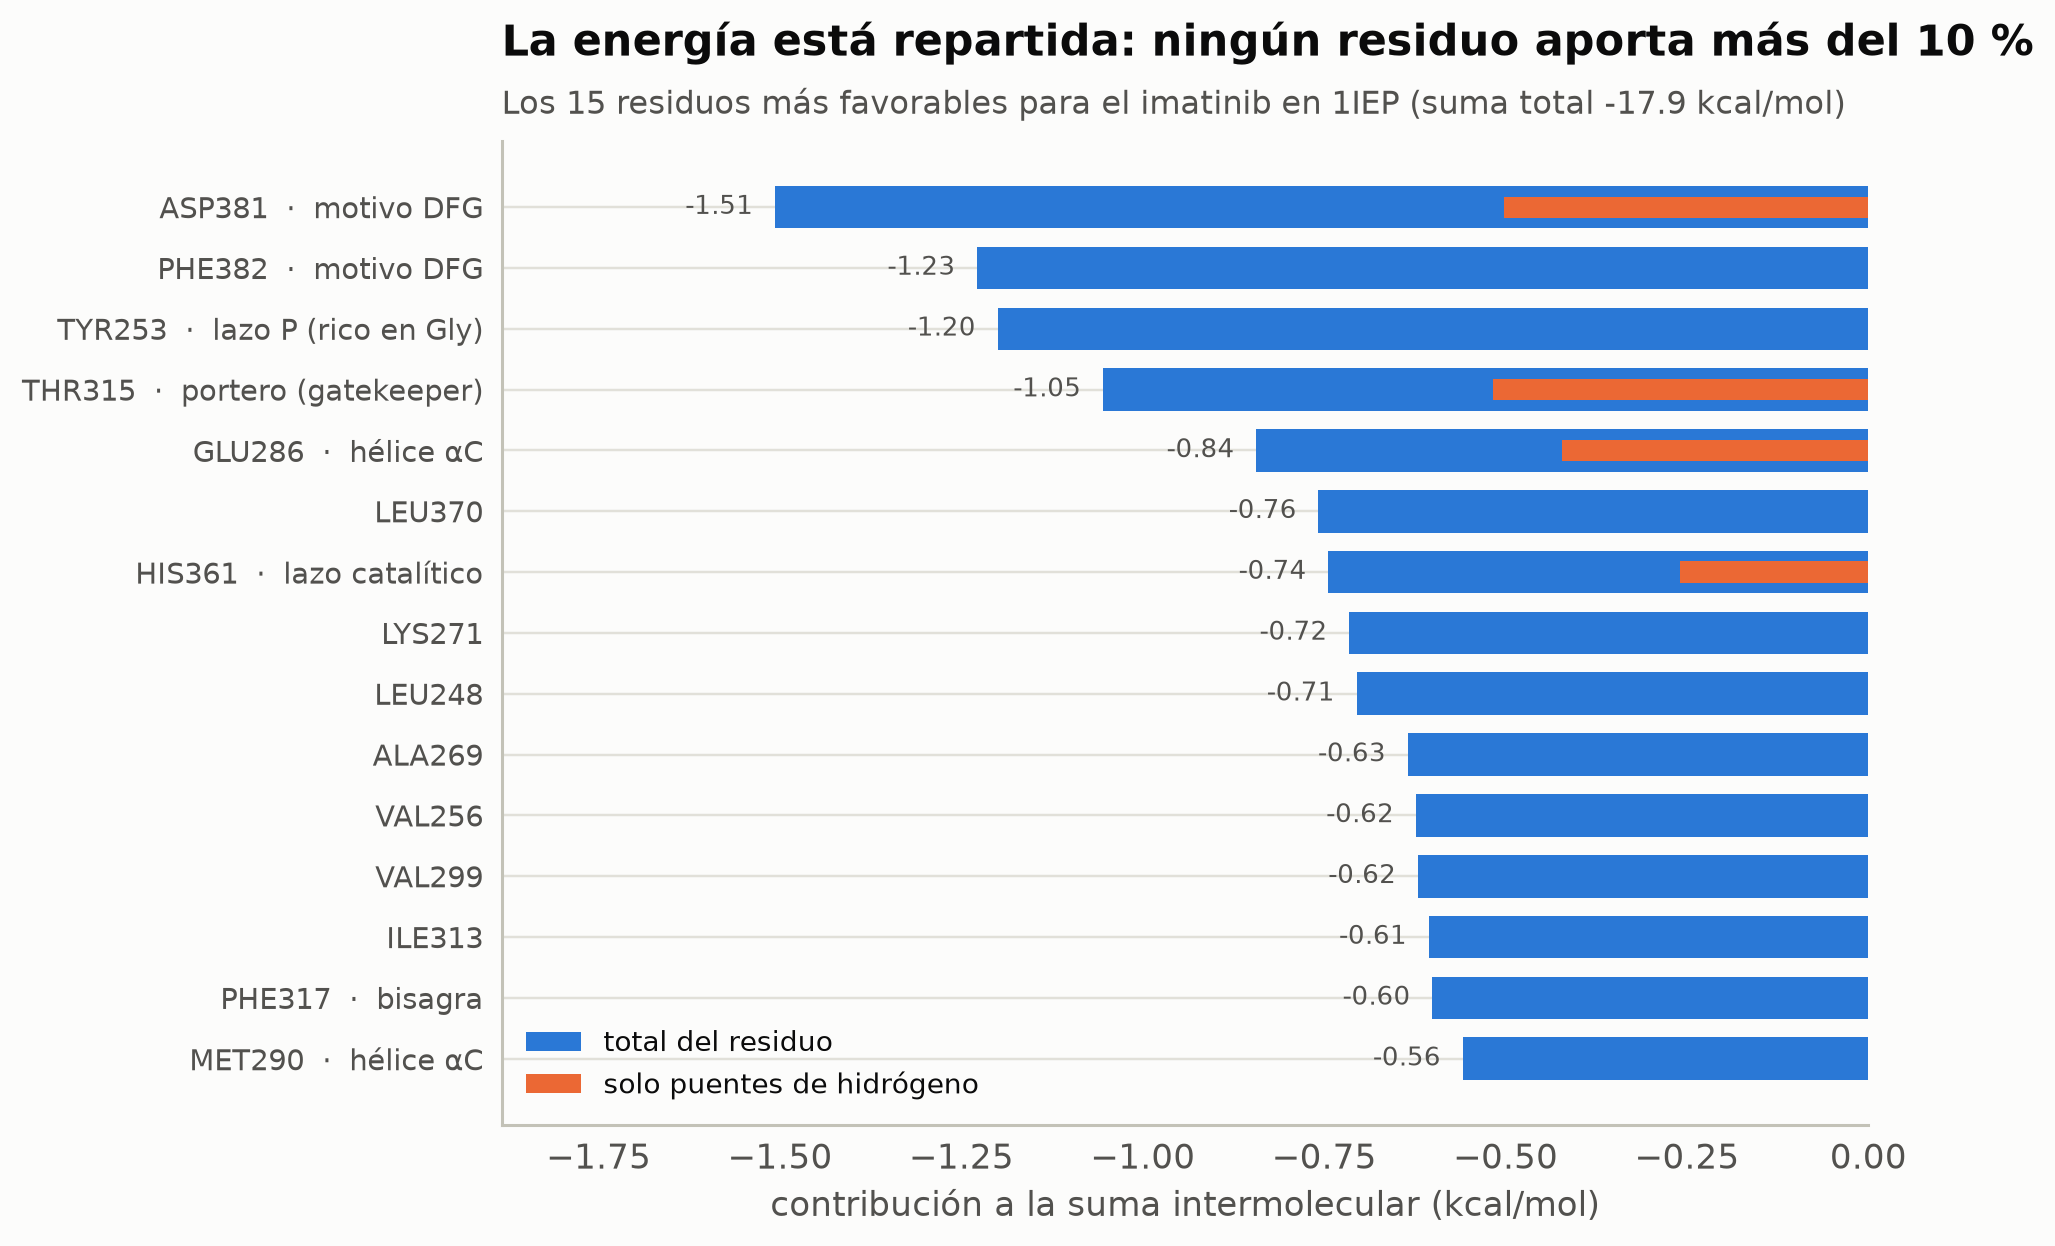

Thr315: -1.05 kcal/mol, de ellos -0.52 por el puente de hidrógeno


In [13]:
E_pair = scorer.pair_matrix(XL)
res_key = rec.resn + rec.resi.astype(str)
per_res = pd.Series(E_pair.sum(0), index=res_key).groupby(level=0, sort=False).sum().sort_values()
hb_part = pd.Series((W["hb"] * scorer.terms(XL)["hb"]).sum(0), index=res_key).groupby(level=0, sort=False).sum()
top = per_res.head(15)[::-1]
fig, ax = plt.subplots(figsize=(9, 5.8))
y = np.arange(len(top))
ax.barh(y, top.values, color=ec.BLUE, height=0.7, label="total del residuo")
ax.barh(y, hb_part.reindex(top.index).values, color=ec.ORANGE, height=0.35, label="solo puentes de hidrógeno")
role_short = [ROLE.get(int(k[3:]), "").split("·")[-1].strip() for k in top.index]
ax.set_yticks(y); ax.set_yticklabels([f"{k}  ·  {rl}" if rl else k for k, rl in zip(top.index, role_short)],
                                     fontsize=9.5)
for yi, v in zip(y, top.values):
    ax.text(v - 0.03, yi, f"{v:.2f}", va="center", ha="right", fontsize=8.5, color=ec.INK_2)
ax.set_xlabel("contribución a la suma intermolecular (kcal/mol)")
ax.legend(loc="lower left", frameon=False, fontsize=9)
ax.set_xlim(top.values.min() * 1.25, 0)
ec.title(ax, "La energía está repartida: ningún residuo aporta más del 10 %",
         f"Los 15 residuos más favorables para el imatinib en 1IEP (suma total {inter_x:.1f} kcal/mol)")
plt.tight_layout(); plt.show()
print(f"Thr315: {per_res['THR315']:.2f} kcal/mol, de ellos {hb_part['THR315']:.2f} por el puente de hidrógeno")

> 🔎 **Qué observamos.** La afinidad del imatinib no depende de un solo "gancho": decenas de residuos aportan
> fracciones de kcal/mol, la mayoría por contactos hidrofóbicos (barras azules sin naranja). Los puentes de
> hidrógeno de la bisagra (Met318), del portero (Thr315) y de la amida (Glu286, Asp381) son contribuciones
> concentradas, pero aun así son una parte menor del total. Esa energía distribuida es típica de los buenos
> inhibidores, y también explica por qué **una sola mutación** en el lugar adecuado puede estropearlo todo:
> veremos en la sección 11 qué hace T315I con estas cifras.

> ✅ **Compruebe su comprensión.** Si desplazáramos el imatinib 1 Å hacia la proteína, ¿qué término de Vina cambiaría
> más? ¿Y si lo alejáramos 3 Å? (Pista: mire el alcance de cada curva de la figura anterior.)

## 6. De la puntuación a la constante de disociación

Un químico médico no pregunta "¿cuántas kcal/mol?", pregunta "¿**a qué concentración** funciona?". La **constante de
disociación** $K_d$ es la concentración de ligando a la que la mitad de las moléculas de proteína están ocupadas:
cuanto menor, más fuerte la unión. Un fármaco típico tiene $K_d$ en el rango nanomolar ($10^{-9}$ M). La termodinámica
conecta ambas escalas:

$$\Delta G = RT\ln K_d \quad\Longleftrightarrow\quad K_d = e^{\Delta G/RT},\qquad RT = 0{,}593\ \text{kcal/mol a } 298\ \text{K}.$$

| Símbolo | Significado |
|---|---|
| $\Delta G$ | Energía libre de unión (kcal/mol); negativa = unión favorable |
| $K_d$ | Constante de disociación (M = mol/L) |
| $R$ | Constante de los gases, $1{,}987\times10^{-3}$ kcal/(mol·K) |
| $T$ | Temperatura absoluta (298 K = 25 °C) |

### Ejemplo del libro: «De la puntuación a la constante de disociación»

Suponga que la suma intermolecular de una pose es de $-10{,}5$ kcal/mol y que el ligando tiene $N_{\mathrm{rot}}=5$
enlaces rotables. La corrección divide por $1+0{,}0585\times5=1{,}29$, de modo que $S=-8{,}12$ kcal/mol: la
flexibilidad le cuesta al ligando más de 2 kcal/mol, porque al unirse pierde la libertad de girar esos enlaces. Si
interpretamos $S$ como energía libre de unión, a 298 K:

$$K_d = e^{\Delta G/RT}=e^{-8{,}12/0{,}593}\approx1{,}1\times10^{-6}\ \mathrm{M}\approx1{,}1\ \mu\mathrm{M}.$$

Cada $RT\ln10=1{,}36$ kcal/mol adicionales multiplica la afinidad por diez: $-9$ kcal/mol corresponde a unos
$0{,}25\ \mu$M y $-12$ kcal/mol a unos $1{,}6$ nM. Pero no tome estas cifras al pie de la letra: el error típico de
las funciones de puntuación al predecir afinidades absolutas es de unas **2 kcal/mol**, es decir, más de un orden de
magnitud en $K_d$. El *docking* ordena poses de un mismo ligando mucho mejor que afinidades entre ligandos distintos.

> 🤔 **Antes de ejecutar, prediga.** Vina da −12,5 kcal/mol al imatinib en su pose cristalográfica. ¿Qué $K_d$
> implica? ¿Y cuál sería el intervalo si el error es de ±2 kcal/mol?

In [14]:
RT = 0.593                                           # kcal/mol a 298 K

def score_to_kd(S, rt=RT):
    """Puntuación (kcal/mol, interpretada como ΔG) → K_d en molar."""
    return np.exp(np.asarray(S) / rt)

def fmt_conc(M):
    for f, u in ((1, "M"), (1e-3, "mM"), (1e-6, "µM"), (1e-9, "nM"), (1e-12, "pM")):
        if M >= 0.1 * f:
            return f"{M / f:.2g} {u}"
    return f"{M / 1e-15:.2g} fM"

inter_ex, nrot_ex = -10.5, 5
S_ex = inter_ex / (1 + W_ROT * nrot_ex)
print(f"1 + 0,0585·{nrot_ex} = {1 + W_ROT * nrot_ex:.2f} → S = {S_ex:.2f} kcal/mol → K_d = {fmt_conc(score_to_kd(S_ex))}")
print(f"RT·ln 10 = {RT * np.log(10):.3f} kcal/mol por orden de magnitud")
for s in (-9, -12):
    print(f"S = {s} kcal/mol → K_d ≈ {fmt_conc(score_to_kd(s))}")
S_im = VINA["crystal_score"][0]
print(f"\nImatinib en 1IEP (Vina): S = {S_im:.2f} → K_d ≈ {fmt_conc(score_to_kd(S_im))}; con ±2 kcal/mol: "
      f"{fmt_conc(score_to_kd(S_im - 2))} – {fmt_conc(score_to_kd(S_im + 2))}")

1 + 0,0585·5 = 1.29 → S = -8.12 kcal/mol → K_d = 1.1 µM
RT·ln 10 = 1.365 kcal/mol por orden de magnitud
S = -9 kcal/mol → K_d ≈ 0.26 µM
S = -12 kcal/mol → K_d ≈ 1.6 nM

Imatinib en 1IEP (Vina): S = -12.51 → K_d ≈ 0.69 nM; con ±2 kcal/mol: 24 pM – 20 nM


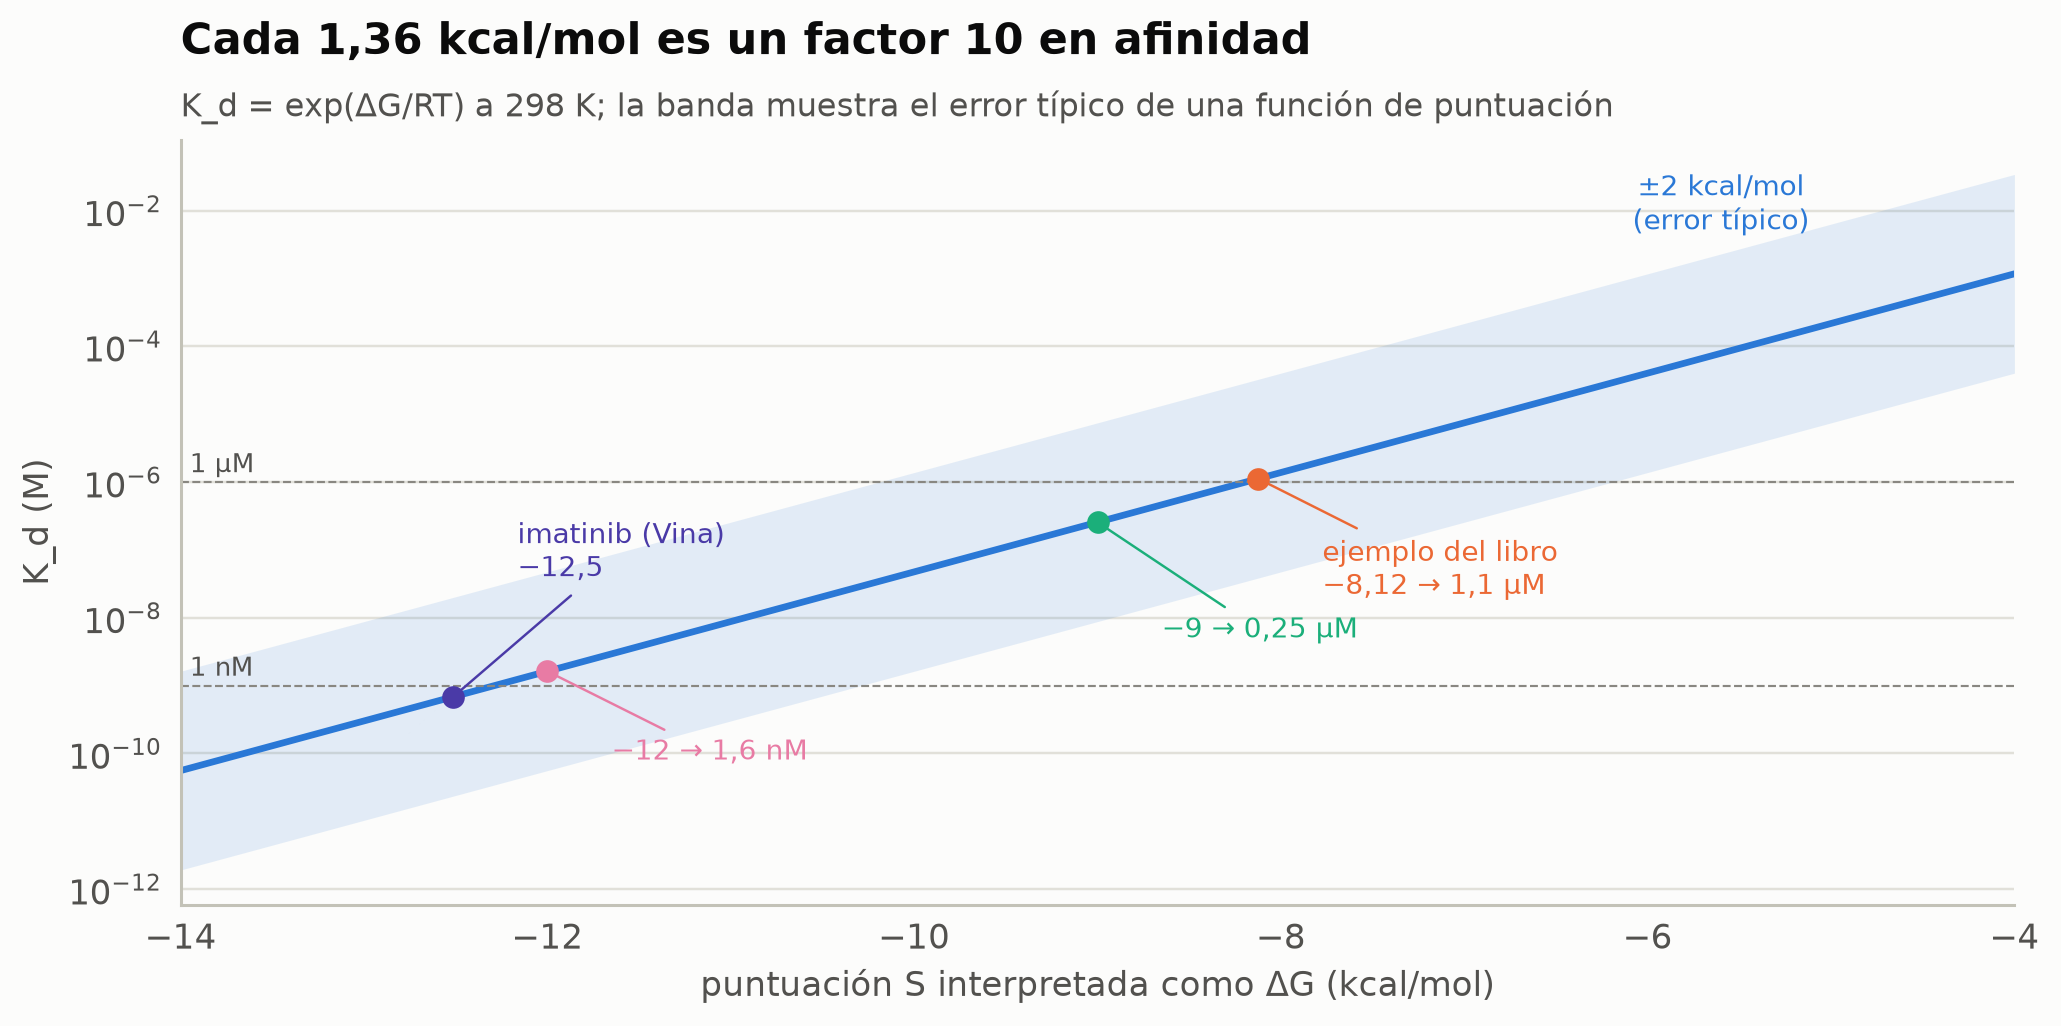

In [15]:
S_ax = np.linspace(-14, -4, 200)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.fill_between(S_ax, score_to_kd(S_ax - 2), score_to_kd(S_ax + 2), color=ec.BLUE, alpha=0.12, lw=0)
ax.semilogy(S_ax, score_to_kd(S_ax), color=ec.BLUE, lw=2.2)
ax.text(-5.6, score_to_kd(-5.6 + 2) * 2.3, "±2 kcal/mol\n(error típico)", color=ec.BLUE, fontsize=9, ha="center")
pts = [(S_ex, "ejemplo del libro\n−8,12 → 1,1 µM", ec.ORANGE), (-9, "−9 → 0,25 µM", ec.AQUA),
       (-12, "−12 → 1,6 nM", ec.MAGENTA), (S_im, f"imatinib (Vina)\n{S_im:.1f}".replace(".", ",").replace("-", "−"), ec.VIOLET)]
for s, lab, c in pts:
    ax.scatter([s], [score_to_kd(s)], color=c, s=55, zorder=5)
    dy = 0.02 if s != S_im else 60
    ax.annotate(lab, (s, score_to_kd(s)), xytext=(s + 0.35, score_to_kd(s) * (dy if s != -12 else 0.05)),
                fontsize=9, color=c, arrowprops=dict(arrowstyle="-", color=c, lw=0.8))
for yv, lab in ((1e-6, "1 µM"), (1e-9, "1 nM")):
    ax.axhline(yv, color=ec.MUTED, lw=0.7, ls="--"); ax.text(-13.95, yv * 1.4, lab, fontsize=8.5, color=ec.INK_2)
ax.set_xlabel("puntuación S interpretada como ΔG (kcal/mol)"); ax.set_ylabel("K_d (M)")
ax.set_xlim(-14, -4)
ec.title(ax, "Cada 1,36 kcal/mol es un factor 10 en afinidad",
         "K_d = exp(ΔG/RT) a 298 K; la banda muestra el error típico de una función de puntuación")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** La relación es exponencial: en escala logarítmica, una recta. La banda de ±2 kcal/mol abarca
> **tres órdenes de magnitud** en total: el imatinib, con −12,5 kcal/mol, podría estar según Vina en cualquier punto
> entre decenas de picomolar y decenas de nanomolar. Las medidas experimentales de su afinidad por ABL caen en el
> rango nanomolar, dentro de esa banda, pero la banda es tan ancha que la coincidencia dice poco. Moraleja: la
> puntuación sirve para **ordenar**, no para **medir**.

> ✅ **Compruebe su comprensión.** Dos compuestos obtienen −9,2 y −9,6 kcal/mol. ¿Qué factor de afinidad predice Vina
> entre ellos? ¿Tiene sentido concluir que el segundo es mejor? (Respuesta: $e^{0{,}4/0{,}593}\approx2$; con un error
> de ~2 kcal/mol, no.)

## 7. Búsqueda conformacional: Monte Carlo, minimización local y Metropolis

Imagine que busca el punto más bajo de una región montañosa, de noche y con niebla. Solo sabe la altura donde pisa y
la pendiente bajo sus pies. Si siempre baja (minimización local pura), llegará al fondo del **primer** valle que
encuentre, que casi nunca es el más profundo. Una estrategia mejor: bajar hasta el fondo del valle, luego dar un
**salto** a un sitio cercano al azar, volver a bajar, y comparar: si el nuevo fondo es más bajo, se queda; si es más
alto, a veces se queda de todos modos, para no quedar atrapado.

Los algoritmos de búsqueda del *docking* son variados: búsqueda sistemática sobre una rejilla de ángulos, construcción
incremental del ligando fragmento a fragmento dentro del bolsillo, algoritmos genéticos (el de AutoDock 4) y métodos
de Monte Carlo. Vina usa una **búsqueda local iterada**, exactamente la estrategia descrita: parte de una pose
aleatoria, la **perturba** (un desplazamiento, un giro o el cambio de una torsión), **minimiza localmente** la energía
con el método cuasi-Newton BFGS usando las derivadas analíticas de la función de puntuación, y **acepta o rechaza** la
nueva pose con el criterio de Metropolis:

$$\boxed{\;\Pr(\text{aceptar})=\min\!\big(1,\ e^{-(S_{\text{nueva}}-S_{\text{actual}})/T}\big)\;}$$

que acepta siempre las mejoras y ocasionalmente los empeoramientos, para escapar de mínimos locales.

| Símbolo | Significado |
|---|---|
| $S_{\text{nueva}},\ S_{\text{actual}}$ | Puntuaciones de la pose propuesta (ya minimizada) y de la actual |
| $T$ | "Temperatura" del algoritmo: controla cuánto se toleran los empeoramientos (mismas unidades que $S$) |

**Ejemplo a mano.** Con $T=1{,}2$: una propuesta que **empeora** 0,5 kcal/mol se acepta con probabilidad
$e^{-0{,}5/1{,}2}=0{,}66$; una que empeora 3 kcal/mol, con $e^{-3/1{,}2}=0{,}082$; una que mejora, siempre. Con
$T=0{,}3$ esas probabilidades bajan a $0{,}19$ y $4{,}5\times10^{-5}$: la búsqueda se vuelve "avara".

Varias de estas cadenas corren en paralelo (el parámetro `exhaustiveness` controla cuántas), y para acelerar la
evaluación, la contribución de cada tipo de átomo del ligando se **precalcula en una rejilla tridimensional** sobre la
caja de búsqueda. Con estas decisiones, Trott y Olson (2010) informaron una aceleración de unos dos órdenes de magnitud
respecto a AutoDock 4 junto con una mayor exactitud en la predicción de poses.

### El paisaje de puntuación del libro

Para **ver** la búsqueda necesitamos pocas dimensiones. El libro usa un paisaje de juguete sobre dos "coordenadas de
pose": un embudo profundo en la **pose nativa** $(0{,}6;\ 0{,}4)$, un mínimo **falso** en $(-1{,}7;\ -1{,}4)$ y una
rugosidad sinusoidal que crea muchos mínimos locales pequeños:

$$S(u,v) = -9\,e^{-[(u-0{,}6)^2+(v-0{,}4)^2]/1{,}6} - 6{,}5\,e^{-[(u+1{,}7)^2+(v+1{,}4)^2]/0{,}5} + 0{,}35\,\sin(3u)\cos(3v).$$

La figura siguiente es interactiva: gírela y pase el cursor por la superficie.

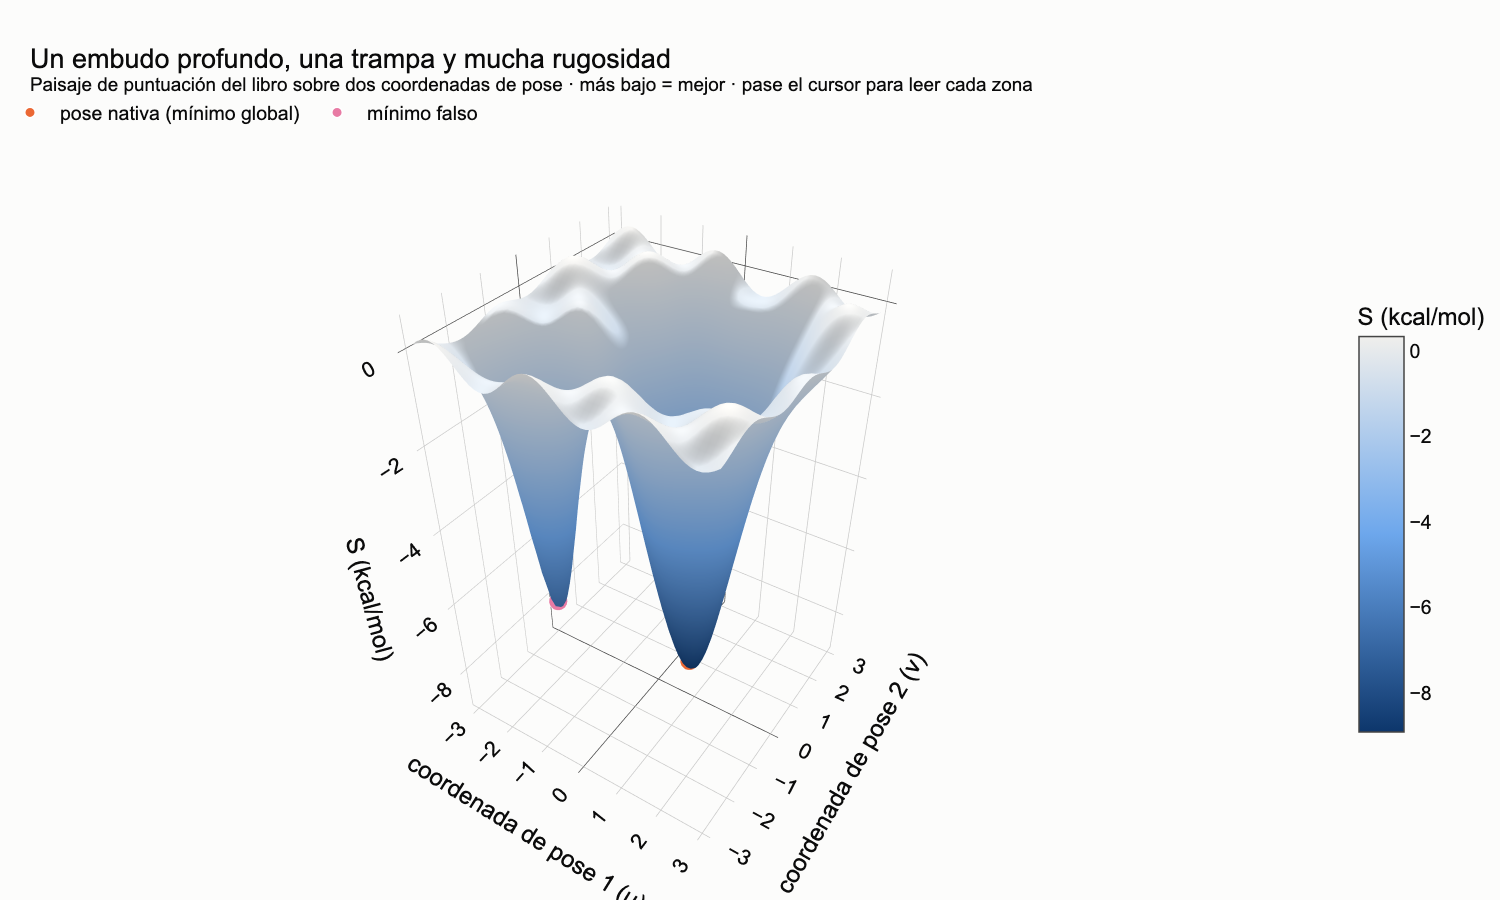

S(pose nativa) = -8.88 · S(mínimo falso) = -6.70 kcal/mol


In [16]:
def landscape(u, v):
    """Paisaje de puntuación del libro (dos coordenadas de pose)."""
    return (-9 * np.exp(-((u - 0.6) ** 2 + (v - 0.4) ** 2) / 1.6)
            - 6.5 * np.exp(-((u + 1.7) ** 2 + (v + 1.4) ** 2) / 0.5)
            + 0.35 * np.sin(3 * u) * np.cos(3 * v))

xg = np.linspace(-3, 3, 61)                          # la misma rejilla que el libro (61 × 61)
UU, VV = np.meshgrid(xg, xg)
ZZ = landscape(UU, VV)
NATIVE, FALSE_MIN = np.array([0.6, 0.4]), np.array([-1.7, -1.4])

def zone(u, v):
    if np.hypot(u - NATIVE[0], v - NATIVE[1]) < 0.8:
        return "embudo de la pose nativa"
    if np.hypot(u - FALSE_MIN[0], v - FALSE_MIN[1]) < 0.6:
        return "mínimo falso (embudo trampa)"
    return "ladera: la rugosidad crea mínimos locales"

hover = np.vectorize(zone)(UU, VV)
fig = go.Figure(go.Surface(x=xg, y=xg, z=ZZ, colorscale=[[0, "#0d366b"], [0.5, "#6da7ec"], [1, "#f0efec"]],
                           customdata=hover, colorbar=dict(title="S (kcal/mol)", len=0.6),
                           hovertemplate="u = %{x:.2f}, v = %{y:.2f}<br>S = %{z:.2f} kcal/mol<br>%{customdata}"
                                         "<extra></extra>"))
for p, name, c in ((NATIVE, "pose nativa (mínimo global)", ec.ORANGE), (FALSE_MIN, "mínimo falso", ec.MAGENTA)):
    fig.add_trace(go.Scatter3d(x=[p[0]], y=[p[1]], z=[landscape(*p) + 0.3], mode="markers",
                               marker=dict(size=7, color=c, line=dict(color="white", width=1)), name=name,
                               hovertemplate=f"{name}<br>S = {landscape(*p):.2f} kcal/mol<extra></extra>"))
fig.update_layout(height=600, margin=dict(l=0, r=0, t=90, b=0),
                  title="Un embudo profundo, una trampa y mucha rugosidad<br><sup>Paisaje de puntuación del libro sobre "
                        "dos coordenadas de pose · más bajo = mejor · pase el cursor para leer cada zona</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0),
                  scene=dict(xaxis_title="coordenada de pose 1 (u)", yaxis_title="coordenada de pose 2 (v)",
                             zaxis_title="S (kcal/mol)", camera=dict(eye=dict(x=1.1, y=-1.7, z=1.6))))
fig.show()
print(f"S(pose nativa) = {landscape(*NATIVE):.2f} · S(mínimo falso) = {landscape(*FALSE_MIN):.2f} kcal/mol")

Programemos las dos estrategias y comparémoslas con la **misma** cantidad de pasos, empezando en la trampa:

* **Metropolis puro**: proponer un pequeño salto al azar y aceptarlo o no con la ecuación de Metropolis, sin
  minimizar.
* **Monte Carlo con minimización local** (la estrategia de Vina, también llamada *basin hopping*): salto al azar,
  minimización con BFGS (`scipy.optimize.minimize`) y Metropolis entre los **fondos** de los valles.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuál de las dos escapará más a menudo del mínimo falso en 30 pasos? ¿Qué pasará
> si bajamos mucho la temperatura?

In [17]:
def f_land(p):
    return landscape(p[0], p[1])

def local_min(p):
    """Minimización local BFGS dentro del cuadrado [-3, 3]² (L-BFGS-B admite límites)."""
    o = minimize(f_land, p, method="L-BFGS-B", bounds=[(-3, 3), (-3, 3)])
    return o.x, o.fun

def mc_chain(start, n_steps, T, step, with_minimization, rng):
    """Una cadena de Monte Carlo. Devuelve la trayectoria de poses aceptadas y la mejor encontrada."""
    p = np.array(start, float)
    s = f_land(p)
    if with_minimization:
        p, s = local_min(p)
    traj, best = [(p.copy(), s)], (p.copy(), s)
    for _ in range(n_steps):
        q = np.clip(p + rng.normal(0, step, 2), -3, 3)            # perturbación
        sq = f_land(q)
        if with_minimization:
            q, sq = local_min(q)                                   # bajar al fondo del valle
        if sq < s or rng.random() < np.exp(-(sq - s) / T):          # criterio de Metropolis
            p, s = q, sq
        traj.append((p.copy(), s))
        if s < best[1]:
            best = (p.copy(), s)
    return traj, best

def first_success(traj):
    """Primer paso en que la cadena está en el embudo nativo (a < 0,5 de la pose nativa); None si nunca."""
    for k, (p, _) in enumerate(traj):
        if np.linalg.norm(p - NATIVE) < 0.5:
            return k
    return None

t0 = time.perf_counter()
settings = {"Metropolis puro, T = 1,2": (1.2, 0.3, False), "Metropolis puro, T = 4": (4.0, 0.3, False),
            "MC + minimización, T = 1,2": (1.2, 1.0, True), "MC + minimización, T = 0,01": (0.01, 1.0, True)}
checkpoints = [1, 3, 10, 30]
rows = {}
for name, (T_, step_, with_min) in settings.items():
    rng_ = np.random.default_rng(0)
    hits = []
    for _ in range(40):                                           # 40 cadenas que empiezan en la trampa
        traj, _ = mc_chain(FALSE_MIN + rng_.normal(0, 0.2, 2), 30, T_, step_, with_min, rng_)
        hits.append(first_success(traj))
    rows[name] = [np.mean([h is not None and h <= c for h in hits]) for c in checkpoints]
mc_df = pd.DataFrame(rows, index=[f"≤ {c} pasos" for c in checkpoints]).T
display((100 * mc_df).round(0).astype(int).astype(str) + " %")
print(f"(40 cadenas por fila, empezando en el mínimo falso · {time.perf_counter() - t0:.1f} s)")

,≤ 1 pasos,≤ 3 pasos,≤ 10 pasos,≤ 30 pasos
"Metropolis puro, T = 1,2",0 %,0 %,0 %,0 %
"Metropolis puro, T = 4",0 %,0 %,0 %,2 %
"MC + minimización, T = 1,2",25 %,52 %,80 %,100 %
"MC + minimización, T = 0,01",25 %,52 %,82 %,100 %


(40 cadenas por fila, empezando en el mínimo falso · 1.2 s)


> 🔎 **Qué observamos.** El Metropolis puro, con pasos pequeños, casi nunca sale de la trampa: cada paso cuesta
> arriba se rechaza con alta probabilidad y, aunque suba la temperatura, deambula sin rumbo por la rugosidad. La
> minimización local cambia el problema: ya no se compara una pose con otra, sino un **valle** con otro, y basta con
> que **un** salto caiga en la cuenca del embudo nativo para que BFGS lo lleve al fondo y Metropolis lo acepte (es una
> mejora). Por eso Vina minimiza **cada** propuesta. En este paisaje, con un embudo nativo ancho, incluso la cadena
> "congelada" ($T=0{,}01$, que nunca acepta empeoramientos) escapa, porque saltos de 1 unidad ya alcanzan el embudo; en
> los paisajes reales, de 13 dimensiones y con barreras más anchas, aceptar empeoramientos sí es imprescindible. La
> lección general: **el tamaño del salto y la minimización importan más que la temperatura**.

La animación siguiente muestra **una** cadena de Monte Carlo con minimización: cada salto (gris), su descenso al fondo
del valle (línea) y la decisión de Metropolis (verde = aceptado, rojo = rechazado).

In [18]:
def mc_chain_verbose(start, n_steps, T, step, seed):
    """Como mc_chain (con minimización) pero guarda cada propuesta, su mínimo y la decisión."""
    rng_ = np.random.default_rng(seed)
    p, s = local_min(np.array(start, float))
    log = [dict(cur=p.copy(), s=s, prop=None, qmin=None, sq=None, acc=True)]
    for _ in range(n_steps):
        q0 = np.clip(p + rng_.normal(0, step, 2), -3, 3)
        q, sq = local_min(q0)
        acc = sq < s or rng_.random() < np.exp(-(sq - s) / T)
        log.append(dict(cur=p.copy(), s=s, prop=q0, qmin=q, sq=sq, acc=acc))
        if acc:
            p, s = q, sq
    return log

# buscamos una semilla cuya cadena escape de la trampa (ilustrativa); el algoritmo es el mismo para todas
for seed_anim in range(200):
    mc_log = mc_chain_verbose(FALSE_MIN + np.array([-0.4, -0.5]), 30, 1.2, 1.0, seed_anim)
    esc = [k for k, e in enumerate(mc_log) if e["acc"] and e["qmin"] is not None
           and np.linalg.norm(e["qmin"] - NATIVE) < 0.5]
    if esc and 8 <= esc[0] <= 22:
        break
print(f"Semilla {seed_anim}: la cadena llega al embudo nativo en el paso {esc[0]} de {len(mc_log) - 1}")

Semilla 1: la cadena llega al embudo nativo en el paso 14 de 30


![Monte Carlo con minimización local sobre el paisaje del libro: cada salto baja a su valle y Metropolis decide.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-15-estructural/15.3_montecarlo_paisaje.gif)

*Monte Carlo con minimización local sobre el paisaje del libro: cada salto baja a su valle y Metropolis decide.*

In [19]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 5.0), gridspec_kw=dict(width_ratios=[1.1, 1]))
cf = ax.contourf(UU, VV, ZZ, levels=24, cmap=ec.CMAP_SEQ.reversed())
ax.contour(UU, VV, ZZ, levels=12, colors="white", linewidths=0.3, alpha=0.5)
ax.scatter(*NATIVE, marker="*", s=220, color=ec.ORANGE, edgecolor="white", zorder=6)
ax.text(NATIVE[0] + 0.15, NATIVE[1] + 0.25, "pose nativa", color="white", fontsize=9.5, fontweight="bold")
ax.text(FALSE_MIN[0] - 0.2, FALSE_MIN[1] - 0.55, "mínimo falso", color="white", fontsize=9.5, fontweight="bold")
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
ax.set_xlabel("coordenada de pose 1 (u)"); ax.set_ylabel("coordenada de pose 2 (v)")
path_line, = ax.plot([], [], "-", color="white", lw=1.2, alpha=0.9)
cur_pt = ax.scatter([], [], s=90, color=ec.YELLOW, edgecolor="k", zorder=7)
prop_pt = ax.scatter([], [], s=40, color="#c3c2b7", edgecolor="k", zorder=7)
desc_line, = ax.plot([], [], "-", lw=2.2, zorder=6)
title_txt = ax.set_title("", loc="left", fontsize=11)
S_hist = [mc_log[0]["s"]]
trace_line, = ax2.plot([], [], "-o", color=ec.BLUE, ms=4)
prop_scatter = ax2.scatter([], [], s=25)
ax2.axhline(landscape(*NATIVE), color=ec.ORANGE, ls="--", lw=1); ax2.text(0.5, landscape(*NATIVE) + 0.15, "pose nativa", color=ec.ORANGE, fontsize=9)
ax2.axhline(mc_log[0]["s"], color=ec.MAGENTA, ls="--", lw=1); ax2.text(0.5, mc_log[0]["s"] + 0.15, "mínimo falso", color=ec.MAGENTA, fontsize=9)
ax2.set_xlim(0, len(mc_log)); ax2.set_ylim(-9.6, -2)
ax2.set_xlabel("paso de Monte Carlo"); ax2.set_ylabel("S del fondo del valle (kcal/mol)")
ax2.set_title("Puntuación actual (azul) y propuestas (puntos)", loc="left", fontsize=11)
fig.tight_layout()
px_, py_, pc_ = [], [], []

def update(k):
    e = mc_log[k]
    hist = [m["cur"] for m in mc_log[:k + 1]]
    if e["prop"] is not None:
        after = e["qmin"] if e["acc"] else e["cur"]
        hist = hist + [after]
        prop_pt.set_offsets([e["prop"]])
        c = ec.GREEN if e["acc"] else ec.RED
        desc_line.set_data([e["prop"][0], e["qmin"][0]], [e["prop"][1], e["qmin"][1]]); desc_line.set_color(c)
        cur_pt.set_offsets([after])
        title_txt.set_text(f"paso {k}: propuesta S = {e['sq']:.2f} → {'aceptada' if e['acc'] else 'rechazada'}")
        px_.append(k); py_.append(e["sq"]); pc_.append(c)
    else:
        cur_pt.set_offsets([e["cur"]]); prop_pt.set_offsets(np.empty((0, 2)))
        title_txt.set_text("inicio: minimización desde la pose de partida")
    H = np.array(hist)
    path_line.set_data(H[:, 0], H[:, 1])
    cur_s = [mc_log[0]["s"]] + [(m["sq"] if m["acc"] else m["s"]) for m in mc_log[1:k + 1]]
    trace_line.set_data(np.arange(len(cur_s)), cur_s)
    if px_:
        prop_scatter.set_offsets(np.c_[px_, py_]); prop_scatter.set_color(pc_)
    return path_line, cur_pt, prop_pt, desc_line, trace_line, prop_scatter

ec.animate(fig, update, frames=len(mc_log), interval=350, name="15.3_montecarlo_paisaje")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** La cadena pasa varios pasos rebotando en la región de la trampa: sus saltos caen en el mismo
> valle o en valles de la rugosidad, algunos peores, que Metropolis a veces acepta (verde, aunque suba la curva azul).
> Cuando un salto cae por fin en la cuenca del embudo nativo, la minimización lo lleva al fondo y la puntuación cae
> casi 2 kcal/mol de golpe; a partir de ahí, las propuestas peores se rechazan casi siempre. Observe también las muchas propuestas rechazadas (rojo): la mayor
> parte del cómputo de una búsqueda estocástica se "desperdicia", y es el precio de explorar.

> ✅ **Compruebe su comprensión.** Vina corre `exhaustiveness` cadenas independientes. Si en un problema real una
> cadena escapa de la trampa con probabilidad $p=0{,}3$, ¿cuál es la probabilidad de que **al menos una** de 8 cadenas
> lo logre? (Respuesta: $1-0{,}7^8\approx0{,}94$.)

## 8. Un *docking* de juguete escrito desde cero

Juntemos puntuación y búsqueda en un sistema lo bastante pequeño para verlo entero: un **bolsillo en 2D** con forma de
U, tapizado de carbonos hidrofóbicos, con un **aceptor** (O) en el fondo y un **donador** (N–H) en la pared izquierda; y
un **ligando de cuatro átomos**: un N–H donador en la punta, dos carbonos y un O aceptor en la cola, con **una
bisagra** entre el primer y el segundo carbono (en 2D, una torsión se convierte en un ángulo de flexión).

La pose del ligando tiene $2+1+N_{\mathrm{rot}}=4$ coordenadas: posición $(t_x,t_y)$, orientación $\theta$ y la
bisagra $\tau$. La puntuación es **la misma función de Vina** de la sección 5 (con distancias en el plano), dividida
por $1+0{,}0585\times1$. La búsqueda es la misma de la sección 7: salto, minimización y Metropolis.

In [20]:
# ---- receptor 2D: una U de carbonos, un aceptor en el fondo y un donador en la pared izquierda
Rp = 3.8                                                      # radio de la U (Å)
arc = [(Rp * np.cos(a), Rp * np.sin(a)) for a in np.radians([200, 235, 305, 340])]
toy_rec_xy = np.array(arc + [(0.0, -3.0), (-Rp, 0.3), (-2.9, 2.6), (-Rp, 4.4), (Rp, 0.3), (Rp, 2.3), (Rp, 4.3)])
toy_rec_xs = ["C_H"] * 4 + ["O_A", "C_H", "N_D", "C_H", "C_H", "C_H", "C_H"]
TOY_BOX = [(-3, 3), (-2.5, 7), (None, None), (-0.87, 0.87)]    # caja para el centro; bisagra de ±50°
toy_lig_xs = ["N_D", "C_H", "C_H", "O_A"]

def toy_ligand(p):
    """Coordenadas 2D del ligando a partir de la pose p = (tx, ty, θ, τ)."""
    tx, ty, th, tau = p
    b = 1.5
    local = [np.array([0.0, 0.0]), np.array([b, 0.0])]
    ang = np.pi - (np.radians(110) + tau)                  # la bisagra dobla el resto del ligando
    local.append(local[1] + b * np.array([np.cos(ang), np.sin(ang)]))
    local.append(local[2] + b * np.array([np.cos(ang + 0.4), np.sin(ang + 0.4)]))
    Lc = np.array(local) - np.mean(local, 0)
    R2 = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    return Lc @ R2.T + np.array([tx, ty])

toy_scorer = VinaLikeScorer(toy_rec_xy, toy_rec_xs, toy_lig_xs, n_rot=1)   # ¡la misma clase de la sección 5!

def toy_score(p):
    return toy_scorer.score(toy_ligand(p))

def toy_local_min(p):
    o = minimize(toy_score, p, method="L-BFGS-B", bounds=TOY_BOX)
    return o.x, o.fun

def toy_dock(start, n_steps=40, T=0.15, seed=0):
    rng_ = np.random.default_rng(seed)
    p, s = toy_local_min(np.array(start, float))
    log = [(p.copy(), s, True)]
    for _ in range(n_steps):
        q = p + np.r_[rng_.normal(0, 1.0, 2), rng_.normal(0, 0.8), rng_.normal(0, 0.6)]
        q[:2] = np.clip(q[:2], [-3, -2.5], [3, 7]); q[3] = np.clip(q[3], -0.87, 0.87)
        q, sq = toy_local_min(q)
        acc = sq < s or rng_.random() < np.exp(-(sq - s) / T)
        if acc:
            p, s = q, sq
        log.append((q.copy(), sq, acc))
    return log

t0 = time.perf_counter()
best_runs = []
def random_start(sd):
    """Pose inicial al azar dentro de la caja (como hace Vina al empezar cada cadena)."""
    r0 = np.random.default_rng(100 + sd)
    return [r0.uniform(-3, 3), r0.uniform(-2.5, 7), r0.uniform(0, 2 * np.pi), 0.0]

for sd in range(10):                                         # 10 cadenas independientes ("exhaustiveness" = 10)
    lg = toy_dock(random_start(sd), seed=sd)
    acc = [(q, s) for q, s, a in lg if a]
    best_runs.append((min(acc, key=lambda t: t[1]), acc[-1][1], sd))
best_runs.sort(key=lambda t: (round(t[0][1], 3), round(t[1], 3)))
toy_best, toy_best_seed = best_runs[0][0], best_runs[0][2]
print(f"10 cadenas de 40 pasos en {time.perf_counter() - t0:.1f} s")
for (q, s), s_end, sd in best_runs:
    print(f"cadena {sd}: mejor S = {s:6.3f} kcal/mol (final {s_end:6.3f}) · centro ({q[0]:5.2f}, {q[1]:5.2f}) · "
          f"θ = {np.degrees(q[2]) % 360:4.0f}° · τ = {np.degrees(q[3]):4.0f}°")
n_found = sum(abs(r[0][1] - toy_best[1]) < 0.02 for r in best_runs)
print(f"{n_found} de 10 cadenas encuentran la mejor pose")
# para la animación elegimos, entre las cadenas exitosas, la que más tarda en encontrarla (la más instructiva)
def first_hit(sd):
    lg = toy_dock(random_start(sd), seed=sd)
    return next(k for k, (q, s, a) in enumerate(lg) if a and abs(s - toy_best[1]) < 0.02)
ok_seeds = [r[2] for r in best_runs if abs(r[0][1] - toy_best[1]) < 0.02]
toy_anim_seed = max(ok_seeds, key=first_hit)
print(f"Animación: cadena {toy_anim_seed}, que encuentra la mejor pose en el paso {first_hit(toy_anim_seed)}")
Lb = toy_ligand(toy_best[0])
print("Distancias de la mejor pose: N(ligando)···O(fondo) = "
      f"{np.linalg.norm(Lb[0] - toy_rec_xy[toy_rec_xs.index('O_A')]):.2f} Å · "
      f"O(ligando)···N(pared) = {np.linalg.norm(Lb[3] - toy_rec_xy[toy_rec_xs.index('N_D')]):.2f} Å")

10 cadenas de 40 pasos en 2.3 s
cadena 0: mejor S = -0.977 kcal/mol (final -0.977) · centro ( 0.08,  2.08) · θ =   70° · τ =   50°
cadena 1: mejor S = -0.977 kcal/mol (final -0.977) · centro ( 0.08,  2.08) · θ =   70° · τ =   50°
cadena 3: mejor S = -0.977 kcal/mol (final -0.977) · centro ( 0.08,  2.08) · θ =   70° · τ =   50°
cadena 5: mejor S = -0.977 kcal/mol (final -0.977) · centro ( 0.08,  2.08) · θ =   70° · τ =   50°
cadena 6: mejor S = -0.977 kcal/mol (final -0.977) · centro ( 0.08,  2.08) · θ =   70° · τ =   50°
cadena 4: mejor S = -0.690 kcal/mol (final -0.690) · centro ( 0.57,  5.38) · θ =  226° · τ =   45°
cadena 7: mejor S = -0.690 kcal/mol (final -0.690) · centro ( 0.57,  5.38) · θ =  226° · τ =   45°
cadena 8: mejor S = -0.690 kcal/mol (final -0.690) · centro ( 0.57,  5.38) · θ =  226° · τ =   45°
cadena 9: mejor S = -0.690 kcal/mol (final -0.690) · centro ( 0.57,  5.38) · θ =  226° · τ =   45°
cadena 2: mejor S = -0.690 kcal/mol (final -0.430) · centro ( 0.57,  5.38) · 

Animación: cadena 5, que encuentra la mejor pose en el paso 4
Distancias de la mejor pose: N(ligando)···O(fondo) = 2.93 Å · O(ligando)···N(pared) = 3.11 Å


> 🔎 **Qué observamos.** Las cadenas no coinciden: solo algunas encuentran la pose con **dos** puentes de hidrógeno
> (la punta N–H hacia el O del fondo y la cola O hacia el N–H de la pared); el resto se queda en la boca del bolsillo,
> un mínimo local con peor puntuación. Es un fallo de **búsqueda**, no de puntuación: la mejor pose existe y puntúa
> mejor, pero esas cadenas nunca la visitaron. Por eso Vina corre varias cadenas (`exhaustiveness`) y se queda con lo
> mejor de todas. Las distancias N···O de la mejor pose rondan los 3 Å, justo donde la figura de la sección 5 ponía el
> mínimo del puente de hidrógeno. La animación muestra una de las cadenas exitosas (la que más tarda en llegar).

![Docking de juguete en 2D: el ligando de cuatro átomos entra al bolsillo en U mediante saltos, minimización y Metropolis.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-15-estructural/15.3_docking_juguete.gif)

*Docking de juguete en 2D: el ligando de cuatro átomos entra al bolsillo en U mediante saltos, minimización y Metropolis.*

In [21]:
toy_log = toy_dock(random_start(toy_anim_seed), seed=toy_anim_seed)
LIG_COL = {"N_D": ec.BLUE, "C_H": "#52514e", "O_A": ec.RED}
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 5.0), gridspec_kw=dict(width_ratios=[1, 1]))
for (x, y), t in zip(toy_rec_xy, toy_rec_xs):
    ax.add_patch(Circle((x, y), VDW[t[0]] * 0.55, color=LIG_COL.get(t, "#9ec5f4") if t != "C_H" else "#cde2fb",
                        ec="#86b6ef", lw=0.8))
ax.text(0, -3.0, "O", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax.text(-2.9, 2.6, "N–H", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
ax.add_patch(Rectangle((-3, -2.5), 6, 9.5, fill=False, ec=ec.VIOLET, ls="--", lw=1.2))
ax.text(-3, -4.8, "caja de búsqueda (para el centro del ligando)", color=ec.VIOLET, fontsize=8.5)
ax.set_xlim(-6, 6); ax.set_ylim(-5, 8); ax.set_aspect("equal")
ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)")
ghost_lines = []
best_line, = ax.plot([], [], "-", color=ec.ORANGE, lw=6, alpha=0.35, zorder=4, label="mejor pose hasta ahora")
lig_line, = ax.plot([], [], "-", color=ec.VIOLET, lw=3, zorder=5, label="pose actual")
ax.legend(loc="upper left", fontsize=8, frameon=False)
lig_pts = ax.scatter([], [], s=80, zorder=6, edgecolor="white")
prop_line, = ax.plot([], [], "--", color=ec.MUTED, lw=1.5, zorder=4)
ttl = ax.set_title("", loc="left", fontsize=11)
ax2.set_xlim(0, len(toy_log)); 
ss = [s for _, s, _ in toy_log]
ax2.set_ylim(min(ss) - 0.2, max(0.5, np.percentile(ss, 80)))
ax2.axhline(0, color=ec.MUTED, lw=0.7)
ax2.set_xlabel("paso de Monte Carlo"); ax2.set_ylabel("S (kcal/mol)")
ax2.set_title("Puntuación de la pose actual (azul) y de las propuestas", loc="left", fontsize=11)
cur_trace, = ax2.plot([], [], "-", color=ec.BLUE, lw=2)
prop_sc = ax2.scatter([], [], s=22)
fig.tight_layout()
cur = [toy_log[0][0], toy_log[0][1]]
best_sf = [toy_log[0][0], toy_log[0][1]]
cur_hist, pts_x, pts_y, pts_c = [], [], [], []

def update(k):
    q, s, a = toy_log[k]
    if k == 0 or a:
        cur[0], cur[1] = q, s
    if cur[1] < best_sf[1]:
        best_sf[0], best_sf[1] = cur[0], cur[1]
    Lbst = toy_ligand(best_sf[0])
    best_line.set_data(Lbst[:, 0], Lbst[:, 1])
    Lc = toy_ligand(cur[0])
    lig_line.set_data(Lc[:, 0], Lc[:, 1])
    lig_pts.set_offsets(Lc); lig_pts.set_color([LIG_COL[t] for t in toy_lig_xs])
    Lq = toy_ligand(q)
    prop_line.set_data(Lq[:, 0], Lq[:, 1])
    cur_hist.append(cur[1]); pts_x.append(k); pts_y.append(min(s, ax2.get_ylim()[1] - 0.05))
    pts_c.append(ec.GREEN if a else ec.RED)
    cur_trace.set_data(np.arange(len(cur_hist)), cur_hist)
    prop_sc.set_offsets(np.c_[pts_x, pts_y]); prop_sc.set_color(pts_c)
    ttl.set_text(f"paso {k}: S actual = {cur[1]:.2f} kcal/mol")
    return best_line, lig_line, lig_pts, prop_line, cur_trace, prop_sc

ec.animate(fig, update, frames=len(toy_log), interval=300, name="15.3_docking_juguete")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio el ligando está fuera del bolsillo y su puntuación es pequeña: la gaussiana
> ancha apenas lo "siente". Los primeros saltos que lo meten en la U bajan la puntuación de golpe; luego la búsqueda
> afina la orientación y la bisagra hasta alinear ambos puentes de hidrógeno. La línea discontinua gris es cada
> propuesta ya minimizada: muchas se rechazan (rojo) porque dejan al ligando torcido contra una pared.

> ✅ **Compruebe su comprensión.** En este juguete, ¿qué pasaría con la mejor puntuación si el ligando tuviera 5
> bisagras en lugar de 1 pero exactamente los mismos contactos? (Pista: el divisor $1+0{,}0585\,N_{\mathrm{rot}}$.)

## 9. 🧪 AutoDock Vina en Colab y nuestra propia búsqueda en el bolsillo real

### El flujo de Vina en Python

La versión 1.2 de Vina (Eberhardt *et al.*, 2021) añadió enlaces de Python, la función de puntuación de AutoDock 4
como alternativa, el acoplamiento simultáneo de varios ligandos, el tratamiento de macrociclos flexibles y un
protocolo con moléculas de agua explícitas. El flujo completo en Python es breve (es el programa del libro, con la
caja que ya dibujamos en la sección 4):

```python
from vina import Vina                           # AutoDock Vina >= 1.2

v = Vina(sf_name="vina", seed=42)
v.set_receptor("receptor.pdbqt")                # con hidrógenos polares
v.set_ligand_from_file("ligando.pdbqt")         # torsiones definidas
v.compute_vina_maps(center=[15.2, 53.9, 16.9],  # centro del bolsillo
                    box_size=[20, 20, 20])      # caja en angstroms
v.dock(exhaustiveness=16, n_poses=9)
print(v.energies(n_poses=5)[:, 0])              # kcal/mol por pose
v.write_poses("poses.pdbqt", n_poses=5, overwrite=True)
```

La preparación de los archivos `.pdbqt` (añadir hidrógenos, asignar tipos de átomo y cargas, definir las torsiones
rotables del ligando) se hace con herramientas como **Meeko** u Open Babel, y es una fuente frecuente de **errores
silenciosos**: un estado de protonación equivocado de una histidina del bolsillo o de un grupo ácido del ligando
puede cambiar por completo el resultado. Nosotros usamos:

* **Receptor**: la cadena A de 1IEP sin aguas ni iones, preparada una vez con
  `mk_prepare_receptor.py --read_pdb 1IEP_A.pdb -o receptor -p -a` (Meeko 0.8), que añade los hidrógenos polares
  con plantillas de aminoácidos. El resultado está en `data/153_1IEP_A_receptor.pdbqt.gz`.
* **Ligando**: el imatinib construido **desde su SMILES**, con la piperazina protonada (como en el cristal, donde
  su N–H⁺ se une a los carbonilos de Ile360 e His361), una conformación 3D generada al azar con RDKit (ETKDG) y
  preparado con Meeko. Partir del SMILES y no del cristal es esencial en un *redocking* honesto: el programa no
  debe "recordar" la respuesta.

La celda siguiente instala lo necesario **solo en Colab** (`vina`, `meeko`, `rdkit`, `gemmi`; unos 30 s). Si el
módulo de Python `vina` no se puede instalar, descarga el ejecutable oficial de Vina 1.2.7 para Linux; fuera de Colab
usa el que encuentre en el `PATH` (por ejemplo, instalado con `conda install -c conda-forge vina`). Si nada funciona,
la lección sigue con los resultados **precalculados** con Vina 1.2.7 en `data/153_redocking_vina.json`.

In [22]:
VINA_BIN_URL = "https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.7/vina_1.2.7_linux_x86_64"

def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

def ensure_docking_tools():
    """Devuelve 'python' (módulo vina), 'cli' (ejecutable vina) o None, y si hay RDKit + Meeko."""
    try:
        import rdkit, meeko, gemmi  # noqa: F401
        have_prep = True
    except ImportError:
        have_prep = False
        if IN_COLAB:
            pip_install("rdkit", "meeko==0.8.0", "gemmi")
            try:
                import rdkit, meeko, gemmi  # noqa: F401
                have_prep = True
            except ImportError as err:
                print("⚠️ No se pudo instalar RDKit/Meeko:", err)
    try:
        from vina import Vina  # noqa: F401
        return "python", have_prep
    except ImportError:
        pass
    if IN_COLAB:
        pip_install("vina==1.2.7")
        try:
            from vina import Vina  # noqa: F401
            return "python", have_prep
        except Exception as err:
            print("⚠️ El módulo vina no cargó (", err, "); probamos el ejecutable")
    if not shutil.which("vina") and IN_COLAB:
        try:
            exe = os.path.join(WORK, "vina")
            urllib.request.urlretrieve(VINA_BIN_URL, exe); os.chmod(exe, 0o755)
            os.environ["PATH"] = WORK + ":" + os.environ["PATH"]
        except Exception as err:
            print("⚠️ No se pudo descargar el ejecutable de Vina:", err)
    return ("cli" if shutil.which("vina") else None), have_prep

t0 = time.perf_counter()
VINA_MODE, HAVE_PREP = ensure_docking_tools()
print(f"Vina: {VINA_MODE or 'no disponible'} · RDKit + Meeko: {'sí' if HAVE_PREP else 'no'} "
      f"({time.perf_counter() - t0:.0f} s)")

Vina: cli · RDKit + Meeko: sí (0 s)


In [23]:
IMATINIB_SMILES = VINA["smiles"]            # imatinib con la piperazina protonada
EXH, SEED_LIVE = 8, 4

try:
    from rdkit import RDLogger
    RDLogger.DisableLog("rdApp.*")                      # silencia avisos informativos de RDKit
except ImportError:
    pass

def prepare_ligand(smiles, seed=153):
    """SMILES → conformación 3D aleatoria (ETKDG + MMFF) → texto pdbqt de Meeko."""
    from rdkit import Chem
    from rdkit.Chem import AllChem
    from meeko import MoleculePreparation, PDBQTWriterLegacy
    m = Chem.AddHs(Chem.MolFromSmiles(smiles))
    AllChem.EmbedMolecule(m, randomSeed=seed)
    AllChem.MMFFOptimizeMolecule(m)
    txt, ok, err = PDBQTWriterLegacy.write_string(MoleculePreparation().prepare(m)[0])
    assert ok, err
    return txt

def run_vina(lig_txt, exhaustiveness=EXH, seed=SEED_LIVE, n_poses=9):
    """Acopla con el módulo de Python o con el ejecutable. Devuelve (energías, texto pdbqt de las poses)."""
    rec_path = os.path.join(WORK, "receptor.pdbqt")
    open(rec_path, "w").write(course_text("153_1IEP_A_receptor.pdbqt.gz"))
    if VINA_MODE == "python":
        from vina import Vina
        v = Vina(sf_name="vina", seed=seed, verbosity=0)
        v.set_receptor(rec_path)
        v.set_ligand_from_string(lig_txt)
        v.compute_vina_maps(center=CENTER.tolist(), box_size=BOX.tolist())
        v.dock(exhaustiveness=exhaustiveness, n_poses=n_poses)
        return v.energies(n_poses=n_poses)[:, 0], v.poses(n_poses=n_poses)
    lig_path, out_path = os.path.join(WORK, "ligando.pdbqt"), os.path.join(WORK, "poses.pdbqt")
    open(lig_path, "w").write(lig_txt)
    cmd = ["vina", "--receptor", rec_path, "--ligand", lig_path, "--out", out_path,
           "--exhaustiveness", str(exhaustiveness), "--seed", str(seed), "--num_modes", str(n_poses)]
    for ax_, c_, s_ in zip("xyz", CENTER, BOX):
        cmd += [f"--center_{ax_}", str(c_), f"--size_{ax_}", str(s_)]
    subprocess.run(cmd, check=True, capture_output=True, text=True)
    txt = open(out_path).read()
    E = np.array([float(l.split()[3]) for l in txt.splitlines() if l.startswith("REMARK VINA RESULT")])
    return E, txt

def poses_in_crystal_order(poses_txt):
    """Poses pdbqt → coordenadas de átomos pesados en el MISMO orden que el imatinib del PDB (vía RDKit)."""
    from rdkit import Chem
    from rdkit.Chem import AllChem
    from meeko import PDBQTMolecule, RDKitMolCreate
    xtal = Chem.MolFromPDBBlock("\n".join(l for l in pdb_txt.splitlines() if l[17:20] == "STI"), removeHs=True)
    xtal = AllChem.AssignBondOrdersFromTemplate(Chem.MolFromSmiles(IMATINIB_SMILES), xtal)
    mol = RDKitMolCreate.from_pdbqt_mol(PDBQTMolecule(poses_txt, skip_typing=True))[0]
    out = []
    for cid in range(mol.GetNumConformers()):
        m = Chem.Mol(mol); conf = Chem.Conformer(mol.GetConformer(cid))
        m.RemoveAllConformers(); m.AddConformer(conf, assignId=True)
        m = Chem.RemoveHs(m)
        match = m.GetSubstructMatch(xtal)                 # átomo k del cristal ↔ átomo match[k] de la pose
        out.append(m.GetConformer().GetPositions()[list(match)])
    return out

live = None
if VINA_MODE and HAVE_PREP:
    try:
        t0 = time.perf_counter()
        E_live, poses_live_txt = run_vina(prepare_ligand(IMATINIB_SMILES))
        live = dict(E=E_live, xyz=poses_in_crystal_order(poses_live_txt), seconds=time.perf_counter() - t0)
        print(f"✔ Vina ({VINA_MODE}) terminó en {live['seconds']:.0f} s · exhaustiveness = {EXH}, semilla = {SEED_LIVE}")
        print("Energías de las poses (kcal/mol):", np.round(E_live, 2))
    except Exception as err:
        print("⚠️ Vina falló; seguimos con los resultados precalculados.\n", str(err)[-300:])
else:
    print("Sin Vina en este entorno: usaremos los resultados precalculados (Vina 1.2.7, misma caja).")

✔ Vina (cli) terminó en 10 s · exhaustiveness = 8, semilla = 4
Energías de las poses (kcal/mol): [-12.77 -11.02 -10.96 -10.03]


### Nuestra propia búsqueda, a la manera de Vina

Para entender qué hace Vina por dentro, repitamos su estrategia con nuestras propias piezas sobre el bolsillo real:

1. **Mapas en rejilla.** Para cada tipo XS del ligando (`C_H`, `C_P`, `N_A`, `N_D`, `O_A`) calculamos en una rejilla
   de 0,4 Å que cubre la caja la energía que sentiría un átomo de ese tipo colocado en cada nodo. Es lo que hace
   `compute_vina_maps`: se paga una vez, y después evaluar una pose es sumar 37 interpolaciones trilineales.
2. **Monte Carlo con minimización** (sección 7) sobre las 6 coordenadas de cuerpo rígido: traslación y vector de
   rotación.

**Simplificación didáctica importante:** movemos el imatinib como un cuerpo **rígido** en su conformación
cristalográfica, es decir, sin sus 7 torsiones. Eso nos da ventaja (ya conocemos la forma correcta del ligando) y
reduce el problema de 13 a 6 dimensiones. Vina, en cambio, optimiza también las torsiones partiendo de una
conformación aleatoria. Lo que queremos ver aquí es la **mecánica** de la búsqueda sobre una función de puntuación real.

In [24]:
def build_grid_maps(scorer, lig_types, center, half=12.0, h=0.4, cutoff=8.0):
    """Mapas de energía por tipo de átomo del ligando sobre una rejilla cúbica centrada en la caja."""
    ax_ = np.arange(-half, half + 1e-9, h)
    G = np.stack(np.meshgrid(ax_, ax_, ax_, indexing="ij"), -1).reshape(-1, 3) + center
    pairs = cKDTree(scorer.X).query_ball_point(G, cutoff)
    lens = np.fromiter((len(p) for p in pairs), int, len(G))
    j = np.concatenate([np.asarray(p, int) for p in pairs])
    gi = np.repeat(np.arange(len(G)), lens)
    r = np.linalg.norm(G[gi] - scorer.X[j], axis=1)
    maps = {}
    for t in sorted(set(lig_types)):
        Rl, Hl, Dl, Al = (v[0] for v in type_props([t]))
        g1, g2, rep, hyd, hb = vina_terms(r - Rl - scorer.Rr[j])
        e = W["g1"] * g1 + W["g2"] * g2 + W["rep"] * rep
        e = e + W["hyd"] * hyd * (Hl & scorer.Hr[j]) + W["hb"] * hb * ((Dl & scorer.Ar[j]) | (Al & scorer.Dr[j]))
        maps[t] = np.bincount(gi, weights=e, minlength=len(G)).reshape(len(ax_), len(ax_), len(ax_))
    return dict(maps=maps, origin=center - half, h=h, types=np.asarray(lig_types))

def grid_inter(gm, Y, box_center=CENTER, box_half=BOX / 2):
    """Suma intermolecular interpolada + penalización si algún átomo sale de la caja."""
    c = (Y - gm["origin"]) / gm["h"]
    tot = sum(map_coordinates(m, c[gm["types"] == t].T, order=1, mode="nearest").sum()
              for t, m in gm["maps"].items())
    return tot + np.clip(np.abs(Y - box_center) - box_half, 0, None).sum()

t0 = time.perf_counter()
GM = build_grid_maps(scorer, ligq["xs"].to_numpy(), CENTER)
print(f"{len(GM['maps'])} mapas de {GM['maps']['C_H'].shape} nodos en {time.perf_counter() - t0:.1f} s")
print(f"Pose cristalográfica: rejilla {grid_inter(GM, XL):.2f} · cálculo exacto {scorer.inter(XL):.2f} kcal/mol "
      "(suma intermolecular)")

5 mapas de (61, 61, 61) nodos en 7.2 s
Pose cristalográfica: rejilla -16.47 · cálculo exacto -17.85 kcal/mol (suma intermolecular)


In [25]:
L_REF = XL - XL.mean(0)                                  # conformación cristalográfica centrada

def rigid_pose(p):
    """p = (tx, ty, tz, rx, ry, rz): traslación y vector de rotación (eje × ángulo en radianes)."""
    return Rotation.from_rotvec(p[3:]).apply(L_REF) + p[:3]

def rmsd_plain(P, Q):
    """RMSD sin superponer (ambas poses están ya en el sistema de referencia del receptor)."""
    return float(np.sqrt(((P - Q) ** 2).sum(1).mean()))

def rigid_dock(n_chains=12, n_steps=20, T=1.2, seed=153):
    rng_ = np.random.default_rng(seed)
    f = lambda q: grid_inter(GM, rigid_pose(q))
    minima = []                                          # todos los mínimos locales visitados
    chains = []
    for c in range(n_chains):
        p0 = np.r_[CENTER + rng_.uniform(-4, 4, 3), Rotation.random(random_state=int(rng_.integers(1e9))).as_rotvec()]
        o = minimize(f, p0, method="L-BFGS-B")
        p, s = o.x, o.fun
        for k in range(n_steps):
            q = p.copy()
            if rng_.random() < 0.5:
                q[:3] += rng_.normal(0, 1.5, 3)                                  # desplazamiento
            else:
                q[3:] = (Rotation.from_rotvec(rng_.normal(0, 0.6, 3)) * Rotation.from_rotvec(p[3:])).as_rotvec()
            o = minimize(f, q, method="L-BFGS-B")
            minima.append((c, k, o.fun, rmsd_plain(rigid_pose(o.x), XL)))
            if o.fun < s or rng_.random() < np.exp(-(o.fun - s) / T):
                p, s = o.x, o.fun
        chains.append((p, s))
    return chains, pd.DataFrame(minima, columns=["cadena", "paso", "inter", "rmsd"])

t0 = time.perf_counter()
my_chains, my_minima = rigid_dock()
my_minima["S"] = my_minima.inter / (1 + W_ROT * N_ROT)
print(f"12 cadenas × 20 pasos de Monte Carlo + BFGS en {time.perf_counter() - t0:.1f} s")
my_best = min(my_chains, key=lambda t: t[1])
my_best_xyz = rigid_pose(my_best[0])
print(f"Mejor pose propia: S = {my_best[1] / (1 + W_ROT * N_ROT):.2f} kcal/mol · RMSD al cristal = "
      f"{rmsd_plain(my_best_xyz, XL):.2f} Å")
print("Cadenas cuyo resultado final está a < 2 Å del cristal:",
      sum(rmsd_plain(rigid_pose(p), XL) < 2 for p, _ in my_chains), "de", len(my_chains))

12 cadenas × 20 pasos de Monte Carlo + BFGS en 13.8 s
Mejor pose propia: S = -12.26 kcal/mol · RMSD al cristal = 0.19 Å
Cadenas cuyo resultado final está a < 2 Å del cristal: 5 de 12


> 🔎 **Qué observamos.** Aun con la ventaja de conocer la conformación correcta, no todas las cadenas encuentran la
> pose cristalográfica: un ligando de 20 Å en un bolsillo estrecho se atasca fácilmente contra las paredes o queda
> con la orientación invertida. Las que la encuentran la reproducen casi exactamente (RMSD de décimas de ångström),
> y la mejor puntuación del conjunto corresponde a esa pose. Es el mismo patrón que veremos con Vina: **la puntuación
> reconoce la pose correcta; lo difícil es llegar a ella.**

## 10. El embudo de unión y la validación por *redocking*

La imagen del **embudo** de la Lección 15.2 vuelve a ser útil. Si la función de puntuación es buena, las poses se
ordenan como un embudo: cuanto más se parecen a la pose real, mejor puntuación tienen, y la mejor puntuada está cerca
de la real. Si la función tiene un mínimo falso, un "**embudo trampa**" en otra región del bolsillo, la búsqueda puede
converger allí con total confianza.

Primero reproducimos la figura del libro con sus 400 poses simuladas (el archivo del libro, copiado en
`data/153_libro_poses.tsv`).

400 poses · mejor: RMSD = 0.53 Å, S = -9.25 · de las 10 mejores, 7 tienen RMSD < 2 Å


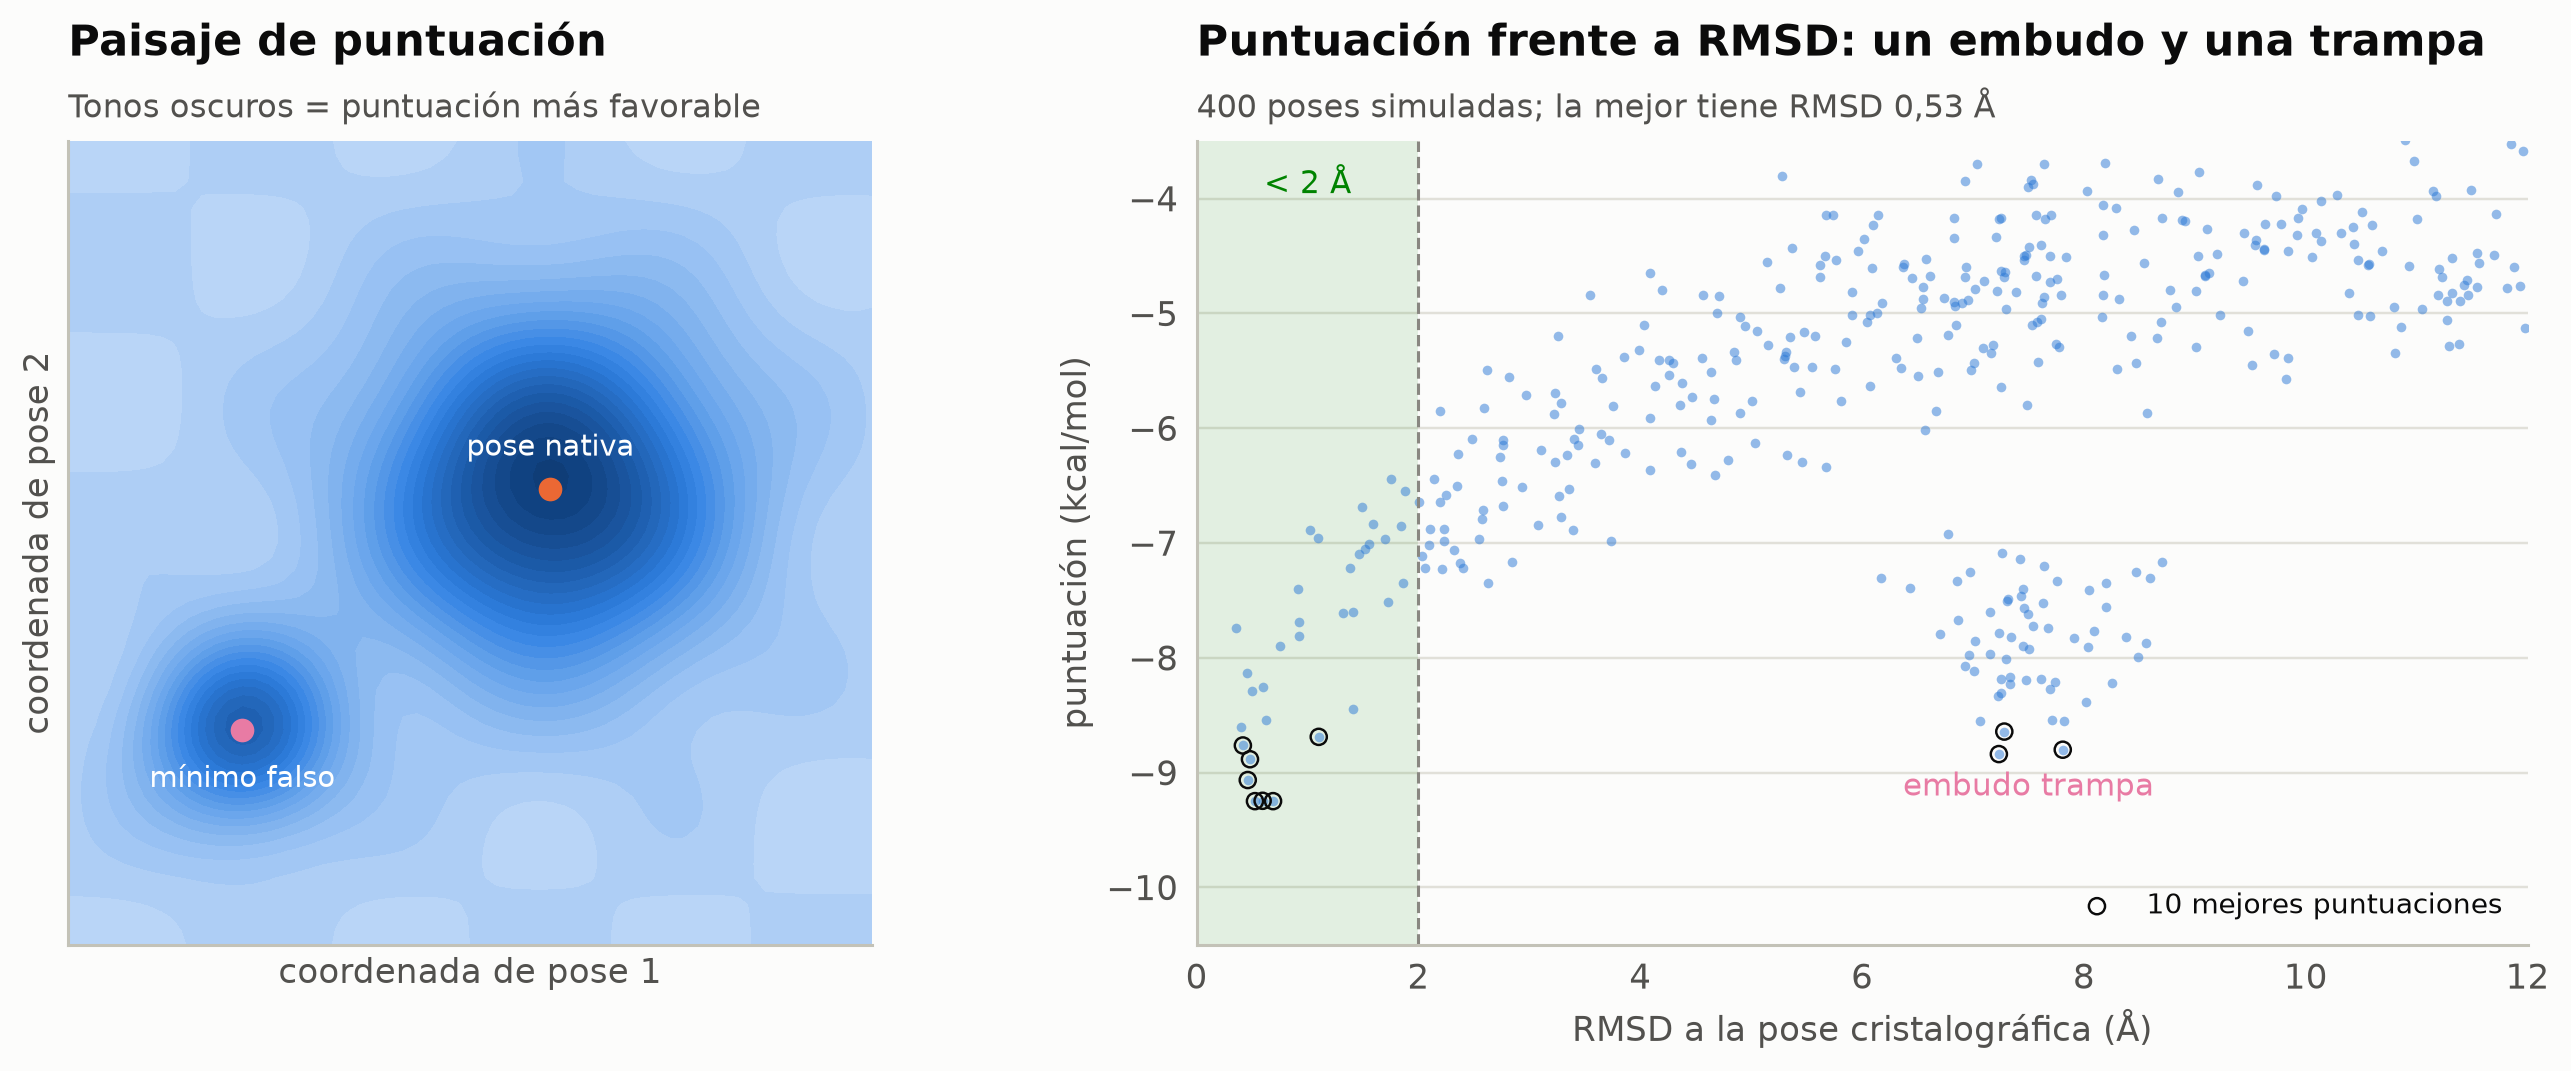

In [26]:
book_poses = pd.read_csv(io.BytesIO(course_bytes("153_libro_poses.tsv")), sep="\t")
top10 = book_poses.nsmallest(10, "score")
print(f"{len(book_poses)} poses · mejor: RMSD = {top10.rmsd.iloc[0]:.2f} Å, S = {top10.score.iloc[0]:.2f} · "
      f"de las 10 mejores, {int((top10.rmsd < 2).sum())} tienen RMSD < 2 Å")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), gridspec_kw=dict(width_ratios=[1, 1.15]))
ax = axes[0]
ax.contourf(UU, VV, ZZ, levels=24, cmap=ec.CMAP_SEQ.reversed(), vmin=-9.5, vmax=1)
ax.scatter(*NATIVE, s=60, color=ec.ORANGE, edgecolor="white", zorder=5)
ax.text(NATIVE[0], NATIVE[1] + 0.2, "pose nativa", color="white", ha="center", va="bottom", fontsize=9.5)
ax.scatter(*FALSE_MIN, s=60, color=ec.MAGENTA, edgecolor="white", zorder=5)
ax.text(FALSE_MIN[0], FALSE_MIN[1] - 0.25, "mínimo falso", color="white", ha="center", va="top", fontsize=9.5)
ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
ax.set_xlabel("coordenada de pose 1"); ax.set_ylabel("coordenada de pose 2")
ec.title(ax, "Paisaje de puntuación", "Tonos oscuros = puntuación más favorable")
ax = axes[1]
ax.axvspan(0, 2, color=ec.GREEN, alpha=0.1, lw=0)
ax.scatter(book_poses.rmsd, book_poses.score, s=10, color=ec.BLUE, alpha=0.5, lw=0)
ax.scatter(top10.rmsd, top10.score, s=28, facecolor="none", edgecolor=ec.INK, lw=0.8, label="10 mejores puntuaciones")
ax.axvline(2, color=ec.MUTED, ls="--", lw=1)
ax.text(1.0, -3.7, "< 2 Å", color=ec.GREEN, ha="center", va="top", fontsize=10)
ax.text(7.5, -9.2, "embudo trampa", color=ec.MAGENTA, ha="center", fontsize=10)
ax.set_xlim(0, 12); ax.set_ylim(-10.5, -3.5)
ax.set_xlabel("RMSD a la pose cristalográfica (Å)"); ax.set_ylabel("puntuación (kcal/mol)")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ec.title(ax, "Puntuación frente a RMSD: un embudo y una trampa",
         f"400 poses simuladas; la mejor tiene RMSD {top10.rmsd.iloc[0]:.2f} Å".replace(".", ","))
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** La mayoría de las poses forma un embudo cuyo fondo está a menos de 2 Å (franja verde): la
> mejor pose tiene un RMSD de 0,53 Å y 7 de las 10 mejores son correctas. El grupo en torno a 7,5 Å es un embudo
> trampa: si la función de puntuación lo favoreciera un poco más, el *docking* fallaría con una puntuación excelente.

### El RMSD simétrico

Antes de usar un protocolo de *docking* con compuestos nuevos, se **valida** con un caso de respuesta conocida: el
***redocking***. Se toma una estructura cristalográfica del receptor con su ligando, se extrae el ligando, se
aleatoriza su conformación y se vuelve a acoplar con el protocolo que se quiere evaluar. Después se compara la pose
obtenida con la cristalográfica mediante el RMSD de los átomos pesados, **sin superponer** (ambas están ya en el
sistema de referencia del receptor; superponer con Kabsch, como en la Lección 15.1, borraría precisamente el error que
queremos medir) y teniendo en cuenta la **simetría** del ligando (un anillo de benceno girado 180° es la misma pose):

$$\mathrm{RMSD}_{\mathrm{sim}}=\min_{\pi\in\mathrm{Aut}(G)}\sqrt{\frac1{N}\sum_{k=1}^{N}\big\lVert\mathbf p_k-\mathbf q_{\pi(k)}\big\rVert^2}.$$

| Símbolo | Significado |
|---|---|
| $\mathbf p_k,\ \mathbf q_k$ | Posiciones del átomo pesado $k$ del ligando en la pose predicha y en la cristalográfica |
| $\mathrm{Aut}(G)$ | Automorfismos del grafo molecular: permutaciones de átomos que dejan la molécula invariante |
| $N$ | Número de átomos pesados del ligando (37 para el imatinib) |

**Ejemplo a mano.** Un anillo de fenilo *para*-sustituido que gira 180° sobre su eje intercambia sus dos pares de
carbonos *orto* y *meta*. Si esos 4 átomos están a 2,4 Å de "su" átomo homónimo del cristal pero a 0,2 Å del
simétrico, el RMSD ingenuo cuenta $4\times2{,}4^2=23$ Å² de error inexistente; en una molécula de 37 átomos eso sube el
RMSD en $\sqrt{23/37}\approx0{,}8$ Å. El imatinib tiene dos anillos simétricos (el benceno *para*-sustituido de la benzamida
y la piperazina), así que su grafo tiene $2\times2=4$ automorfismos, que calculamos una vez con RDKit y están en el
archivo de datos.

El criterio convencional: una pose es **correcta** si $\mathrm{RMSD}_{\mathrm{sim}}<2$ Å. Se informan dos tasas: la
de éxito ***top-1*** (la pose mejor puntuada es correcta) y la de éxito ***top-N*** (alguna de las $N$ mejores lo es);
la diferencia entre ambas separa los fallos de puntuación de los de búsqueda. **Si la pose correcta nunca aparece
entre las generadas, falló la búsqueda; si aparece pero no en primer lugar, falló la puntuación.**

In [27]:
AUTOS = [np.array(a) for a in VINA["automorphisms"]]
print(f"El grafo del imatinib tiene {len(AUTOS)} automorfismos (incluida la identidad)")

def rmsd_sym(P, Q, autos=AUTOS):
    """RMSD simétrico sin superposición: mínimo sobre las permutaciones que dejan la molécula invariante."""
    return min(float(np.sqrt(((P - Q[a]) ** 2).sum(1).mean())) for a in autos)

# comprobación: una pose del cristal con los átomos permutados por un automorfismo tiene RMSD_sim = 0
perm = next(a for a in AUTOS if (a != np.arange(len(a))).any())
print(f"cristal vs cristal permutado: RMSD ingenuo = {rmsd_plain(XL[perm], XL):.2f} Å · RMSD_sim = "
      f"{rmsd_sym(XL[perm], XL):.2f} Å")

pre_xyz = [np.array(p) for p in VINA["poses_xyz"]]      # Vina, exhaustiveness 32, semilla 42
pre_E = np.array(VINA["best_energies"])[:, 0]
poses_df = pd.DataFrame(dict(pose=np.arange(1, len(pre_xyz) + 1), energía=pre_E,
                             rmsd_sim=[rmsd_sym(P, XL) for P in pre_xyz]))
poses_df["correcta"] = np.where(poses_df.rmsd_sim < 2, "sí", "no")
print("\nRedocking precalculado (Vina 1.2.7, exhaustiveness = 32, semilla 42):")
display(poses_df.round(2))
if live is not None:
    live_df = pd.DataFrame(dict(pose=np.arange(1, len(live["E"]) + 1), energía=live["E"],
                                rmsd_sim=[rmsd_sym(P, XL) for P in live["xyz"]]))
    print(f"Redocking en vivo (exhaustiveness = {EXH}, semilla {SEED_LIVE}):")
    display(live_df.round(2))

El grafo del imatinib tiene 4 automorfismos (incluida la identidad)
cristal vs cristal permutado: RMSD ingenuo = 0.82 Å · RMSD_sim = 0.00 Å

Redocking precalculado (Vina 1.2.7, exhaustiveness = 32, semilla 42):


,pose,energía,rmsd_sim,correcta
0,1,-12.76,0.52,sí
1,2,-10.98,12.04,no
2,3,-10.94,12.41,no
3,4,-10.88,12.15,no
4,5,-10.32,12.24,no
5,6,-10.09,13.27,no
6,7,-10.04,12.16,no


Redocking en vivo (exhaustiveness = 8, semilla 4):


,pose,energía,rmsd_sim
0,1,-12.77,0.39
1,2,-11.02,12.01
2,3,-10.96,12.41
3,4,-10.03,12.28


La tabla del *redocking* precalculado cuenta la historia completa: la **pose 1** coincide con la cristalográfica
(RMSD de medio ångström, dentro de la resolución de la propia estructura) y su energía, alrededor de −12,8 kcal/mol,
es la mejor; la **pose 2** tiene un RMSD de unos 12 Å: es el imatinib **al revés**: la piperazina apunta hacia el fondo
del bolsillo (a unos 4 Å de donde el cristal pone la piridina) y los extremos quedan intercambiados. Esa pose invertida es el embudo trampa **real** de este sistema, y queda unas 1,7 kcal/mol
por encima: la función de Vina la distingue bien.

¿Es robusto el resultado? El *redocking* se repitió con varias semillas y dos valores de `exhaustiveness`. Clasifiquemos
cada ejecución con la regla de oro: *búsqueda* frente a *puntuación*.

In [28]:
def diagnose(rmsds):
    if rmsds[0] < 2:
        return "éxito top-1"
    return "fallo de puntuación" if min(rmsds) < 2 else "fallo de búsqueda"

runs = pd.DataFrame([dict(exhaustiveness=r["exh"], semilla=r["seed"], segundos=round(r["seconds"]),
                          **{"E top-1": r["energies"][0], "RMSD top-1": r["rmsd"][0],
                             "mejor RMSD entre las poses": min(r["rmsd"]), "poses": len(r["rmsd"]),
                             "diagnóstico": diagnose(r["rmsd"])}) for r in VINA["runs"]])
display(runs.round(2))
for exh_, g in runs.groupby("exhaustiveness"):
    print(f"exhaustiveness = {exh_:2d}: éxito top-1 en {int((g['RMSD top-1'] < 2).sum())}/{len(g)} ejecuciones "
          f"· tiempo medio {g.segundos.mean():.0f} s (1 núcleo)")

,exhaustiveness,semilla,segundos,E top-1,RMSD top-1,mejor RMSD entre las poses,poses,diagnóstico
0,1,1,4,-11.15,12.15,12.15,2,fallo de búsqueda
1,1,2,6,-9.10,6.51,4.18,2,fallo de búsqueda
2,1,3,4,-12.75,0.48,0.48,1,éxito top-1
3,1,4,5,-12.85,0.35,0.35,2,éxito top-1
4,1,5,5,-12.70,0.36,0.36,2,éxito top-1
5,8,1,35,-10.84,12.39,6.52,7,fallo de búsqueda
6,8,2,56,-10.83,12.39,4.18,9,fallo de búsqueda
7,8,3,45,-12.75,0.48,0.48,5,éxito top-1
8,8,4,51,-12.83,0.49,0.49,4,éxito top-1
9,8,5,68,-12.74,0.52,0.52,3,éxito top-1


exhaustiveness =  1: éxito top-1 en 3/5 ejecuciones · tiempo medio 5 s (1 núcleo)
exhaustiveness =  8: éxito top-1 en 3/5 ejecuciones · tiempo medio 51 s (1 núcleo)
exhaustiveness = 32: éxito top-1 en 1/1 ejecuciones · tiempo medio 178 s (1 núcleo)


> 🔎 **Qué observamos.** Todos los fallos son **de búsqueda**: en esas ejecuciones ninguna de las poses generadas está
> a menos de 2 Å, y su mejor energía es claramente peor que la de la pose correcta (≈ −12,8 kcal/mol) que otras
> semillas sí encontraron. Con `exhaustiveness = 8`, los dos fallos se quedan en la pose invertida (≈ −10,8 kcal/mol,
> RMSD ≈ 12 Å); con `exhaustiveness = 1` son más variados: la semilla 1 también acaba en la invertida (−11,15 kcal/mol),
> y la semilla 2, en una pose intermedia aún peor (−9,10 kcal/mol a 6,5 Å), ni correcta ni invertida. La función de puntuación no se equivoca en este sistema; las
> cadenas de Monte Carlo, a veces, no llegan. Por eso la comprobación 3 del final pide repetir con otras semillas y
> otra `exhaustiveness`: con `exhaustiveness = 1`, el resultado depende de la suerte; con 8, falló 2 de 5 veces con un
> solo núcleo; con 32, acertó. Más cadenas cuestan más tiempo, pero compran fiabilidad.

La figura interactiva siguiente coloca las poses en el bolsillo: la cristalográfica (violeta), la pose 1 de Vina
(verde), la pose invertida (rojo) y la mejor de nuestra búsqueda rígida (naranja). Active y desactive capas en la
leyenda.

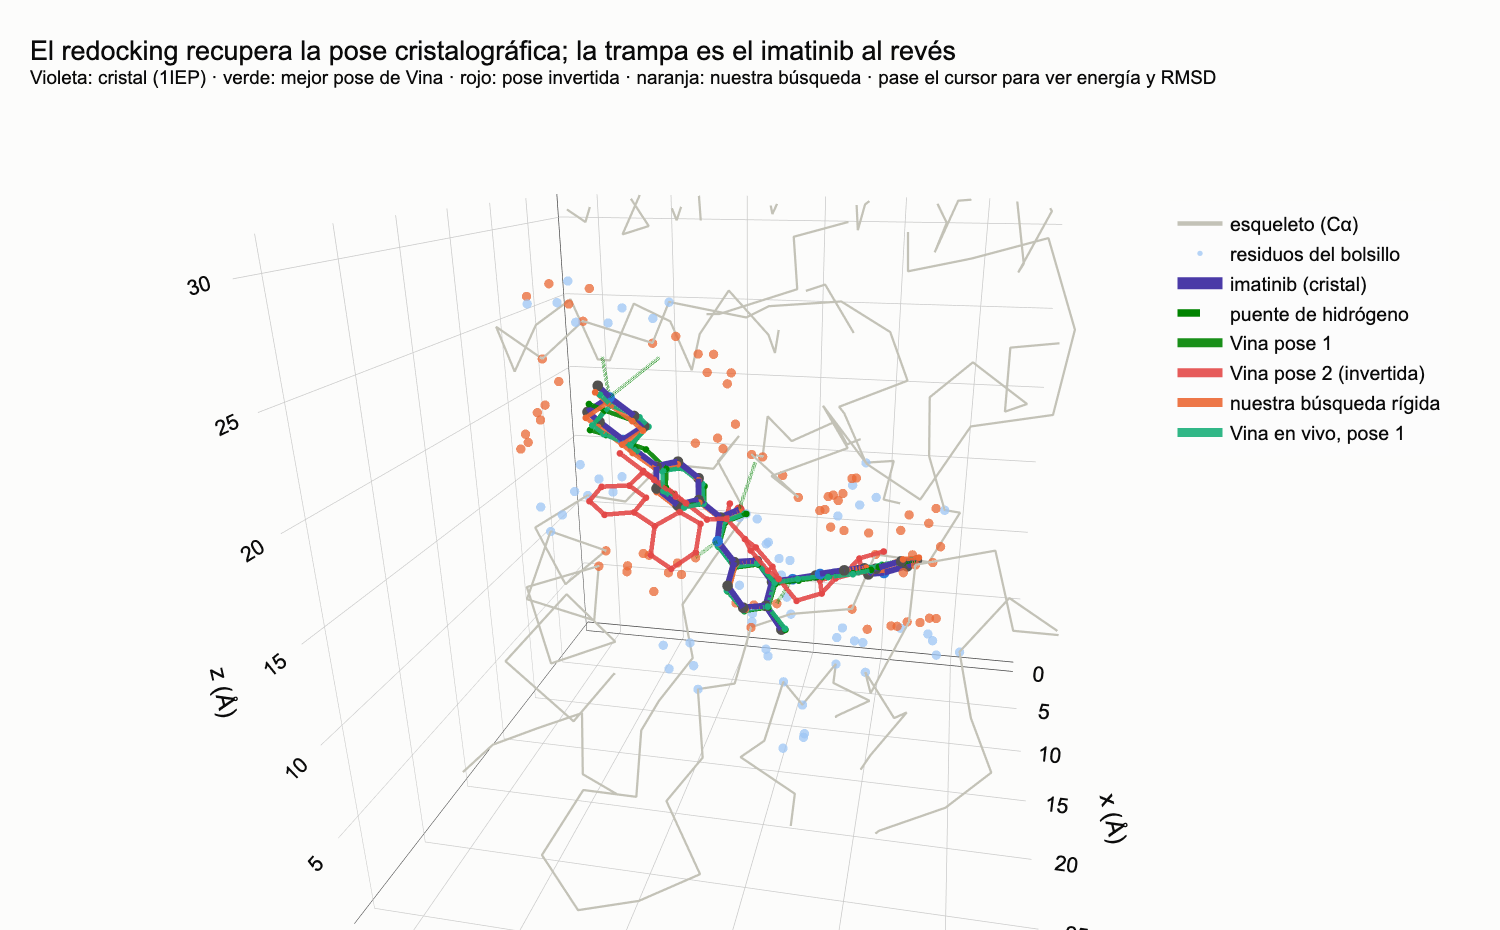

In [29]:
extra = []
show = [(pre_xyz[0], f"Vina pose 1 · {pre_E[0]:.2f} kcal/mol · RMSD {rmsd_sym(pre_xyz[0], XL):.2f} Å", ec.GREEN)]
k_flip = int(np.argmax([rmsd_sym(P, XL) > 8 for P in pre_xyz]))
show.append((pre_xyz[k_flip], f"Vina pose {k_flip + 1} (invertida) · {pre_E[k_flip]:.2f} kcal/mol · "
             f"RMSD {rmsd_sym(pre_xyz[k_flip], XL):.1f} Å", ec.RED))
show.append((my_best_xyz, f"nuestra búsqueda rígida · RMSD {rmsd_plain(my_best_xyz, XL):.2f} Å", ec.ORANGE))
if live is not None:
    show.append((live["xyz"][0], f"Vina en vivo, pose 1 · {live['E'][0]:.2f} kcal/mol · "
                 f"RMSD {rmsd_sym(live['xyz'][0], XL):.2f} Å", ec.AQUA))
for P, name, c in show:
    extra.append(stick_trace(P, LIG_BONDS, c, name.split(" · ")[0], width=6, opacity=0.9))
    extra.append(go.Scatter3d(x=P[:, 0], y=P[:, 1], z=P[:, 2], mode="markers", marker=dict(size=2.5, color=c),
                              showlegend=False, text=[f"{name}<br>átomo {a}" for a in lig.atom],
                              hovertemplate="%{text}<extra></extra>"))
pocket_figure(extra, title="El redocking recupera la pose cristalográfica; la trampa es el imatinib al revés"
              "<br><sup>Violeta: cristal (1IEP) · verde: mejor pose de Vina · rojo: pose invertida · "
              "naranja: nuestra búsqueda · pase el cursor para ver energía y RMSD</sup>", legend_right=True).show()

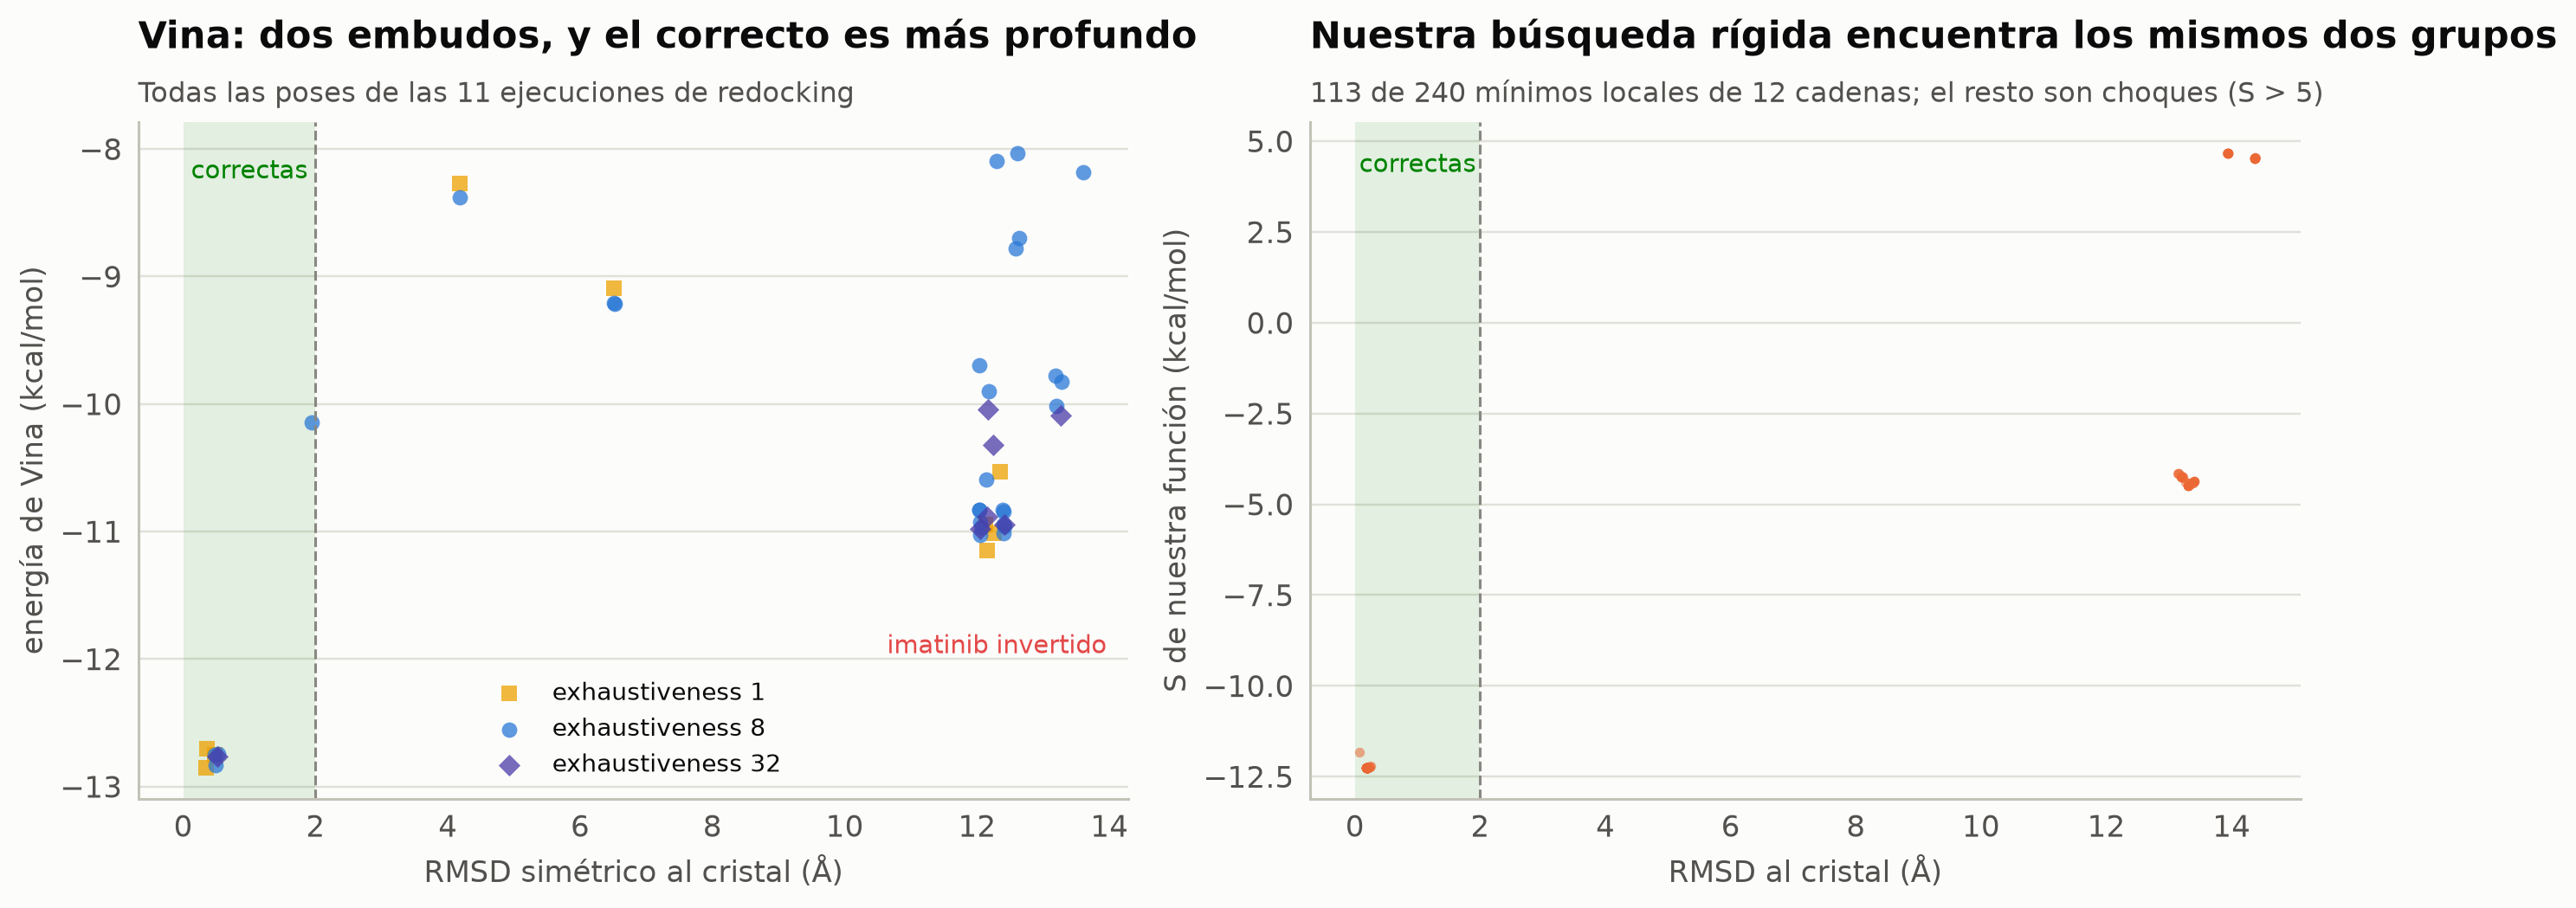

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.9), sharey=False)
ax = axes[0]
allp = pd.DataFrame([(r["exh"], e, x) for r in VINA["runs"] for e, x in zip(r["energies"], r["rmsd"])],
                    columns=["exh", "E", "rmsd"])
ax.axvspan(0, 2, color=ec.GREEN, alpha=0.1, lw=0)
for exh_, c, m in ((1, ec.YELLOW, "s"), (8, ec.BLUE, "o"), (32, ec.VIOLET, "D")):
    g = allp[allp.exh == exh_]
    ax.scatter(g.rmsd, g.E, s=34, color=c, marker=m, alpha=0.75, label=f"exhaustiveness {exh_}", lw=0)
ax.axvline(2, color=ec.MUTED, ls="--", lw=1)
ax.set_xlabel("RMSD simétrico al cristal (Å)"); ax.set_ylabel("energía de Vina (kcal/mol)")
ax.legend(frameon=False, fontsize=9, loc="lower center")
ax.text(1.0, allp.E.max() - 0.05, "correctas", color=ec.GREEN, ha="center", va="top", fontsize=9.5)
ax.text(12.3, allp.E.min() + 0.9, "imatinib invertido", color=ec.RED, ha="center", fontsize=9.5)
ec.title(ax, "Vina: dos embudos, y el correcto es más profundo", "Todas las poses de las 11 ejecuciones de redocking")
ax = axes[1]
mm = my_minima[my_minima.S < 5]
ax.axvspan(0, 2, color=ec.GREEN, alpha=0.1, lw=0)
ax.scatter(mm.rmsd, mm.S, s=14, color=ec.ORANGE, alpha=0.55, lw=0)
ax.axvline(2, color=ec.MUTED, ls="--", lw=1)
ax.set_xlabel("RMSD al cristal (Å)"); ax.set_ylabel("S de nuestra función (kcal/mol)")
ax.text(1.0, mm.S.max(), "correctas", color=ec.GREEN, ha="center", va="top", fontsize=9.5)
ec.title(ax, "Nuestra búsqueda rígida encuentra los mismos dos grupos",
         f"{len(mm)} de {len(my_minima)} mínimos locales de 12 cadenas; el resto son choques (S > 5)")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Dos datos independientes (Vina completo, flexible, y nuestra búsqueda rígida con nuestra
> propia función) dibujan el mismo paisaje: un grupo en RMSD < 2 Å con las mejores puntuaciones y un segundo grupo
> a unos 12–14 Å (el imatinib invertido y orientaciones vecinas), más arriba. Es la versión real de la figura del
> libro, con un embudo trampa que la función de puntuación, por suerte, no prefiere. Note además cuántos mínimos de
> nuestra búsqueda rígida son choques: un ligando rígido de 20 Å casi nunca cabe en el bolsillo si su orientación no
> es casi la correcta, y eso hace la búsqueda difícil.

> ✅ **Compruebe su comprensión.** Un colega hace *redocking* de su ligando y obtiene: pose 1 con RMSD 6,3 Å
> (−9,1 kcal/mol) y pose 3 con RMSD 1,1 Å (−8,7 kcal/mol). ¿Fallo de búsqueda o de puntuación? ¿Serviría subir la
> `exhaustiveness`? (Respuesta: de puntuación; más búsqueda no arregla una función que prefiere la pose equivocada.)

## 11. 🧪 Resistencia: la mutación T315I

En 2001, pocos meses después de la aprobación del imatinib, Gorre y colaboradores secuenciaron el dominio quinasa de
BCR-ABL en pacientes que habían recaído y encontraron una sustitución recurrente: la **treonina 315 por isoleucina**.
T315 es el **portero** (*gatekeeper*): su cadena lateral está al fondo del bolsillo, y en 1IEP su hidroxilo forma un
puente de hidrógeno de 2,88 Å con la amina central del imatinib (sección 3). La isoleucina tiene casi el mismo tamaño
pero **no tiene hidroxilo** (no puede formar ese puente) y es **más voluminosa** (un metilo más, que invade el espacio
del ligando). T315I resiste a imatinib, nilotinib y dasatinib; el primer inhibidor aprobado contra ella fue el
**ponatinib**, diseñado con un enlace alquino rígido que pasa junto al portero sin tocarlo (O'Hare *et al.*, 2009).

¿Puede el *docking* "ver" esta resistencia? Hagamos el experimento desde cero:

1. Construimos la isoleucina sobre el esqueleto de la treonina: CG1 ocupa la dirección de OG1 (a 1,53 Å, la longitud
   de un enlace C–C) y CD1 se coloca con el método NeRF (el mismo que usan los programas de modelado para construir
   cadenas a partir de ángulos, Lección 15.1) con el ángulo diedro $\chi_2$ de un rotámero.
2. Elegimos el rotámero canónico ($\chi_2\in\{-60°, 60°, 180°\}$) que menos choca con el entorno.
3. Volvemos a puntuar la pose cristalográfica con nuestra función, y comparamos con Vina (precalculado).

> 🤔 **Antes de ejecutar, prediga.** ¿Cuánto empeorará la puntuación: menos de 0,5 kcal/mol (el valor del puente de
> hidrógeno que se pierde) o más? ¿Por qué podría ser más?

Distancia mínima de CD1 a su entorno por rotámero: {-60: 2.55, 60: 1.54, 180: 1.66} → elegimos χ2 = -60


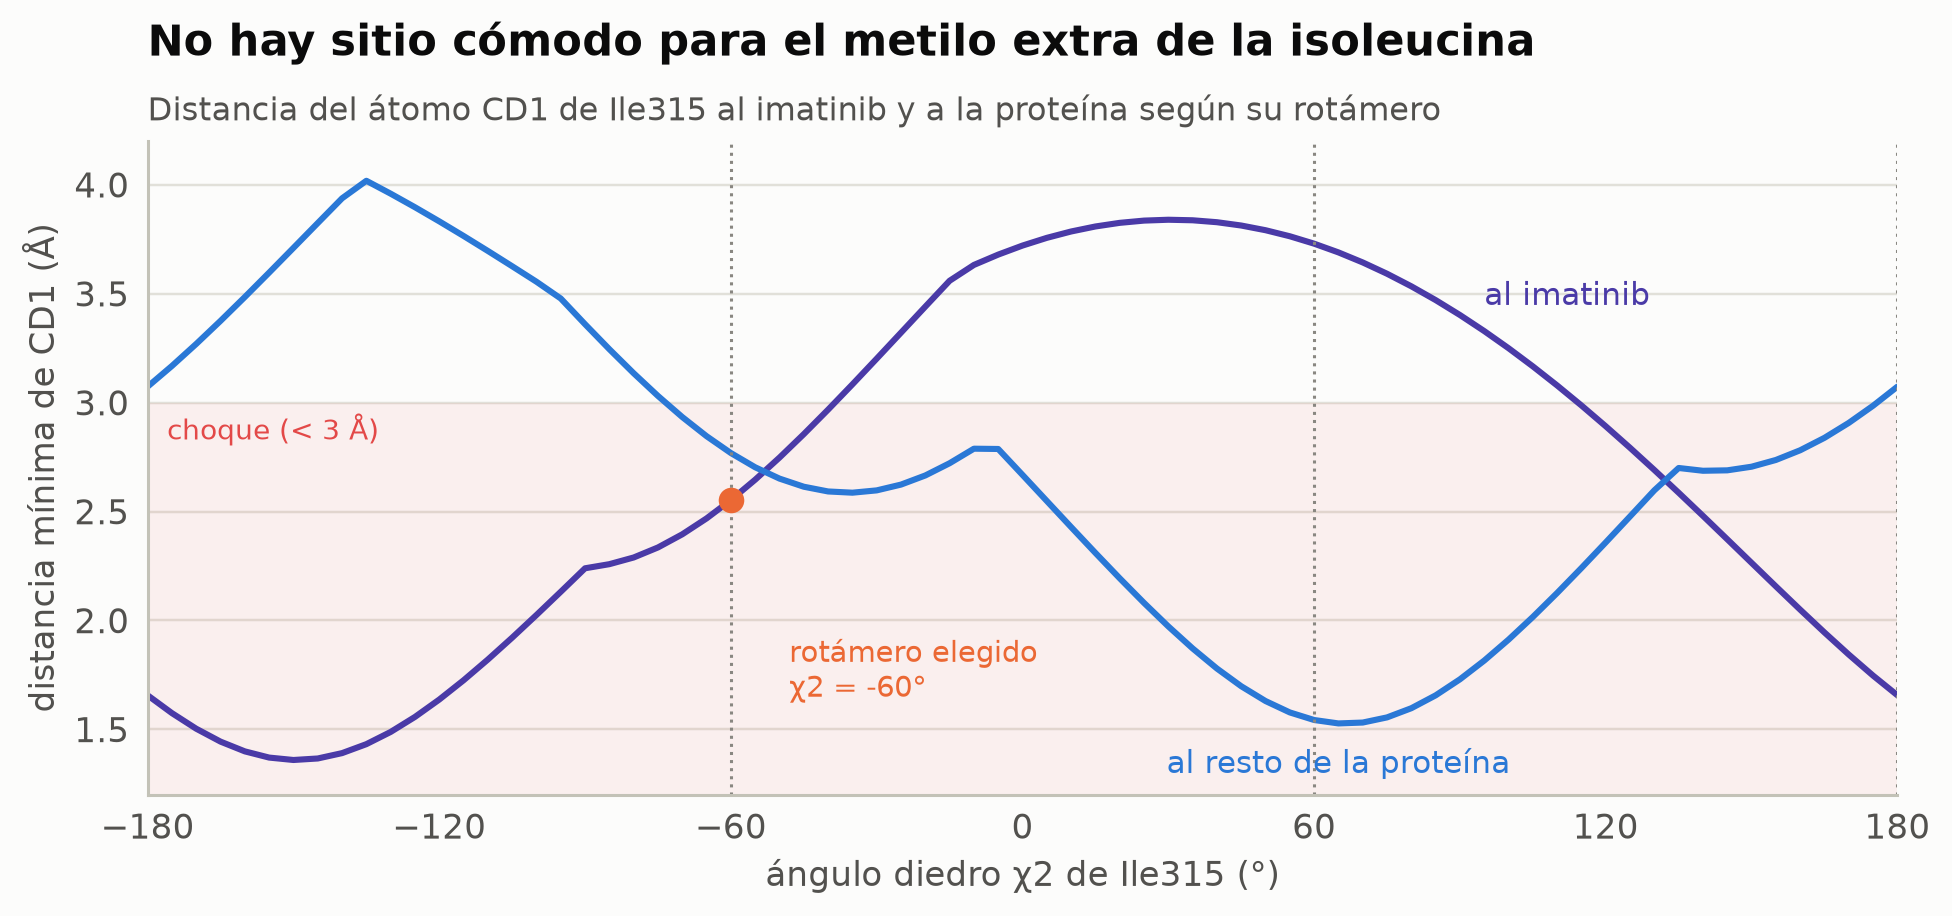

In [31]:
def nerf(a, b, c, bond, angle, torsion):
    """Coloca el átomo d dado a-b-c, la distancia |cd|, el ángulo b-c-d y el diedro a-b-c-d (grados)."""
    angle, torsion = np.radians(angle), np.radians(torsion)
    bc = (c - b) / np.linalg.norm(c - b)
    n = np.cross(b - a, bc); n /= np.linalg.norm(n)
    m = np.cross(n, bc)
    d = np.array([-bond * np.cos(angle), bond * np.sin(angle) * np.cos(torsion), bond * np.sin(angle) * np.sin(torsion)])
    return c + d[0] * bc + d[1] * m + d[2] * n

thr = {a: prot.loc[(prot.resi == 315) & (prot.atom == a), ["x", "y", "z"]].to_numpy()[0] for a in ("CA", "CB", "OG1", "CG2")}
cg1 = thr["CB"] + 1.53 * (thr["OG1"] - thr["CB"]) / np.linalg.norm(thr["OG1"] - thr["CB"])
others = XP[prot.resi.to_numpy() != 315]
chi2 = np.arange(-180, 181, 5)
d_lig, d_prot = [], []
for c2 in chi2:
    cd1 = nerf(thr["CA"], thr["CB"], cg1, 1.53, 113.9, c2)
    d_lig.append(np.linalg.norm(XL - cd1, axis=1).min()); d_prot.append(np.linalg.norm(others - cd1, axis=1).min())
d_lig, d_prot = np.array(d_lig), np.array(d_prot)
canon = {c: min(d_lig[chi2 == c][0], d_prot[chi2 == c][0]) for c in (-60, 60, 180)}
CHI2 = max(canon, key=canon.get)
cd1 = nerf(thr["CA"], thr["CB"], cg1, 1.53, 113.9, CHI2)
print("Distancia mínima de CD1 a su entorno por rotámero:", {k: round(float(v), 2) for k, v in canon.items()},
      "→ elegimos χ2 =", CHI2)

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(chi2, d_lig, color=ec.VIOLET, lw=2); ax.plot(chi2, d_prot, color=ec.BLUE, lw=2)
ax.text(95, d_lig[chi2 == 95][0] + 0.12, "al imatinib", color=ec.VIOLET, fontsize=10)
ax.text(65, 1.3, "al resto de la proteína", color=ec.BLUE, fontsize=10, ha="center")
ax.axhspan(0, 3.0, color=ec.RED, alpha=0.07, lw=0); ax.text(-176, 2.95, "choque (< 3 Å)", color=ec.RED, fontsize=9, va="top")
for c in (-60, 60, 180):
    ax.axvline(c, color=ec.MUTED, ls=":", lw=1)
ax.scatter([CHI2], [canon[CHI2]], s=70, color=ec.ORANGE, zorder=5)
ax.annotate(f"rotámero elegido\nχ2 = {CHI2}°", (CHI2, canon[CHI2]), xytext=(CHI2 + 12, 1.65), fontsize=9.5,
            color=ec.ORANGE, arrowprops=dict(arrowstyle="-", color=ec.ORANGE))
ax.set_xlim(-180, 180); ax.set_ylim(1.2, 4.2); ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax.set_xlabel("ángulo diedro χ2 de Ile315 (°)"); ax.set_ylabel("distancia mínima de CD1 (Å)")
ec.title(ax, "No hay sitio cómodo para el metilo extra de la isoleucina",
         "Distancia del átomo CD1 de Ile315 al imatinib y a la proteína según su rotámero")
plt.tight_layout(); plt.show()

In [32]:
# receptor mutante: quitamos OG1 (y su H) de Thr315 y añadimos CG1 y CD1 de Ile (carbonos hidrofóbicos)
is315 = rec.resi.to_numpy() == 315
mut = rec[~(is315 & rec.atom.isin(["OG1"]).to_numpy())].copy()
mut.loc[(mut.resi == 315) & (mut.atom == "CB"), "xs"] = "C_H"          # CB ya no está unido a un oxígeno
mut.loc[(mut.resi == 315), "resn"] = "ILE"
add = pd.DataFrame([dict(atom=a, resn="ILE", resi=315, x=p[0], y=p[1], z=p[2], ad="C", xs="C_H", element="C")
                    for a, p in (("CG1", cg1), ("CD1", cd1))])
mut = pd.concat([mut, add], ignore_index=True)
scorer_mut = VinaLikeScorer(mut[["x", "y", "z"]].to_numpy(), mut["xs"], ligq["xs"], N_ROT)

T_wt = {k: float((W[k] * v).sum()) for k, v in scorer.terms(XL).items()}
T_mut = {k: float((W[k] * v).sum()) for k, v in scorer_mut.terms(XL).items()}
cmp = pd.DataFrame({"silvestre (T315)": T_wt, "mutante (I315)": T_mut})
cmp.loc["suma"] = cmp.sum()
cmp.loc["S (÷ 1,41)"] = cmp.loc["suma"] / (1 + W_ROT * N_ROT)
cmp["diferencia"] = cmp["mutante (I315)"] - cmp["silvestre (T315)"]
display(cmp.round(2))
dS = cmp.loc["S (÷ 1,41)", "diferencia"]
tv = VINA["t315i"]
print(f"Nuestra función: ΔS = {dS:+.2f} kcal/mol → la K_d empeora ~{np.exp(dS / RT):.0f} veces")
print(f"Vina (precalculado): pose cristalográfica {tv['wt']['score']:.2f} → {tv['T315I']['score']:.2f} kcal/mol; "
      f"tras minimización local {tv['wt']['optimized']:.2f} → {tv['T315I']['optimized']:.2f}; "
      f"redocking completo (mejor pose) {tv['wt']['dock_top'][0]:.2f} → {tv['T315I']['dock_top'][0]:.2f}")

,silvestre (T315),mutante (I315),diferencia
g1,-5.49,-5.61,-0.12
g2,-11.37,-11.42,-0.06
rep,4.86,7.82,2.96
hyd,-2.98,-3.32,-0.34
hb,-2.88,-2.36,0.52
suma,-17.85,-14.90,2.95
"S (÷ 1,41)",-12.67,-10.57,2.10


Nuestra función: ΔS = +2.10 kcal/mol → la K_d empeora ~34 veces
Vina (precalculado): pose cristalográfica -12.51 → -10.42 kcal/mol; tras minimización local -13.21 → -11.65; redocking completo (mejor pose) -12.83 → -12.49


> 🔎 **Qué observamos.** Con el receptor rígido y la pose cristalográfica, la puntuación empeora bastante más que el
> valor del puente de hidrógeno perdido: la mayor parte del daño es la **repulsión** del metilo nuevo, que choca con el
> imatinib en cualquier rotámero razonable. Vina coincide en la dirección y el orden de magnitud. Pero fíjese en las
> otras dos cifras de Vina: si se permite al ligando **reacomodarse** (minimización local o *redocking* completo), la
> penalización se reduce mucho, porque el imatinib se aparta unas décimas de ångström.
>
> ¿Significa eso que el *docking* "no ve" la resistencia? Significa que ve **una parte**. En la realidad, T315I tiene
> además un efecto que ningún *docking* de receptor rígido puede capturar: la isoleucina estabiliza la conformación
> **activa** de la quinasa (DFG-adentro), a la que el imatinib no se une (Azam *et al.*, 2008). La resistencia clínica
> es la suma de un choque local y de un cambio en el equilibrio conformacional de toda la proteína. Una sola estructura
> rígida y una función de puntuación rápida no pueden cuantificar ese segundo efecto; para eso hacen falta
> simulaciones de dinámica molecular o, mejor, medidas experimentales.

> ✅ **Compruebe su comprensión.** ¿Por qué el ponatinib, con su enlace alquino (lineal y delgado) en el lugar donde el
> imatinib tiene la amina N13, tolera la isoleucina 315?

## 12. Cribado virtual y enriquecimiento

Hasta ahora conocíamos la respuesta. En el uso real del *docking* se acoplan miles o millones de compuestos contra la
diana y se ordenan por puntuación: el **cribado virtual**. Nadie espera que el primero de la lista sea el mejor
fármaco; lo que se pide es que la parte alta de la lista esté **enriquecida** en compuestos activos, para comprar y
ensayar unas decenas en lugar de miles. Como vimos en el ejemplo de la sección 6, las puntuaciones sirven para
**enriquecer** la lista de candidatos, no para predecir cuáles son activos.

**El experimento.** La base **DUD-E** (Mysinger *et al.*, 2012) ofrece, para ABL1, 182 inhibidores activos conocidos y
miles de **señuelos** (*decoys*): moléculas del catálogo ZINC con el mismo peso molecular, la misma lipofilia, el
mismo número de donadores y aceptores y la misma carga que los activos, pero con topología distinta, y que se suponen
inactivas. Tomamos 25 activos (incluidos imatinib, nilotinib, ponatinib, dasatinib y bosutinib) y 225 señuelos al azar,
y los acoplamos contra 1IEP con Vina (`exhaustiveness = 4`, una pose por compuesto; ~20 min en 9 núcleos,
precalculado en `data/153_dude_abl1_screen.tsv`).

**Métricas.** Ordenamos los 250 compuestos de mejor a peor puntuación.

* **Curva ROC** y su área (AUC): la probabilidad de que un activo al azar puntúe mejor que un señuelo al azar
  (0,5 = azar; 1 = perfecto).
* **Factor de enriquecimiento** en el $x\,\%$ superior:
  $$\mathrm{EF}_{x\%}=\frac{n_{\text{act}}(x\%)\,/\,n(x\%)}{N_{\text{act}}\,/\,N},$$
  cuántas veces más activos hay en el $x\,\%$ superior que en la lista completa.

| Símbolo | Significado |
|---|---|
| $n(x\%)$ | Número de compuestos en el $x\,\%$ superior de la lista |
| $n_{\text{act}}(x\%)$ | Activos entre ellos |
| $N,\ N_{\text{act}}$ | Tamaño total de la lista y número total de activos |

**Ejemplo a mano.** Con $N=250$ y $N_{\text{act}}=25$ (10 %), el 10 % superior son 25 compuestos. Si 9 son activos,
$\mathrm{EF}_{10\%}=(9/25)/(25/250)=3{,}6$: la parte alta de la lista tiene 3,6 veces más activos que una selección al
azar. El máximo posible aquí es $1/0{,}1=10$.

In [33]:
scr = pd.read_csv(io.BytesIO(course_bytes("153_dude_abl1_screen.tsv")), sep="\t")
scr = scr.sort_values("score").reset_index(drop=True)
N, N_act = len(scr), int(scr.active.sum())

def roc_auc(scores, labels):
    """AUC = P(activo puntúa mejor que señuelo); puntuaciones más negativas son mejores."""
    a, d = scores[labels == 1], scores[labels == 0]
    return float(((a[:, None] < d[None]).sum() + 0.5 * (a[:, None] == d[None]).sum()) / (len(a) * len(d)))

def enrichment(scores, labels, frac):
    n = max(1, int(round(frac * len(scores))))
    top = np.argsort(scores)[:n]
    return labels[top].sum() / n / (labels.sum() / len(labels))

lab = scr.active.to_numpy()
auc = roc_auc(scr.score.to_numpy(), lab)
print(f"{N} compuestos, {N_act} activos · AUC = {auc:.2f}")
for f in (0.01, 0.05, 0.10):
    print(f"EF {f:.0%}: {enrichment(scr.score.to_numpy(), lab, f):.1f} (máximo posible {min(1 / f, N / N_act):.0f})")
display(scr[scr.name.notna()][["name", "id", "score", "heavy", "torsdof"]].assign(
    **{"puesto (de 250)": lambda d: d.index + 1}).round(2))

250 compuestos, 25 activos · AUC = 0.76
EF 1%: 10.0 (máximo posible 10)
EF 5%: 6.7 (máximo posible 10)
EF 10%: 4.8 (máximo posible 10)


,name,id,score,heavy,torsdof,puesto (de 250)
1,nilotinib,CHEMBL255863,-13.76,39,7,2
5,ponatinib,CHEMBL1171837,-12.42,39,6,6
76,imatinib,CHEMBL941,-9.18,37,7,77
117,dasatinib,CHEMBL1421,-8.63,33,8,118
211,bosutinib,CHEMBL288441,-7.24,36,9,212


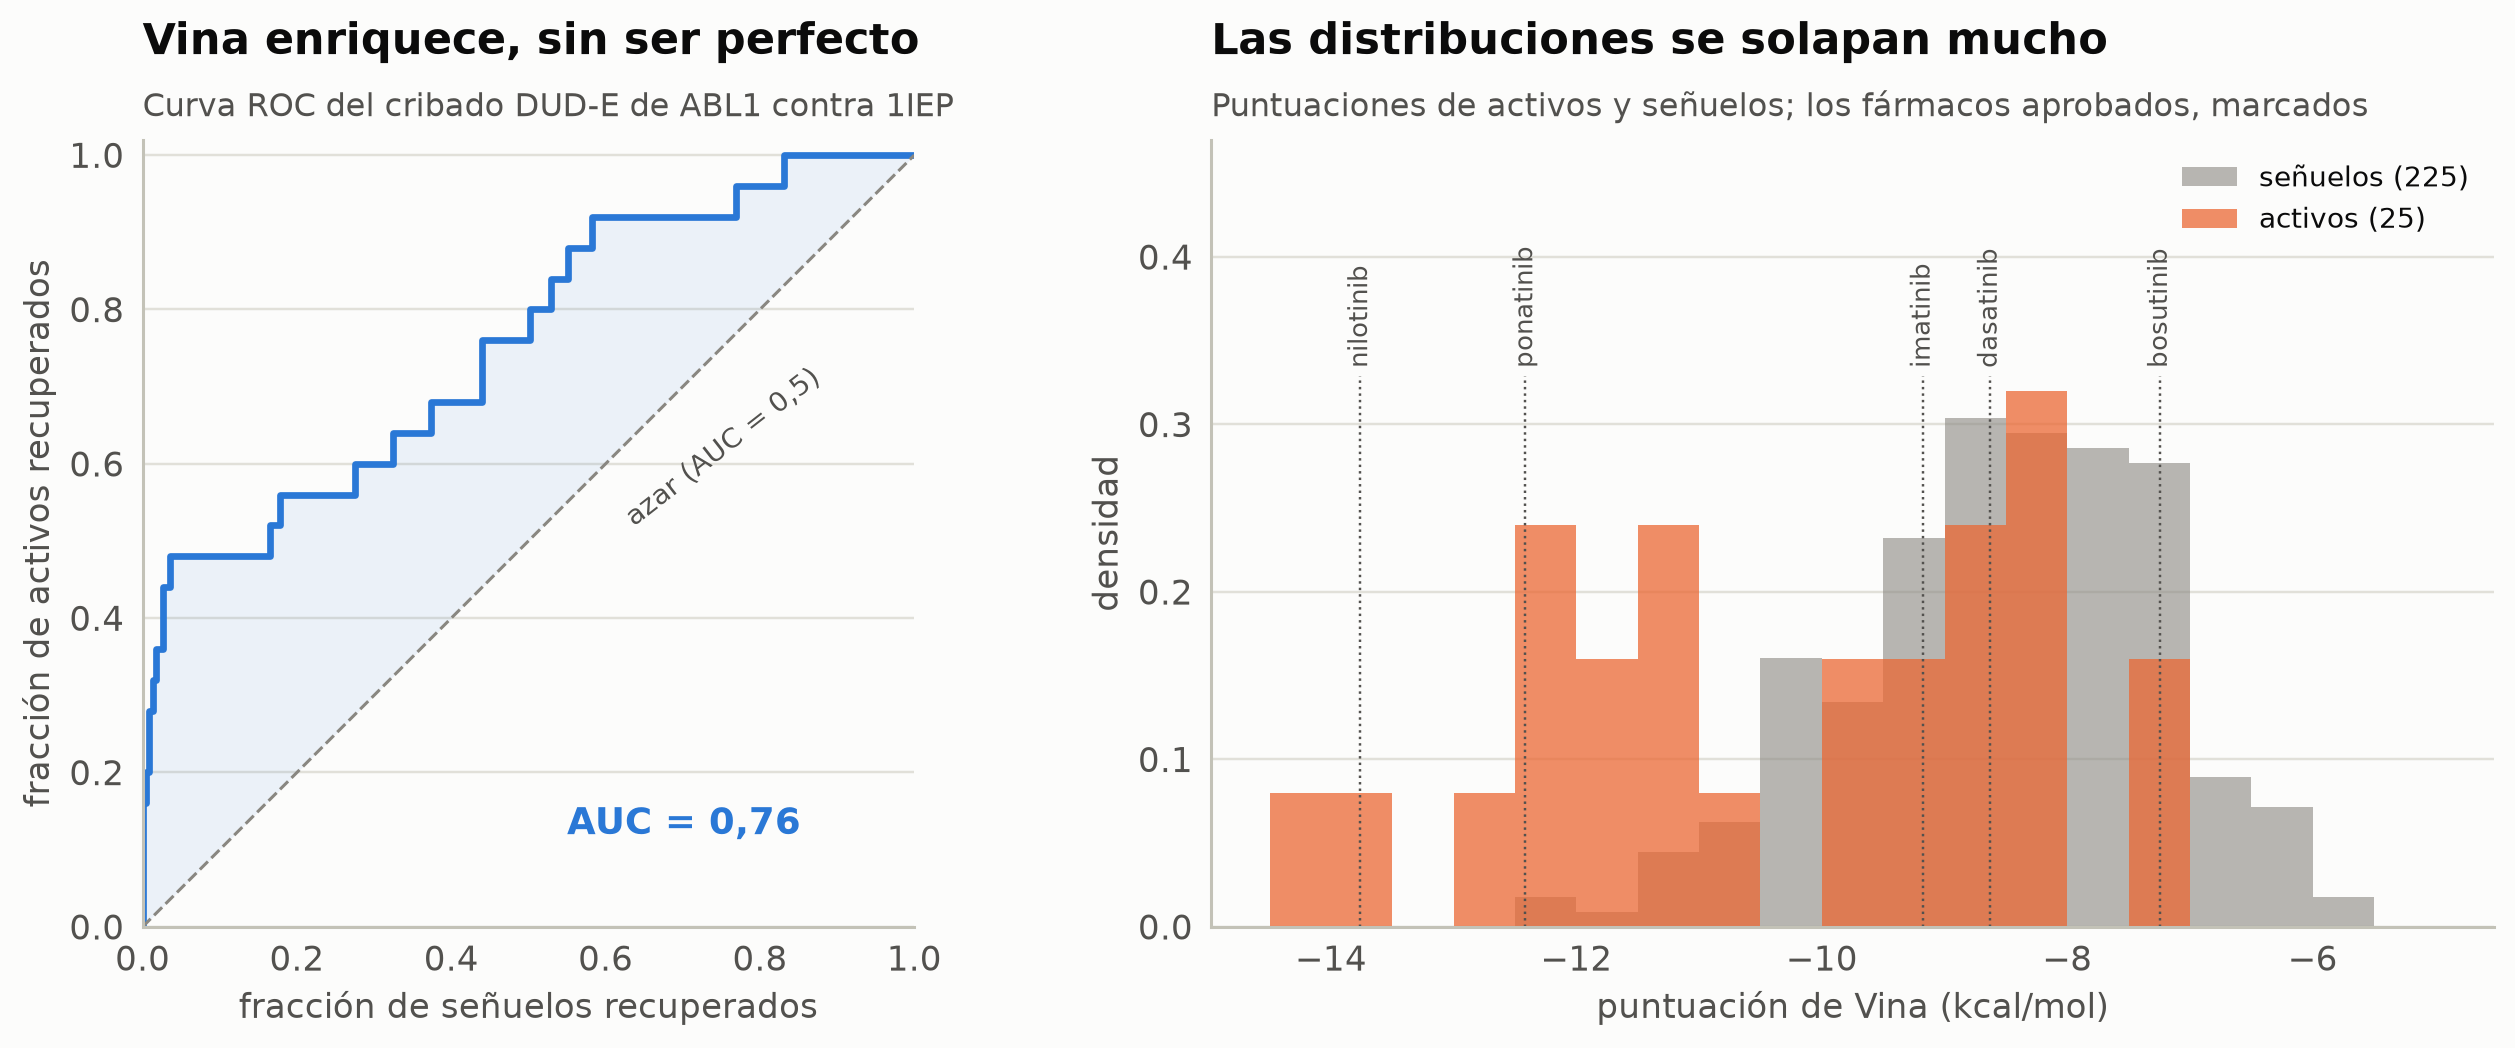

In [34]:
order_ = np.argsort(scr.score.to_numpy())
tpr = np.r_[0, np.cumsum(lab[order_]) / N_act]
fpr = np.r_[0, np.cumsum(1 - lab[order_]) / (N - N_act)]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9), gridspec_kw=dict(width_ratios=[1, 1.2]))
ax = axes[0]
ax.plot(fpr, tpr, color=ec.BLUE, lw=2.2)
ax.plot([0, 1], [0, 1], color=ec.MUTED, ls="--", lw=1); ax.text(0.62, 0.52, "azar (AUC = 0,5)", color=ec.INK_2, fontsize=9, rotation=38)
ax.fill_between(fpr, tpr, fpr, color=ec.BLUE, alpha=0.08)
ax.text(0.55, 0.12, f"AUC = {auc:.2f}".replace(".", ","), color=ec.BLUE, fontsize=12, fontweight="bold")
ax.set_xlabel("fracción de señuelos recuperados"); ax.set_ylabel("fracción de activos recuperados")
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ec.title(ax, "Vina enriquece, sin ser perfecto", "Curva ROC del cribado DUD-E de ABL1 contra 1IEP")
ax = axes[1]
bins = np.arange(-14.5, -4.9, 0.5)
ax.hist(scr.score[lab == 0], bins=bins, color=ec.MUTED, alpha=0.6, label=f"señuelos ({N - N_act})", density=True)
ax.hist(scr.score[lab == 1], bins=bins, color=ec.ORANGE, alpha=0.75, label=f"activos ({N_act})", density=True)
import matplotlib.transforms as mtrans
tr = mtrans.blended_transform_factory(ax.transData, ax.transAxes)
for _, r_ in scr[scr.name.notna()].iterrows():
    ax.axvline(r_.score, ymax=0.7, color=ec.INK_2, lw=0.8, ls=":")
    ax.text(r_.score, 0.71, r_["name"], rotation=90, ha="center", va="bottom", fontsize=8.5, color=ec.INK_2, transform=tr)
ax.set_ylim(0, 0.47)
ax.set_xlabel("puntuación de Vina (kcal/mol)"); ax.set_ylabel("densidad")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ec.title(ax, "Las distribuciones se solapan mucho", "Puntuaciones de activos y señuelos; los fármacos aprobados, marcados")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** El AUC está claramente por encima del azar: la parte alta de la lista está enriquecida en
> activos (nilotinib y ponatinib, inhibidores de tipo II como el imatinib, están entre los primeros puestos). Pero las
> distribuciones se solapan mucho, y hay dos lecciones escondidas en los fármacos marcados:
>
> 1. **Dasatinib y bosutinib**, excelentes inhibidores de ABL, puntúan mal. No es un error de Vina: son inhibidores de
>    **tipo I**, que se unen a la conformación **activa** (DFG-adentro), y 1IEP está en la conformación inactiva. Un
>    receptor rígido solo reconoce a los ligandos de "su" conformación.
> 2. **El propio imatinib** obtiene aquí una puntuación mucho peor que en el *redocking* (−12,8 kcal/mol). Es un fallo
>    de **búsqueda**: con `exhaustiveness = 4` y una sola semilla, como se hace para abaratar un cribado masivo, Vina no
>    encontró su pose. Lo que se ahorra en tiempo de cómputo se paga en compuestos perdidos.

¿Y si el *docking* premiara simplemente a las moléculas grandes? Una molécula con más átomos tiene más contactos y,
por tanto, una suma más negativa, aunque no sea mejor. La figura interactiva lo explora: pase el cursor sobre cada
punto para ver el compuesto.

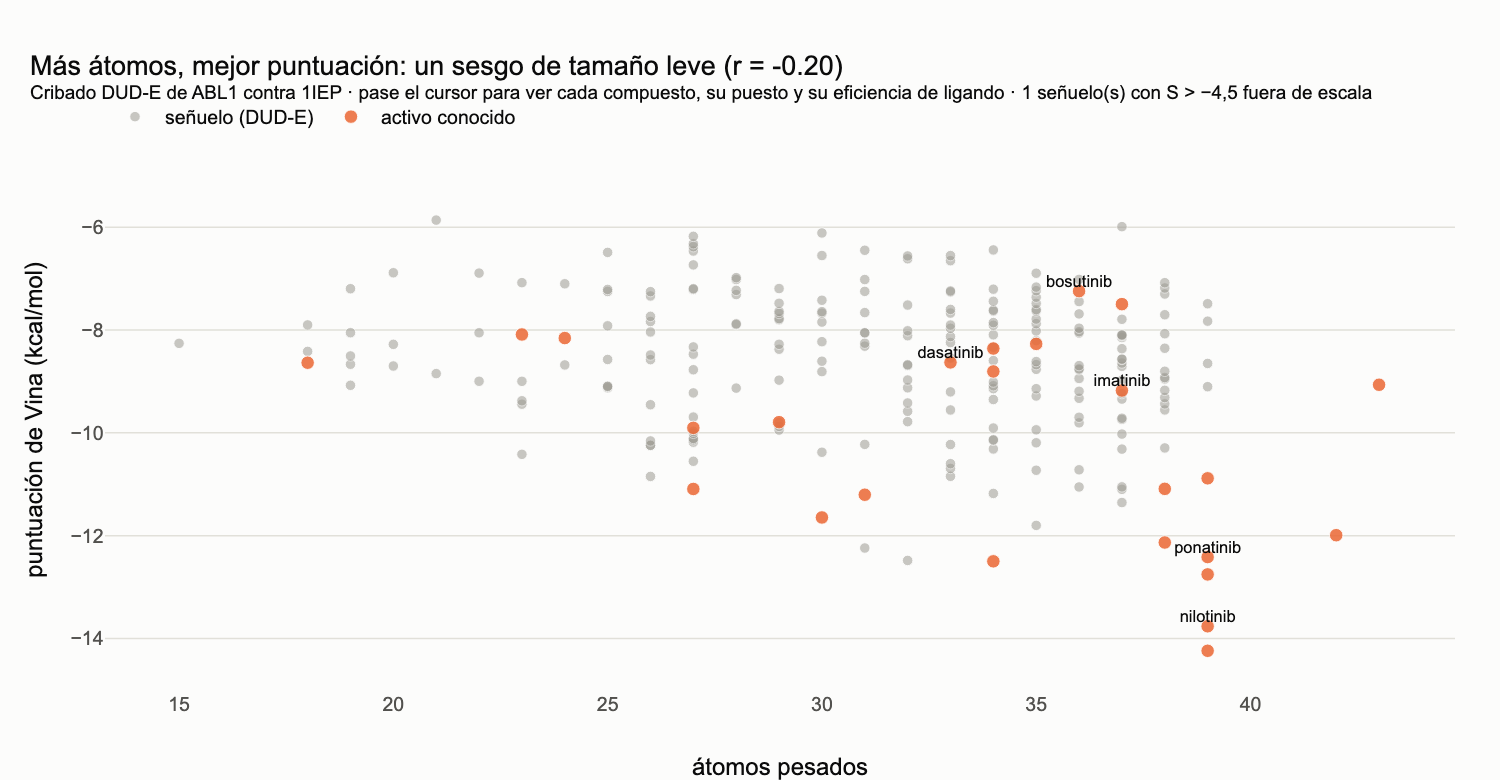

AUC por puntuación = 0.76 · AUC por eficiencia de ligando (−S/N_pesados) = 0.64
Átomos pesados medios: activos 33.8 · señuelos 31.2


In [35]:
scr["LE"] = -scr.score / scr.heavy                       # eficiencia de ligando (kcal/mol por átomo pesado)
r_size = np.corrcoef(scr.heavy, scr.score)[0, 1]
fig = go.Figure()
for a_, name, c in ((0, "señuelo (DUD-E)", "#9d9b93"), (1, "activo conocido", ec.ORANGE)):
    d = scr[scr.active == a_]
    txt = [f"<b>{(n_ if isinstance(n_, str) else i_)}</b><br>{'activo' if a_ else 'señuelo'} · puesto {k + 1} de {N}"
           f"<br>Vina: {s_:.2f} kcal/mol · {h_} átomos pesados · {t_} enlaces rotables"
           f"<br>eficiencia de ligando: {le_:.2f} kcal/mol por átomo"
           for k, n_, i_, s_, h_, t_, le_ in zip(d.index, d.name, d.id, d.score, d.heavy, d.torsdof, d.LE)]
    fig.add_trace(go.Scatter(x=d.heavy, y=d.score, mode="markers", name=name, text=txt,
                             hovertemplate="%{text}<extra></extra>",
                             marker=dict(size=9 if a_ else 7, color=c, opacity=0.85 if a_ else 0.55,
                                         line=dict(width=0.6, color="white"))))
named = scr[scr.name.notna()]
fig.add_trace(go.Scatter(x=named.heavy, y=named.score, mode="text", text=named.name, textposition="top center",
                         showlegend=False, hoverinfo="skip", textfont=dict(size=11, color=ec.INK)))
n_out = int((scr.score > -4.5).sum())
fig.update_yaxes(range=[-15, -4.5])
fig.update_layout(height=520, margin=dict(l=70, r=30, t=100, b=60),
                  title=f"Más átomos, mejor puntuación: un sesgo de tamaño leve (r = {r_size:.2f})"
                        "<br><sup>Cribado DUD-E de ABL1 contra 1IEP · pase el cursor para ver cada compuesto, su "
                        f"puesto y su eficiencia de ligando · {n_out} señuelo(s) con S > −4,5 fuera de escala</sup>",
                  xaxis_title="átomos pesados", yaxis_title="puntuación de Vina (kcal/mol)",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()
auc_le = roc_auc(-scr.LE.to_numpy(), lab)
print(f"AUC por puntuación = {auc:.2f} · AUC por eficiencia de ligando (−S/N_pesados) = {auc_le:.2f}")
print(f"Átomos pesados medios: activos {scr.heavy[lab == 1].mean():.1f} · señuelos {scr.heavy[lab == 0].mean():.1f}")

> 🔎 **Qué observamos.** Las puntuaciones más negativas se concentran a la derecha (moléculas grandes). En DUD-E los
> señuelos se emparejan por peso molecular con los activos precisamente para que ese sesgo no infle el AUC, y aun así
> la correlación entre tamaño y puntuación se ve. Normalizar por tamaño (eficiencia de ligando) cambia el orden de la
> lista, y aquí lo **empeora**: los inhibidores de ABL que mejor puntúan son moléculas grandes de tipo II, cuyo tamaño
> es parte real de su afinidad. Corregir un sesgo puede costar señal verdadera; es una decisión del protocolo, que debe
> probarse con activos conocidos antes de cribar compuestos nuevos (comprobación 4 del final).

> ✅ **Compruebe su comprensión.** Un cribado de 1 millón de compuestos tiene un EF$_{1\%}$ de 8 y se estima que hay
> 100 activos en la colección. ¿Cuántos activos espera entre los 10 000 mejores? (Respuesta: $8\times100\times0{,}01=8$.)

## 13. Limitaciones y aprendizaje profundo

El *docking* clásico es útil pero tiene limitaciones que todo usuario debe conocer; en esta clase hemos tropezado con
casi todas:

* **Receptor rígido.** Las proteínas se ajustan al ligando (*induced fit*); una estructura cristalizada con otro
  ligando, o sin ninguno, puede tener el bolsillo cerrado o con cadenas laterales en posiciones incompatibles. Lo
  vimos dos veces: T315I, cuyo efecto conformacional es invisible para un receptor rígido, y los inhibidores de tipo
  I, que 1IEP (DFG-afuera) no reconoce. Acoplar contra varias conformaciones del receptor (*ensemble docking*) o
  permitir flexibilidad en algunas cadenas laterales mitiga el problema a un coste computacional mayor.
* **Agua y protonación.** Las moléculas de agua que median puentes entre ligando y proteína, y los estados de
  protonación, rara vez se modelan bien. Nosotros elegimos protonar la piperazina del imatinib; con otra elección,
  el puente con Ile360 desaparecería de la función de puntuación.
* **Puntuaciones que no son afinidades.** Como vimos en el ejemplo de la sección 6, el error en afinidad es del orden
  de 2 kcal/mol. En cribado virtual, las puntuaciones sirven para **enriquecer** la lista de candidatos, no para
  predecir cuáles son activos.
* **Modelos predichos.** Acoplar contra un modelo de AlphaFold (Lección 15.2) es posible, pero las cadenas laterales
  del bolsillo, incluso con pLDDT alto, pueden no estar en la conformación de unión; la exactitud suele caer respecto
  a las estructuras experimentales cocristalizadas.

**El aprendizaje profundo** también ha llegado al *docking*. Corso y colaboradores replantearon el problema como uno
de **modelado generativo**: en lugar de buscar el mínimo de una función de puntuación, **DiffDock** aprende a generar
poses mediante un proceso de difusión sobre las traslaciones, rotaciones y torsiones del ligando (¡las mismas
$6+N_{\mathrm{rot}}$ coordenadas de la sección 2!), y un modelo de confianza ordena las poses generadas. En su
evaluación sobre complejos de PDBBind obtuvo una tasa de éxito *top-1* (RMSD < 2 Å) del 38 %, frente al 23 % de los
mejores métodos de búsqueda tradicionales, sin necesidad de indicar el bolsillo. **AlphaFold3** va más allá y predice
de una vez la estructura de la proteína con su ligando (Abramson *et al.*, 2024). Estos métodos no han jubilado a
Vina: son más lentos por compuesto, pueden producir geometrías químicamente imposibles y su rendimiento cae en
proteínas muy diferentes de las de entrenamiento. En la práctica actual, ambos enfoques se combinan.

> ⚠️ **Cinco comprobaciones antes de creer un resultado de docking**
>
> 1. ¿Se validó el protocolo por *redocking* en la misma diana, con RMSD < 2 Å? *(Sección 10: sí, 0,5 Å.)*
> 2. ¿Es razonable la química de la pose (puentes de hidrógeno con geometría correcta, grupos polares no enterrados
>    sin pareja)? *(Sección 3: seis puentes de hidrógeno a 2,7–3,2 Å.)*
> 3. ¿Son robustas las mejores poses frente a cambios en la semilla aleatoria, la `exhaustiveness` y el tamaño de la
>    caja? *(Sección 10: con `exhaustiveness` baja, no.)*
> 4. ¿Se comparó la puntuación con la de ligandos conocidos y con la de señuelos (*decoys*) de propiedades similares?
>    *(Sección 12: AUC por encima del azar, con solapamiento grande.)*
> 5. ¿Hay evidencia experimental independiente (mutagénesis, relación estructura-actividad) que apoye la pose?
>    *(Sección 11: la resistencia por T315I confirma que el portero importa.)*

> 💡 **Idea clave.** El *docking* es **búsqueda más puntuación**. Valide ambas con *redocking*
> ($\mathrm{RMSD}<2$ Å) y use las puntuaciones para **ordenar**, no para medir afinidades.

## ✍️ Ejercicios

**Ejercicio 1 — De la suma a la $K_d$.** Un ligando con $N_{\mathrm{rot}}=9$ tiene una suma intermolecular de
$-13{,}0$ kcal/mol. Calcule a mano $S$ y $K_d$ (298 K). ¿Qué suma intermolecular necesitaría un ligando **rígido**
($N_{\mathrm{rot}}=0$) para obtener la misma $S$? Compruébelo con `score_to_kd`.

**Ejercicio 2 — La temperatura de Metropolis.** ¿Qué temperatura $T$ hace que una propuesta que empeora 1 kcal/mol se
acepte la mitad de las veces? Repita la tabla de la sección 7 para "MC + minimización" con pasos de 0,4 en lugar de
1,0 y $T\in\{0{,}01;\ 1{,}2\}$. ¿Qué pesa más aquí, el tamaño del salto o la temperatura? ¿Por qué?

**Ejercicio 3 — El corte de 8 Å.** Puntúe la pose cristalográfica del imatinib con `VinaLikeScorer` usando cortes de
4, 6, 8 y 12 Å. ¿Qué término depende más del corte? Relaciónelo con la figura de la sección 5.

**Ejercicio 4 — Otra mutación.** Construya el mutante **T315A** (alanina: sin OG1 ni CG2) y vuelva a puntuar la pose
cristalográfica. Compare con T315I. ¿Qué parte del efecto de T315I se debe a perder el hidroxilo y qué parte al
volumen extra?

**Ejercicio 5 — Enriquecimiento a mano y con código.** Con la tabla `scr`, calcule el EF$_{10\%}$ a mano (cuente los
activos entre los 25 primeros) y compárelo con `enrichment`. Después ordene por eficiencia de ligando y repita el
EF$_{1\%}$, EF$_{5\%}$ y EF$_{10\%}$. ¿Qué criterio preferiría para elegir 10 compuestos que comprar?

**Ejercicio 6 (Colab) — Robustez del *redocking*.** Si Vina está disponible, repita el *redocking* en vivo con
`exhaustiveness = 1` y semillas 1 a 5 (unos segundos cada una). ¿Cuántas ejecuciones tienen éxito *top-1*?
Clasifique cada fallo como de búsqueda o de puntuación con `diagnose`. Compare con la tabla precalculada: no espere
que acierten las mismas semillas, porque aun con semilla fija la búsqueda estocástica depende del binario de Vina y del
número de hilos, así que cambia entre plataformas; lo que debe reproducirse es la proporción de éxitos y el tipo de fallo.

In [36]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
inter_, nrot_ = -13.0, 9
div_ = 1 + W_ROT * nrot_
S_ = inter_ / div_
print(f"1 + 0,0585·9 = {div_:.3f} → S = {S_:.2f} kcal/mol → K_d ≈ {fmt_conc(score_to_kd(S_))}")
print(f"Un ligando rígido necesitaría una suma de solo {S_:.2f} kcal/mol: la flexibilidad 'cuesta' "
      f"{S_ - inter_:.2f} kcal/mol en este caso.")

1 + 0,0585·9 = 1.526 → S = -8.52 kcal/mol → K_d ≈ 0.58 µM
Un ligando rígido necesitaría una suma de solo -8.52 kcal/mol: la flexibilidad 'cuesta' 4.48 kcal/mol en este caso.


In [37]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
print(f"exp(−1/T) = 0,5 → T = 1/ln 2 = {1 / np.log(2):.2f} kcal/mol")
for T_ in (0.01, 1.2):
    rng_ = np.random.default_rng(0)
    hits = [first_success(mc_chain(FALSE_MIN + rng_.normal(0, 0.2, 2), 30, T_, 0.4, True, rng_)[0]) for _ in range(40)]
    print(f"MC + minimización, paso 0,4, T = {T_}: éxito en ≤ 30 pasos = {np.mean([h is not None for h in hits]):.0%}")
print("Con saltos cortos el éxito cae a menos de la mitad, y la temperatura sigue sin importar: desde la trampa, las")
print("cadenas que escapan lo hacen porque algún salto (de la cola de la gaussiana) alcanza la cuenca nativa, que es")
print("una mejora y se acepta a cualquier T. En este paisaje manda el tamaño del salto; en paisajes con barreras")
print("anchas, donde hay que encadenar varios valles peores, la temperatura sí se vuelve decisiva.")

exp(−1/T) = 0,5 → T = 1/ln 2 = 1.44 kcal/mol
MC + minimización, paso 0,4, T = 0.01: éxito en ≤ 30 pasos = 45%
MC + minimización, paso 0,4, T = 1.2: éxito en ≤ 30 pasos = 45%
Con saltos cortos el éxito cae a menos de la mitad, y la temperatura sigue sin importar: desde la trampa, las
cadenas que escapan lo hacen porque algún salto (de la cola de la gaussiana) alcanza la cuenca nativa, que es
una mejora y se acepta a cualquier T. En este paisaje manda el tamaño del salto; en paisajes con barreras
anchas, donde hay que encadenar varios valles peores, la temperatura sí se vuelve decisiva.


In [38]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
for cut in (4, 6, 8, 12):
    sc_ = VinaLikeScorer(rec[["x", "y", "z"]].to_numpy(), rec["xs"], ligq["xs"], N_ROT, cutoff=cut)
    t_ = {k: round(float((W[k] * v).sum()), 2) for k, v in sc_.terms(XL).items()}
    print(f"corte {cut:2d} Å: suma = {sum(t_.values()):7.2f} · términos {t_}")
print("La gaussiana ancha (g2, centrada en d = 3 Å y con anchura 2 Å) es la única que sigue sumando más allá de 6 Å.")

corte  4 Å: suma =   -2.23 · términos {'g1': -3.38, 'g2': -0.06, 'rep': 4.86, 'hyd': -0.77, 'hb': -2.88}
corte  6 Å: suma =   -8.87 · términos {'g1': -5.49, 'g2': -2.38, 'rep': 4.86, 'hyd': -2.98, 'hb': -2.88}
corte  8 Å: suma =  -17.86 · términos {'g1': -5.49, 'g2': -11.37, 'rep': 4.86, 'hyd': -2.98, 'hb': -2.88}
corte 12 Å: suma =  -23.08 · términos {'g1': -5.49, 'g2': -16.59, 'rep': 4.86, 'hyd': -2.98, 'hb': -2.88}
La gaussiana ancha (g2, centrada en d = 3 Å y con anchura 2 Å) es la única que sigue sumando más allá de 6 Å.


In [39]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
ala = rec[~((rec.resi == 315) & rec.atom.isin(["OG1", "CG2"]))].copy()
ala.loc[(ala.resi == 315) & (ala.atom == "CB"), "xs"] = "C_H"
sc_ala = VinaLikeScorer(ala[["x", "y", "z"]].to_numpy(), ala["xs"], ligq["xs"], N_ROT)
for name_, sc_ in (("silvestre", scorer), ("T315A", sc_ala), ("T315I", scorer_mut)):
    print(f"{name_:9s}: S = {sc_.score(XL):6.2f} kcal/mol")
print("T315A pierde el puente de hidrógeno (y algo de contacto) pero no choca; la diferencia entre T315A y T315I")
print("es, en esta aproximación rígida, el coste estérico del volumen extra de la isoleucina.")

silvestre: S = -12.67 kcal/mol
T315A    : S = -12.26 kcal/mol
T315I    : S = -10.57 kcal/mol
T315A pierde el puente de hidrógeno (y algo de contacto) pero no choca; la diferencia entre T315A y T315I
es, en esta aproximación rígida, el coste estérico del volumen extra de la isoleucina.


In [40]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
n10 = int(round(0.10 * N))
print(f"Activos entre los {n10} primeros: {int(lab[:n10].sum())} → EF10% = "
      f"({int(lab[:n10].sum())}/{n10}) / ({N_act}/{N}) = {lab[:n10].sum() / n10 / (N_act / N):.1f}")
for f in (0.01, 0.05, 0.10):
    print(f"EF {f:4.0%}: puntuación {enrichment(scr.score.to_numpy(), lab, f):4.1f} · "
          f"eficiencia de ligando {enrichment(-scr.LE.to_numpy(), lab, f):4.1f}")
print("Para comprar 10 compuestos importa el extremo de la lista (EF1%–EF5%), no el AUC global.")

Activos entre los 25 primeros: 12 → EF10% = (12/25) / (25/250) = 4.8
EF   1%: puntuación 10.0 · eficiencia de ligando  5.0
EF   5%: puntuación  6.7 · eficiencia de ligando  0.8
EF  10%: puntuación  4.8 · eficiencia de ligando  1.2
Para comprar 10 compuestos importa el extremo de la lista (EF1%–EF5%), no el AUC global.


In [41]:
#@title 🔑 Solución — Ejercicio 6 { display-mode: "form" }
if VINA_MODE and HAVE_PREP:
    lig_txt_ = prepare_ligand(IMATINIB_SMILES)
    for sd_ in range(1, 6):
        E_, txt_ = run_vina(lig_txt_, exhaustiveness=1, seed=sd_)
        r_ = [rmsd_sym(P, XL) for P in poses_in_crystal_order(txt_)]
        print(f"semilla {sd_}: E top-1 = {E_[0]:6.2f} · RMSD top-1 = {r_[0]:5.2f} Å · {diagnose(r_)}")
    print("Las semillas que aciertan pueden no coincidir con las precalculadas: con la misma semilla, la búsqueda")
    print("depende del binario de Vina y del número de hilos. Compare la proporción de éxitos y el tipo de fallo.")
else:
    print("Vina no está disponible aquí; los resultados precalculados equivalentes (exhaustiveness = 1):")
    display(runs[runs.exhaustiveness == 1])

semilla 1: E top-1 = -11.17 · RMSD top-1 = 12.04 Å · fallo de búsqueda


semilla 2: E top-1 = -12.80 · RMSD top-1 =  0.49 Å · éxito top-1


semilla 3: E top-1 = -12.88 · RMSD top-1 =  0.49 Å · éxito top-1


semilla 4: E top-1 = -11.21 · RMSD top-1 = 11.98 Å · fallo de búsqueda


semilla 5: E top-1 =  -9.10 · RMSD top-1 =  6.48 Å · fallo de búsqueda
Las semillas que aciertan pueden no coincidir con las precalculadas: con la misma semilla, la búsqueda
depende del binario de Vina y del número de hilos. Compare la proporción de éxitos y el tipo de fallo.


## 📌 Resumen

* El **docking** predice la pose de un ligando en un receptor y estima la fuerza de la unión. Es un problema de
  **búsqueda** en $6+N_{\mathrm{rot}}$ dimensiones (13 para el imatinib, imposible de enumerar) más una **función de
  puntuación** aproximada: $\mathbf x^\ast=\arg\min S(\mathbf x)$ en la caja $\mathcal B$.
* Un detector de bolsillos por enterramiento de rayos, escrito en 30 líneas, encontró como mayor cavidad de ABL el
  sitio del imatinib; la caja de 20 Å del libro lo contiene con holgura.
* La función de **Vina** suma sobre pares de átomos dos gaussianas, una repulsión, un término hidrofóbico y uno de
  puente de hidrógeno de la distancia de superficie $d_{ij}=r_{ij}-R_{t_i}-R_{t_j}$, y divide por
  $1+0{,}0585\,N_{\mathrm{rot}}$. Nuestra implementación reprodujo la suma intermolecular de Vina para 1IEP con ~1 %
  de diferencia (−17,9 frente a −17,6 kcal/mol) y mostró que la energía está repartida en decenas de residuos.
* **De la puntuación a la $K_d$**: $K_d=e^{\Delta G/RT}$; $-8{,}12$ kcal/mol ≈ 1,1 µM y cada 1,36 kcal/mol es un factor
  10. Con un error típico de ~2 kcal/mol, la puntuación ordena, no mide.
* La **búsqueda** de Vina es Monte Carlo con minimización local (BFGS) y criterio de Metropolis
  $\Pr=\min(1,e^{-\Delta S/T})$, con varias cadenas (`exhaustiveness`) y mapas precalculados en rejilla. Minimizar cada
  propuesta convierte el paisaje en una escalera de valles, mucho más fácil de recorrer que con Metropolis puro.
* El ***redocking*** de imatinib en 1IEP con Vina recuperó la pose cristalográfica (RMSD simétrico ≈ 0,5 Å, −12,8
  kcal/mol); la trampa es el imatinib invertido (≈ −11 kcal/mol, 12 Å). Todos los fallos observados fueron **de
  búsqueda** (exhaustiveness baja o mala semilla): la pose correcta nunca apareció.
* **T315I** elimina un puente de hidrógeno y añade un metilo que choca: la puntuación rígida empeora
  unas 2 kcal/mol (≈ 30 veces en $K_d$), sobre todo por repulsión,
  pero el reacomodo del ligando atenúa el efecto, y el mecanismo conformacional de la resistencia queda fuera del
  alcance de un receptor rígido.
* En un **cribado virtual** DUD-E, Vina enriquece la lista (AUC ≈ 0,76), pero no reconoce a los inhibidores de la otra
  conformación (dasatinib, bosutinib), pierde al propio imatinib con `exhaustiveness` baja y favorece a las moléculas
  grandes.

## 📚 Para profundizar

* Trott, O. & Olson, A. J. (2010). AutoDock Vina: improving the speed and accuracy of docking with a new scoring
  function, efficient optimization, and multithreading. *Journal of Computational Chemistry* 31(2): 455–461.
  https://doi.org/10.1002/jcc.21334
* Eberhardt, J., Santos-Martins, D., Tillack, A. F. & Forli, S. (2021). AutoDock Vina 1.2.0: new docking methods,
  expanded force field, and Python bindings. *Journal of Chemical Information and Modeling* 61(8): 3891–3898.
  https://doi.org/10.1021/acs.jcim.1c00203
* Kuntz, I. D., Blaney, J. M., Oatley, S. J., Langridge, R. & Ferrin, T. E. (1982). A geometric approach to
  macromolecule-ligand interactions. *Journal of Molecular Biology* 161(2): 269–288.
  https://doi.org/10.1016/0022-2836(82)90153-X
* Nagar, B., Bornmann, W. G., Pellicena, P., Schindler, T., Veach, D. R., Miller, W. T., Clarkson, B. & Kuriyan, J.
  (2002). Crystal structures of the kinase domain of c-Abl in complex with the small molecule inhibitors PD173955 and
  imatinib (STI-571). *Cancer Research* 62(15): 4236–4243. (Estructura 1IEP.)
* Schindler, T., Bornmann, W., Pellicena, P., Miller, W. T., Clarkson, B. & Kuriyan, J. (2000). Structural mechanism
  for STI-571 inhibition of Abelson tyrosine kinase. *Science* 289(5486): 1938–1942.
* Druker, B. J., Talpaz, M., Resta, D. J., Peng, B., Buchdunger, E., Ford, J. M., *et al.* (2001). Efficacy and
  safety of a specific inhibitor of the BCR-ABL tyrosine kinase in chronic myeloid leukemia. *New England Journal of
  Medicine* 344(14): 1031–1037.
* Gorre, M. E., Mohammed, M., Ellwood, K., Hsu, N., Paquette, R., Rao, P. N. & Sawyers, C. L. (2001). Clinical
  resistance to STI-571 cancer therapy caused by BCR-ABL gene mutation or amplification. *Science* 293(5531): 876–880.
* O'Hare, T., Shakespeare, W. C., Zhu, X., Eide, C. A., Rivera, V. M., Wang, F., *et al.* (2009). AP24534, a pan-BCR-ABL
  inhibitor for chronic myeloid leukemia, potently inhibits the T315I mutant and overcomes mutation-based resistance.
  *Cancer Cell* 16(5): 401–412.
* Azam, M., Seeliger, M. A., Gray, N. S., Kuriyan, J. & Daley, G. Q. (2008). Activation of tyrosine kinases by
  mutation of the gatekeeper threonine. *Nature Structural & Molecular Biology* 15(10): 1109–1118.
* Mysinger, M. M., Carchia, M., Irwin, J. J. & Shoichet, B. K. (2012). Directory of useful decoys, enhanced (DUD-E):
  better ligands and decoys for better benchmarking. *Journal of Medicinal Chemistry* 55(14): 6582–6594.
* Truchon, J.-F. & Bayly, C. I. (2007). Evaluating virtual screening methods: good and bad metrics for the "early
  recognition" problem. *Journal of Chemical Information and Modeling* 47(2): 488–508.
* Li, Z. & Scheraga, H. A. (1987). Monte Carlo-minimization approach to the multiple-minima problem in protein
  folding. *PNAS* 84(19): 6611–6615.
* Corso, G., Stärk, H., Jing, B., Barzilay, R. & Jaakkola, T. (2023). DiffDock: diffusion steps, twists, and turns for
  molecular docking. *ICLR 2023*. https://doi.org/10.48550/arXiv.2210.01776
* Abramson, J., Adler, J., Dunger, J., Evans, R., Green, T., Pritzel, A., *et al.* (2024). Accurate structure
  prediction of biomolecular interactions with AlphaFold 3. *Nature* 630: 493–500.
* Documentación: AutoDock Vina (https://autodock-vina.readthedocs.io) y Meeko (https://meeko.readthedocs.io).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)